<a href="https://colab.research.google.com/github/vn322/gtsolifk/blob/main/%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%81_%D0%BF%D0%BE%D0%BF%D1%8B%D1%82%D0%BA%D0%BE%D0%B9_%D0%B2%D1%8B%D0%B2%D0%B5%D1%81%D1%82%D0%B8_%D0%B4%D0%B8%D1%84%D1%84%D0%B5%D1%80%D0%B5%D0%BD%D1%86%D0%B8%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B5_%D1%83%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Установка библиотек
!pip install openpyxl statsmodels scipy scikit-learn sympy > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import sympy as sp
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
np.random.seed(42)

Девять моделей:
№	Модель	Формула	Что проверяет

1	Линейная FFMI	Av = a + b·FFMI	Базовая зависимость

2	Множественная	Av ~ все предикторы	Вклад каждого параметра


3	Отбор значимых	Av ~ значимые	Упрощённая модель

4	Полином 2	Av = a + b·FFMI + c·FFMI²	Нелинейность

5	Полином 3	+ FFMI³	Сложная нелинейность

6	Экспоненциальная	Av = a·exp(b·FFMI)	Экспоненциальный рост

7	Степенная	Av = a·FFMI^b	Степенная зависимость

8	Гибридная	FFMI + FFMI² + вес	Комбинированная

9	Полулогарифмическая	log(Av) ~ FFMI	Мультипликативная

 Оценка моделей:


R², adj R², RMSE, MAE, MAPE

AIC, BIC (критерии выбора)

5-fold кросс-валидация для проверки устойчивости

Диагностика лучшей модели:

Графики остатков (4 типа)

Q-Q plot

Тест Шапиро-Уилка (нормальность)

Тест Дарбина-Уотсона (автокорреляция)

Тест Бройша-Пагана (гетероскедастичность)

Дифференциальные уравнения:

Для каждой модели выводится производная dAv/dFFMI:

Линейная: dAv/dFFMI = const

Полином 2: dAv/dFFMI = c₁ + 2c₂·FFMI

Экспоненциальная: dAv/dFFMI = b·Av ← самый элегантный закон!

Степенная: dAv/dFFMI = b·Av/FFMI

Универсальный закон: экспоненциальная модель даёт дифференциальное уравнение dAv/dFFMI = k·Av, что означает: относительная скорость роста энергообмена постоянна. Это фундаментальный закон, аналогичный радиоактивному распаду и росту популяций.



# Среднее(кДж/д)

 Загрузите Excel-файл с антропометрическими данными:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (8).xlsx

 Файл 'Гимнастки 06.10 (8).xlsx' загружен!
 Размер: 27 наблюдений, 9 колонок

 Колонки: ['№', 'Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI', 'Av_kJ/day', 'Медиана(кДж/д)']

 Первые 5 строк:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day,Медиана(кДж/д)
0,1,167,48.5,40.0,8.5,17.5,14.3,7407,7253
1,2,160,49.9,37.9,12.0,24.0,14.8,4067,4082
2,3,162,48.6,41.0,7.6,15.5,15.6,6637,6304
3,4,171,55.8,41.7,14.1,25.2,14.3,6051,6022
4,5,170,61.2,47.9,13.3,21.8,16.6,6762,6729



 Описательная статистика:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day,Медиана(кДж/д)
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,14.000000,166.592593,57.581481,44.355556,12.929630,22.096296,16.055556,5975.666667,5921.888889
std,7.937254,6.203344,7.767191,4.166195,4.776933,5.254850,1.167289,1205.420801,1195.900733
min,1.000000,153.000000,47.500000,37.500000,6.200000,12.800000,14.300000,3166.000000,3160.000000
25%,7.500000,162.500000,51.050000,41.600000,10.300000,19.150000,15.500000,5450.500000,5412.500000
50%,14.000000,167.000000,58.400000,43.600000,12.000000,21.800000,16.000000,6051.000000,6022.000000
75%,20.500000,171.000000,61.200000,47.500000,13.850000,23.950000,16.300000,6612.500000,6351.500000
max,27.000000,179.000000,80.700000,54.000000,26.700000,33.800000,19.400000,8340.000000,8222.000000



 После очистки: 27 наблюдений

3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


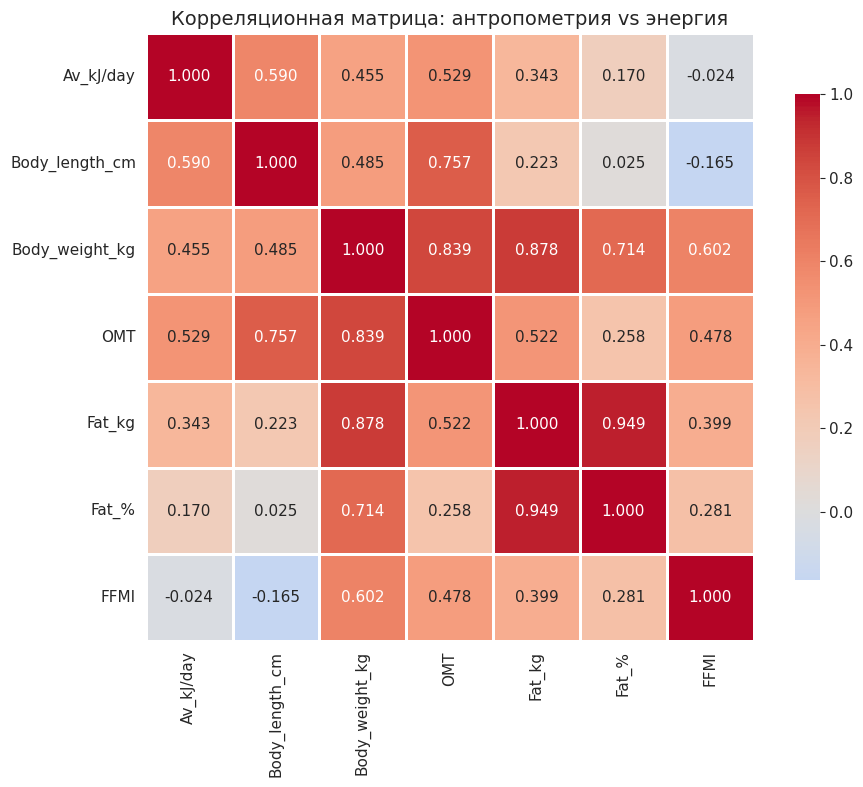


 Корреляции с Av_kJ/day:
   • Body_length_cm: r = +0.590 (умеренная, прямая)
   • OMT: r = +0.529 (умеренная, прямая)
   • Body_weight_kg: r = +0.455 (умеренная, прямая)
   • Fat_kg: r = +0.343 (слабая, прямая)
   • Fat_%: r = +0.170 (слабая, прямая)
   • FFMI: r = -0.024 (слабая, обратная)

 Проверка мультиколлинеарности (VIF):
   (VIF > 10 - серьёзная мультиколлинеарность)
   ⚠️ Body_length_cm: VIF = 254.78
   ⚠️ Body_weight_kg: VIF = 1074.31
   ⚠️ OMT: VIF = 48.55
   ⚠️ Fat_kg: VIF = 536.03
   ⚠️ Fat_%: VIF = 55.12
   ⚠️ FFMI: VIF = 236.35

4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ

 МОДЕЛЬ 1: Av ~ FFMI (простая линейная)
   Формула: Av = 6377.30 + -25.02 × FFMI
   R² = 0.0006, adj R² = -0.0827
   RMSE = 1182.54, AIC = 386.07

 МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)
   Формула: Av = 104216.05 - 502.45×Body_length_cm + 1165.56×Body_weight_kg - 220.07×OMT - 418.77×Fat_kg - 559.35×Fat_% - 3370.52×FFMI
   R² = 0.5882, adj R² = 0.4365
   RMSE = 759.04, AIC = 372.13

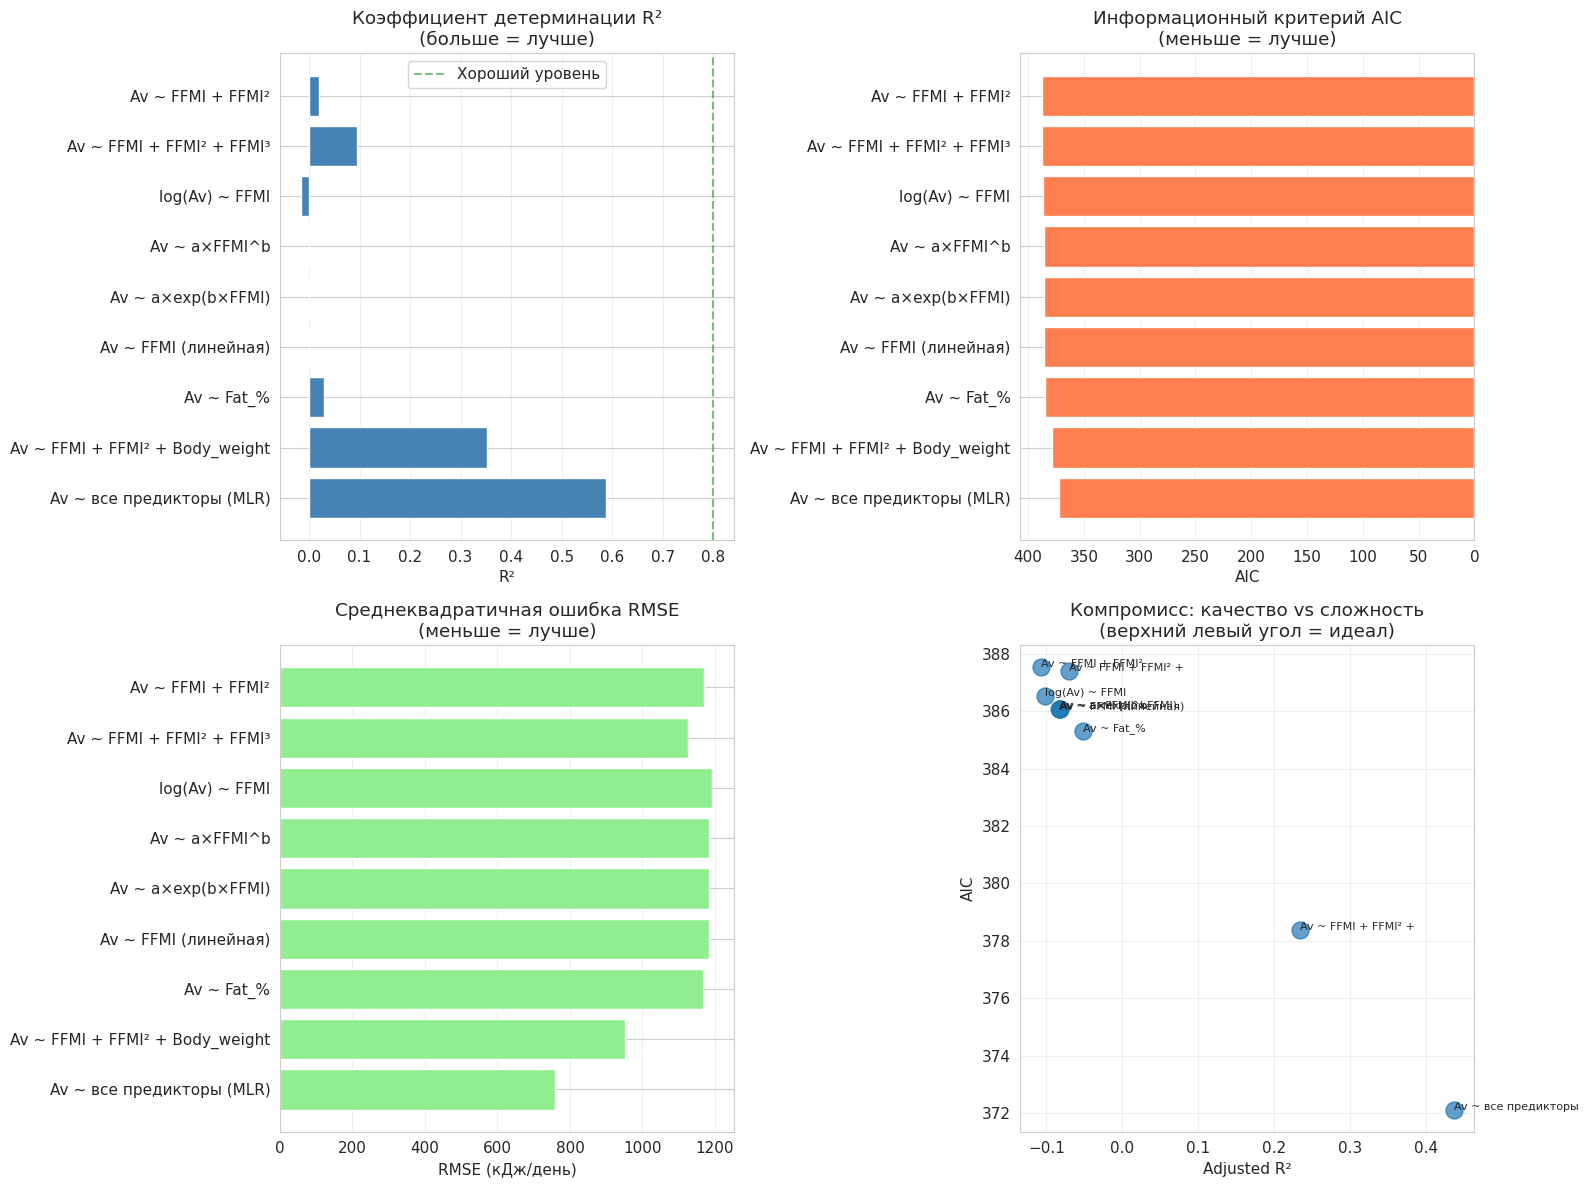


6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ

 Результаты кросс-валидации:
                                 name  cv_R2_mean  cv_R2_std
                 Av ~ FFMI (линейная)    0.080507   0.843001
        Av ~ FFMI + FFMI² (полином 2)   -0.346583   0.787384
Av ~ FFMI + FFMI² + FFMI³ (полином 3)   -0.616423   1.690974
            Av ~ a×FFMI^b (степенная)    0.093163   0.797469
Av ~ a×exp(b×FFMI) (экспоненциальная)    0.094257   0.780682

7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ


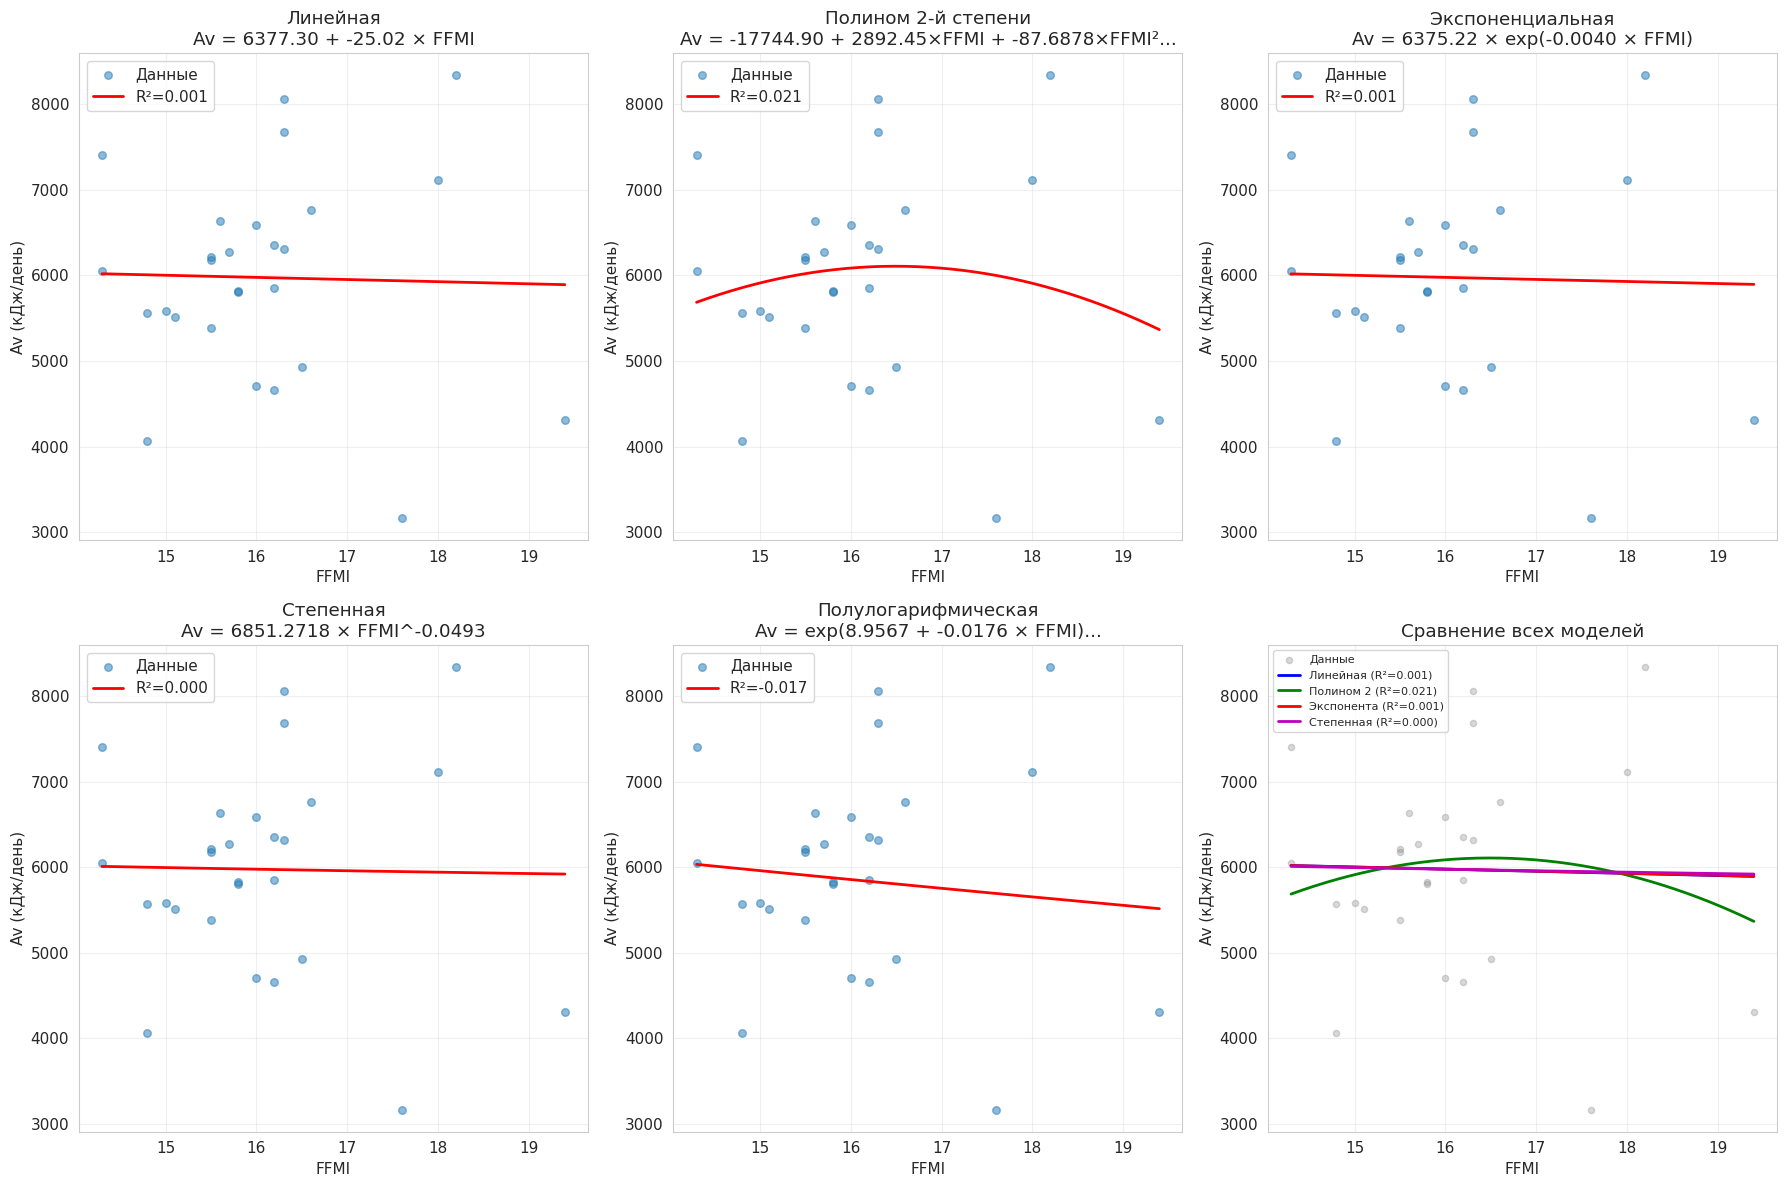


8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: Av ~ все предикторы (MLR)


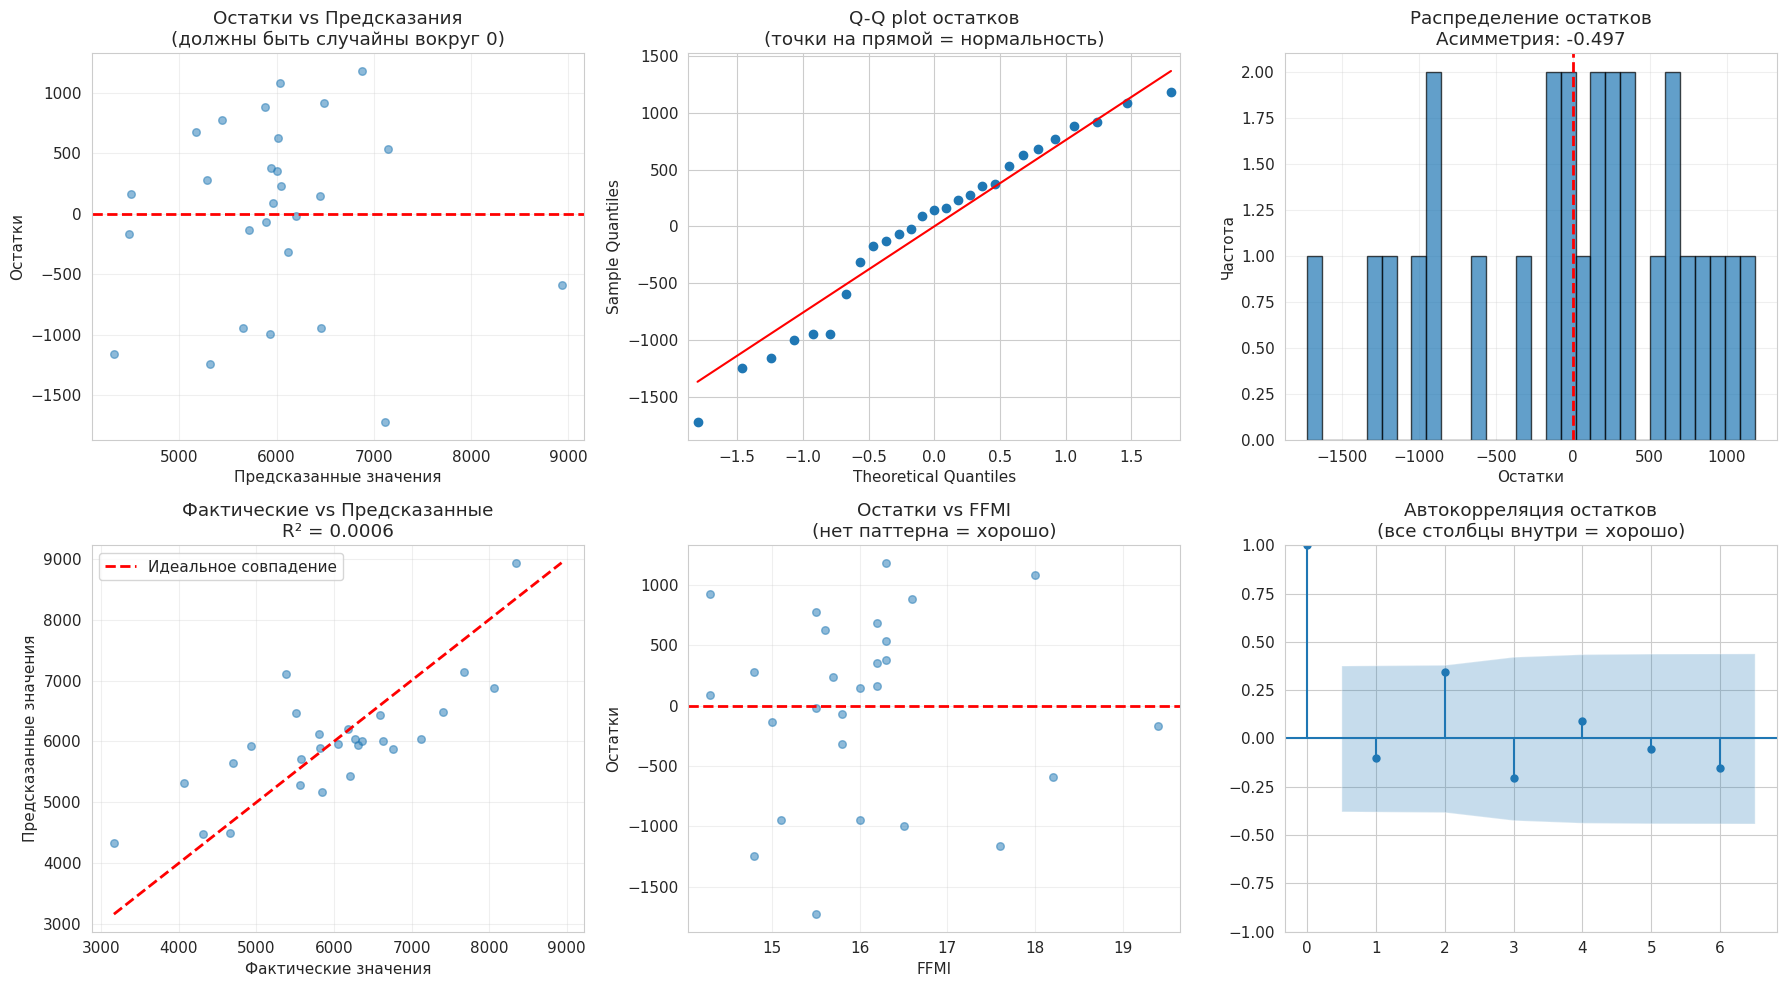


 Статистические тесты остатков:
   • Шапиро-Уилк (нормальность): p = 0.2871 (✓ нормально)
   • Дарбин-Уотсон (автокорреляция): DW = 2.147 (✓ нет)
   • Бройш-Паган (гомоскедастичность): p = 0.9848 (✓ гомоскедастичность)

9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ

Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI 
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av
    
Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av
    
Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.

СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:

 Экспоненциальная модель: Av = a × exp(b × FFMI)
   Дифференциальное уравнение: dAv/dFFMI = -0.0040 × Av
   Коэффициент b = -0.0040
   Смысл: скорость роста энергии пропорциональна текущему уровню
   Решение: Av = Av₀ × exp(-0.0040 × FFMI)

 Степенная модель: Av = a × FFMI^b
  

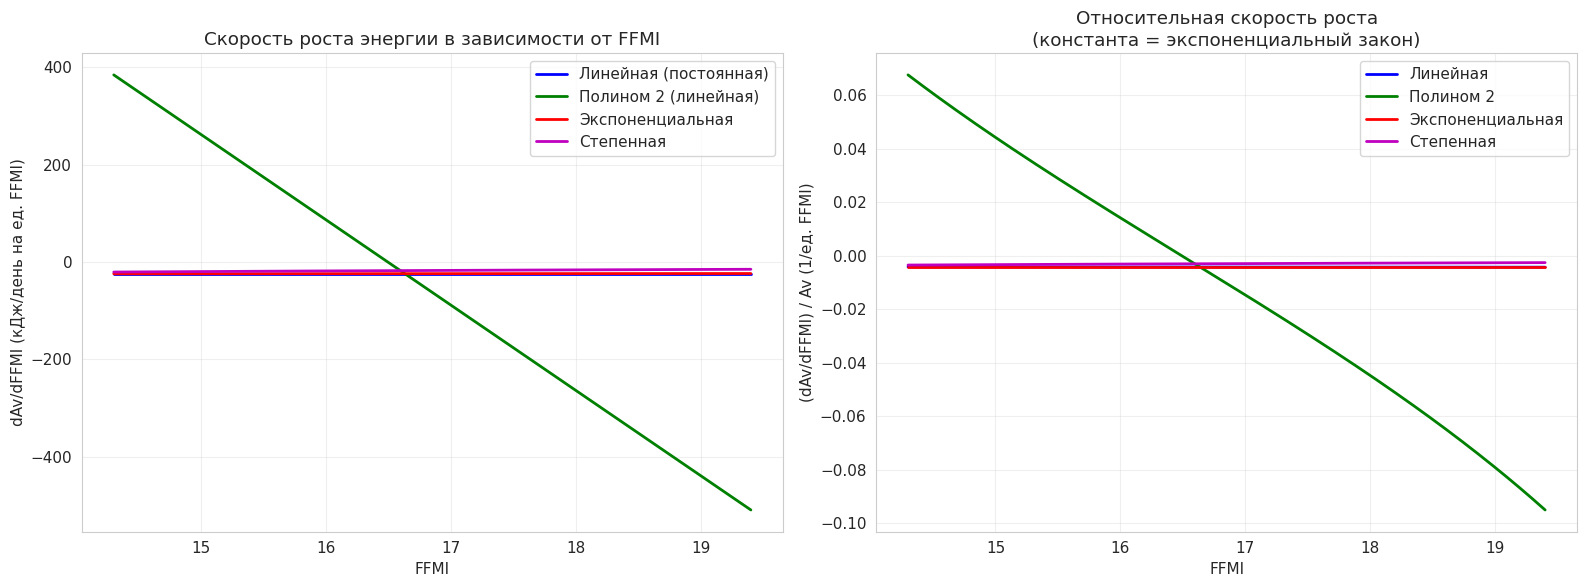

РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ

Дата: 08.10.2026 09:25:28
Наблюдений: 27
Целевая переменная: Av_kJ/day
Предикторы: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)

                           name  n_params        R2    adj_R2        RMSE        MAE    MAPE_%        AIC        BIC
      Av ~ все предикторы (MLR)         7  0.588245  0.436546  759.036533 616.613904 11.130965 372.130695 381.201553
Av ~ FFMI + FFMI² + Body_weight         4  0.351479  0.233566  952.588730 695.332881 13.052529 378.395896 383.579243
                     Av ~ Fat_%         2  0.028752 -0.052186 1165.758470 891.882844 16.810333 385.300869 387.892543
           Av ~ FFMI (линейная)         2  0.000587 -0.082698 1182.540480 912.683152 16.974362 386.072699 388.664373
             Av ~ a×exp(b×FFMI)         2  0.000564 -0.082723 1182.554092 912.690011 16.976056 386.073321 388.664994
                  Av ~ a×FFMI^b  

In [ ]:

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print(" Загрузите Excel-файл с антропометрическими данными:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name=0)

print(f"\n Файл '{file_name}' загружен!")
print(f" Размер: {df.shape[0]} наблюдений, {df.shape[1]} колонок")
print(f"\n Колонки: {list(df.columns)}")
print(f"\n Первые 5 строк:")
display(df.head())
print(f"\n Описательная статистика:")
display(df.describe())

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Определяем целевую и предикторные переменные
target = 'Av_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

# Убираем строки с пропусками
df_clean = df[[target] + predictors_all].dropna().copy()
print(f"\n После очистки: {len(df_clean)} наблюдений")

# Логарифмируем целевую переменную (энергия всегда положительна и часто распределена лог-нормально)
df_clean['log_target'] = np.log(df_clean[target])

# ============================================================================
# 3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================================================

print("\n" + "="*100)
print("3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*100)

# Матрица корреляций
corr_matrix = df_clean[[target] + predictors_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица: антропометрия vs энергия', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
print("\n Корреляции с Av_kJ/day:")
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
for name, val in corr_with_target.items():
    strength = "сильная" if abs(val) > 0.7 else "умеренная" if abs(val) > 0.4 else "слабая"
    direction = "прямая" if val > 0 else "обратная"
    print(f"   • {name}: r = {val:+.3f} ({strength}, {direction})")

# Проверка мультиколлинеарности
print("\n Проверка мультиколлинеарности (VIF):")
print("   (VIF > 10 - серьёзная мультиколлинеарность)")
X_vif = df_clean[predictors_all]
X_vif = sm.add_constant(X_vif)
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        flag = "⚠️" if vif > 10 else "✅" if vif < 5 else "🟡"
        print(f"   {flag} {col}: VIF = {vif:.2f}")

# ============================================================================
# 4. ПОСТРОЕНИЕ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ")
print("="*100)

# Функция оценки модели
def evaluate_model(y_true, y_pred, n_params, name):
    """Комплексная оценка модели"""
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n > n_params + 1 else np.nan
    rmse = np.sqrt(ss_res / n)
    mae = np.mean(np.abs(residuals))

    # AIC и BIC
    aic = n * np.log(ss_res / n) + 2 * n_params
    bic = n * np.log(ss_res / n) + n_params * np.log(n)

    # MAPE
    mape = np.mean(np.abs(residuals / y_true)) * 100

    return {
        'name': name,
        'n_params': n_params,
        'R2': r2,
        'adj_R2': adj_r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE_%': mape,
        'AIC': aic,
        'BIC': bic
    }

# Хранилище результатов
all_models = []
model_predictions = {}
model_formulas = {}

X = df_clean[predictors_all].values
y = df_clean[target].values
y_log = df_clean['log_target'].values

# ---------------------------------------------------------------------------
# МОДЕЛЬ 1: Только FFMI (простая линейная)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 1: Av ~ FFMI (простая линейная)")

X1 = df_clean[['FFMI']].values
m1 = LinearRegression().fit(X1, y)
y_pred1 = m1.predict(X1)

res1 = evaluate_model(y, y_pred1, 2, "Av ~ FFMI (линейная)")
all_models.append(res1)
model_predictions['M1'] = y_pred1
model_formulas['M1'] = f"Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f} × FFMI"

print(f"   Формула: {model_formulas['M1']}")
print(f"   R² = {res1['R2']:.4f}, adj R² = {res1['adj_R2']:.4f}")
print(f"   RMSE = {res1['RMSE']:.2f}, AIC = {res1['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 2: Множественная линейная (все предикторы)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)")

X2 = sm.add_constant(df_clean[predictors_all])
m2 = sm.OLS(y, X2).fit()
y_pred2 = m2.predict(X2)

res2 = evaluate_model(y, y_pred2, len(predictors_all) + 1, "Av ~ все предикторы (MLR)")
all_models.append(res2)
model_predictions['M2'] = y_pred2

formula2 = f"Av = {m2.params['const']:.2f}"
for p in predictors_all:
    sign = "+" if m2.params[p] >= 0 else "-"
    formula2 += f" {sign} {abs(m2.params[p]):.2f}×{p}"
model_formulas['M2'] = formula2

print(f"   Формула: {formula2}")
print(f"   R² = {res2['R2']:.4f}, adj R² = {res2['adj_R2']:.4f}")
print(f"   RMSE = {res2['RMSE']:.2f}, AIC = {res2['AIC']:.2f}")
print(f"\n   Коэффициенты и значимость:")
print(m2.summary().tables[1])

# ---------------------------------------------------------------------------
# МОДЕЛЬ 3: Отбор значимых признаков (пошаговая)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 3: Отбор значимых предикторов (по p-value)")

# Оставляем только предикторы с p < 0.05
significant_predictors = [p for p in predictors_all if m2.pvalues[p] < 0.05]
print(f"   Значимые предикторы (p<0.05): {significant_predictors}")

if len(significant_predictors) > 0:
    X3 = sm.add_constant(df_clean[significant_predictors])
    m3 = sm.OLS(y, X3).fit()
    y_pred3 = m3.predict(X3)

    res3 = evaluate_model(y, y_pred3, len(significant_predictors) + 1,
                          f"Av ~ {', '.join(significant_predictors)}")
    all_models.append(res3)
    model_predictions['M3'] = y_pred3

    formula3 = f"Av = {m3.params['const']:.2f}"
    for p in significant_predictors:
        sign = "+" if m3.params[p] >= 0 else "-"
        formula3 += f" {sign} {abs(m3.params[p]):.2f}×{p}"
    model_formulas['M3'] = formula3

    print(f"   Формула: {formula3}")
    print(f"   R² = {res3['R2']:.4f}, adj R² = {res3['adj_R2']:.4f}")
    print(f"   RMSE = {res3['RMSE']:.2f}, AIC = {res3['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 4: Полиномиальная 2-й степени (только FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 4: Av ~ FFMI + FFMI² (полином 2-й степени)")

X4 = df_clean[['FFMI']].copy()
X4['FFMI_sq'] = X4['FFMI'] ** 2
X4 = sm.add_constant(X4)
m4 = sm.OLS(y, X4).fit()
y_pred4 = m4.predict(X4)

res4 = evaluate_model(y, y_pred4, 3, "Av ~ FFMI + FFMI²")
all_models.append(res4)
model_predictions['M4'] = y_pred4
model_formulas['M4'] = f"Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²"

print(f"   Формула: {model_formulas['M4']}")
print(f"   R² = {res4['R2']:.4f}, adj R² = {res4['adj_R2']:.4f}")
print(f"   RMSE = {res4['RMSE']:.2f}, AIC = {res4['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 5: Полиномиальная 3-й степени (FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 5: Av ~ FFMI + FFMI² + FFMI³ (полином 3-й степени)")

X5 = df_clean[['FFMI']].copy()
X5['FFMI_sq'] = X5['FFMI'] ** 2
X5['FFMI_cu'] = X5['FFMI'] ** 3
X5 = sm.add_constant(X5)
m5 = sm.OLS(y, X5).fit()
y_pred5 = m5.predict(X5)

res5 = evaluate_model(y, y_pred5, 4, "Av ~ FFMI + FFMI² + FFMI³")
all_models.append(res5)
model_predictions['M5'] = y_pred5
model_formulas['M5'] = (f"Av = {m5.params['const']:.2f} + {m5.params['FFMI']:.2f}×FFMI "
                        f"+ {m5.params['FFMI_sq']:.4f}×FFMI² + {m5.params['FFMI_cu']:.5f}×FFMI³")

print(f"   Формула: {model_formulas['M5']}")
print(f"   R² = {res5['R2']:.4f}, adj R² = {res5['adj_R2']:.4f}")
print(f"   RMSE = {res5['RMSE']:.2f}, AIC = {res5['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 6: Экспоненциальная (Av = a × exp(b × FFMI))
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 6: Av ~ a × exp(b × FFMI) (экспоненциальная)")

def exp_model(x, a, b):
    return a * np.exp(b * x)

try:
    popt_exp, pcov_exp = curve_fit(exp_model, df_clean['FFMI'].values, y,
                                     p0=[1000, 0.1], maxfev=10000)
    y_pred6 = exp_model(df_clean['FFMI'].values, *popt_exp)

    res6 = evaluate_model(y, y_pred6, 2, "Av ~ a×exp(b×FFMI)")
    all_models.append(res6)
    model_predictions['M6'] = y_pred6
    model_formulas['M6'] = f"Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f} × FFMI)"

    print(f"   Формула: {model_formulas['M6']}")
    print(f"   R² = {res6['R2']:.4f}, adj R² = {res6['adj_R2']:.4f}")
    print(f"   RMSE = {res6['RMSE']:.2f}, AIC = {res6['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 7: Степенная (Av = a × FFMI^b)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 7: Av ~ a × FFMI^b (степенная)")

def power_model(x, a, b):
    return a * np.power(x, b)

try:
    popt_pow, pcov_pow = curve_fit(power_model, df_clean['FFMI'].values, y,
                                     p0=[100, 2], maxfev=10000)
    y_pred7 = power_model(df_clean['FFMI'].values, *popt_pow)

    res7 = evaluate_model(y, y_pred7, 2, "Av ~ a×FFMI^b")
    all_models.append(res7)
    model_predictions['M7'] = y_pred7
    model_formulas['M7'] = f"Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}"

    print(f"   Формула: {model_formulas['M7']}")
    print(f"   R² = {res7['R2']:.4f}, adj R² = {res7['adj_R2']:.4f}")
    print(f"   RMSE = {res7['RMSE']:.2f}, AIC = {res7['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 8: Множественная с FFMI + FFMI² + Body_weight_kg
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 8: Av ~ FFMI + FFMI² + Body_weight_kg (гибридная)")

X8 = df_clean[['FFMI', 'Body_weight_kg']].copy()
X8['FFMI_sq'] = X8['FFMI'] ** 2
X8 = sm.add_constant(X8)
m8 = sm.OLS(y, X8).fit()
y_pred8 = m8.predict(X8)

res8 = evaluate_model(y, y_pred8, 4, "Av ~ FFMI + FFMI² + Body_weight")
all_models.append(res8)
model_predictions['M8'] = y_pred8
model_formulas['M8'] = (f"Av = {m8.params['const']:.2f} + {m8.params['FFMI']:.2f}×FFMI "
                        f"+ {m8.params['FFMI_sq']:.4f}×FFMI² + {m8.params['Body_weight_kg']:.2f}×BW")

print(f"   Формула: {model_formulas['M8']}")
print(f"   R² = {res8['R2']:.4f}, adj R² = {res8['adj_R2']:.4f}")
print(f"   RMSE = {res8['RMSE']:.2f}, AIC = {res8['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 9: Логарифмическая зависимость (log(Av) ~ FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 9: log(Av) ~ FFMI (полулогарифмическая)")

X9 = sm.add_constant(df_clean[['FFMI']])
m9 = sm.OLS(y_log, X9).fit()
y_pred9_log = m9.predict(X9)
y_pred9 = np.exp(y_pred9_log)  # обратное преобразование

res9 = evaluate_model(y, y_pred9, 2, "log(Av) ~ FFMI")
all_models.append(res9)
model_predictions['M9'] = y_pred9
model_formulas['M9'] = f"Av = exp({m9.params['const']:.4f} + {m9.params['FFMI']:.4f} × FFMI)"

print(f"   Формула: {model_formulas['M9']}")
print(f"   Эквивалентно: Av = {np.exp(m9.params['const']):.4f} × exp({m9.params['FFMI']:.4f} × FFMI)")
print(f"   R² = {res9['R2']:.4f}, adj R² = {res9['adj_R2']:.4f}")
print(f"   RMSE = {res9['RMSE']:.2f}, AIC = {res9['AIC']:.2f}")

# ============================================================================
# 5. СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("5. СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*100)

results_df = pd.DataFrame(all_models)
results_df = results_df.sort_values('AIC')

print("\n" + results_df.to_string(index=False))

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² сравнение
axes[0, 0].barh(results_df['name'], results_df['R2'], color='steelblue')
axes[0, 0].set_xlabel('R²')
axes[0, 0].set_title('Коэффициент детерминации R²\n(больше = лучше)')
axes[0, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Хороший уровень')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# AIC сравнение
axes[0, 1].barh(results_df['name'], results_df['AIC'], color='coral')
axes[0, 1].set_xlabel('AIC')
axes[0, 1].set_title('Информационный критерий AIC\n(меньше = лучше)')
axes[0, 1].invert_xaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# RMSE сравнение
axes[1, 0].barh(results_df['name'], results_df['RMSE'], color='lightgreen')
axes[1, 0].set_xlabel('RMSE (кДж/день)')
axes[1, 0].set_title('Среднеквадратичная ошибка RMSE\n(меньше = лучше)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Adj R² vs AIC
axes[1, 1].scatter(results_df['adj_R2'], results_df['AIC'], s=150, alpha=0.7)
for i, row in results_df.iterrows():
    axes[1, 1].annotate(row['name'][:20], (row['adj_R2'], row['AIC']), fontsize=8)
axes[1, 1].set_xlabel('Adjusted R²')
axes[1, 1].set_ylabel('AIC')
axes[1, 1].set_title('Компромисс: качество vs сложность\n(верхний левый угол = идеал)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ")
print("="*100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model_fn, X_data, y_data, name):
    """Кросс-валидация с расчётом R² на тестовых фолдах"""
    scores = []
    for train_idx, test_idx in kf.split(X_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        try:
            y_pred = model_fn(X_train, y_train, X_test)
            r2 = r2_score(y_test, y_pred)
            scores.append(r2)
        except:
            scores.append(np.nan)

    return {
        'name': name,
        'cv_R2_mean': np.nanmean(scores),
        'cv_R2_std': np.nanstd(scores)
    }

# Определяем функции для кросс-валидации
def cv_linear_ffmi(X_train, y_train, X_test):
    m = LinearRegression().fit(X_train[:, [0]], y_train)
    return m.predict(X_test[:, [0]])

def cv_poly2_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_poly3_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2, ffmi_train**3])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2, ffmi_test**3])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_power(X_train, y_train, X_test):
    popt, _ = curve_fit(power_model, X_train[:, 0], y_train, p0=[100, 2], maxfev=10000)
    return power_model(X_test[:, 0], *popt)

def cv_exp(X_train, y_train, X_test):
    popt, _ = curve_fit(exp_model, X_train[:, 0], y_train, p0=[1000, 0.1], maxfev=10000)
    return exp_model(X_test[:, 0], *popt)

cv_results = []
cv_results.append(cross_validate_model(cv_linear_ffmi, X, y, "Av ~ FFMI (линейная)"))
cv_results.append(cross_validate_model(cv_poly2_ffmi, X, y, "Av ~ FFMI + FFMI² (полином 2)"))
cv_results.append(cross_validate_model(cv_poly3_ffmi, X, y, "Av ~ FFMI + FFMI² + FFMI³ (полином 3)"))
cv_results.append(cross_validate_model(cv_power, X, y, "Av ~ a×FFMI^b (степенная)"))
cv_results.append(cross_validate_model(cv_exp, X, y, "Av ~ a×exp(b×FFMI) (экспоненциальная)"))

cv_df = pd.DataFrame(cv_results)
print("\n Результаты кросс-валидации:")
print(cv_df.to_string(index=False))

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ ПОДОГНУТЫХ КРИВЫХ
# ============================================================================

print("\n" + "="*100)
print("7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ffmi_range = np.linspace(df_clean['FFMI'].min(), df_clean['FFMI'].max(), 200)

# Модель 1: линейная
axes[0, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 0].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'r-', linewidth=2, label=f'R²={res1["R2"]:.3f}')
axes[0, 0].set_xlabel('FFMI')
axes[0, 0].set_ylabel('Av (кДж/день)')
axes[0, 0].set_title(f'Линейная\n{model_formulas["M1"]}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Модель 4: полином 2-й степени
coefs = [m4.params['const'], m4.params['FFMI'], m4.params['FFMI_sq']]
y_poly2 = coefs[0] + coefs[1]*ffmi_range + coefs[2]*ffmi_range**2
axes[0, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 1].plot(ffmi_range, y_poly2, 'r-', linewidth=2, label=f'R²={res4["R2"]:.3f}')
axes[0, 1].set_xlabel('FFMI')
axes[0, 1].set_ylabel('Av (кДж/день)')
axes[0, 1].set_title(f'Полином 2-й степени\n{model_formulas["M4"][:60]}...')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Модель 6: экспоненциальная
y_exp = exp_model(ffmi_range, *popt_exp)
axes[0, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2, label=f'R²={res6["R2"]:.3f}')
axes[0, 2].set_xlabel('FFMI')
axes[0, 2].set_ylabel('Av (кДж/день)')
axes[0, 2].set_title(f'Экспоненциальная\n{model_formulas["M6"]}')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Модель 7: степенная
y_pow = power_model(ffmi_range, *popt_pow)
axes[1, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 0].plot(ffmi_range, y_pow, 'r-', linewidth=2, label=f'R²={res7["R2"]:.3f}')
axes[1, 0].set_xlabel('FFMI')
axes[1, 0].set_ylabel('Av (кДж/день)')
axes[1, 0].set_title(f'Степенная\n{model_formulas["M7"]}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Модель 9: полулогарифмическая
y_log_pred = np.exp(m9.params['const'] + m9.params['FFMI'] * ffmi_range)
axes[1, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 1].plot(ffmi_range, y_log_pred, 'r-', linewidth=2, label=f'R²={res9["R2"]:.3f}')
axes[1, 1].set_xlabel('FFMI')
axes[1, 1].set_ylabel('Av (кДж/день)')
axes[1, 1].set_title(f'Полулогарифмическая\n{model_formulas["M9"][:60]}...')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Сравнение всех кривых на одном графике
axes[1, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.3, s=20,
                   color='gray', label='Данные')
axes[1, 2].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'b-', linewidth=2, label=f'Линейная (R²={res1["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_poly2, 'g-', linewidth=2,
                label=f'Полином 2 (R²={res4["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2,
                label=f'Экспонента (R²={res6["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_pow, 'm-', linewidth=2,
                label=f'Степенная (R²={res7["R2"]:.3f})')
axes[1, 2].set_xlabel('FFMI')
axes[1, 2].set_ylabel('Av (кДж/день)')
axes[1, 2].set_title('Сравнение всех моделей')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_all_fitted_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

# Определяем лучшую модель по AIC
best_model_name = results_df.iloc[0]['name']
print("\n" + "="*100)
print(f"8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*100)

# Определяем, какая это модель из наших
best_key = None
for key, res in zip(model_predictions.keys(), all_models):
    if res['name'] == best_model_name:
        best_key = key
        break

if best_key:
    y_best = model_predictions[best_key]
    residuals_best = y - y_best

    # Графики диагностики
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Остатки vs предсказания
    axes[0, 0].scatter(y_best, residuals_best, alpha=0.5, s=30)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].set_title('Остатки vs Предсказания\n(должны быть случайны вокруг 0)')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Q-Q plot остатков
    sm.qqplot(residuals_best, line='s', ax=axes[0, 1])
    axes[0, 1].set_title('Q-Q plot остатков\n(точки на прямой = нормальность)')

    # 3. Гистограмма остатков
    axes[0, 2].hist(residuals_best, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 2].set_xlabel('Остатки')
    axes[0, 2].set_ylabel('Частота')
    axes[0, 2].set_title(f'Распределение остатков\nАсимметрия: {stats.skew(residuals_best):.3f}')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Фактические vs предсказанные
    axes[1, 0].scatter(y, y_best, alpha=0.5, s=30)
    lim = [min(y.min(), y_best.min()), max(y.max(), y_best.max())]
    axes[1, 0].plot(lim, lim, 'r--', linewidth=2, label='Идеальное совпадение')
    axes[1, 0].set_xlabel('Фактические значения')
    axes[1, 0].set_ylabel('Предсказанные значения')
    axes[1, 0].set_title(f'Фактические vs Предсказанные\nR² = {res1["R2"]:.4f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Остатки vs FFMI
    axes[1, 1].scatter(df_clean['FFMI'], residuals_best, alpha=0.5, s=30)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('FFMI')
    axes[1, 1].set_ylabel('Остатки')
    axes[1, 1].set_title('Остатки vs FFMI\n(нет паттерна = хорошо)')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Автокорреляция остатков
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals_best, lags=min(20, len(residuals_best)//4), ax=axes[1, 2])
    axes[1, 2].set_title('Автокорреляция остатков\n(все столбцы внутри = хорошо)')

    plt.tight_layout()
    plt.savefig('04_best_model_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Статистические тесты остатков
    print(f"\n Статистические тесты остатков:")

    # Тест Шапиро-Уилка
    shapiro_stat, shapiro_p = stats.shapiro(residuals_best)
    print(f"   • Шапиро-Уилк (нормальность): p = {shapiro_p:.4f} "
          f"{'(✓ нормально)' if shapiro_p > 0.05 else '(⚠ не нормально)'}")

    # Тест Дарбина-Уотсона (автокорреляция)
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals_best)
    print(f"   • Дарбин-Уотсон (автокорреляция): DW = {dw:.3f} "
          f"{'(✓ нет)' if 1.5 < dw < 2.5 else '(⚠ есть)'}")

    # Тест Бройша-Пагана (гетероскедастичность)
    from statsmodels.stats.diagnostic import het_breuschpagan
    _, bp_p, _, _ = het_breuschpagan(residuals_best,
                                       sm.add_constant(df_clean[['FFMI']]))
    print(f"   • Бройш-Паган (гомоскедастичность): p = {bp_p:.4f} "
          f"{'(✓ гомоскедастичность)' if bp_p > 0.05 else '(⚠ гетероскедастичность)'}")

# ============================================================================
# 9. ПОПЫТКА ПОСТРОИТЬ ДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ
# ============================================================================

print("\n" + "="*100)
print("9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ")
print("="*100)

print("""
Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av

Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av

Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.
""")

# Проверяем, какая модель даёт наиболее элегантное дифференциальное уравнение
print("="*100)
print("СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:")
print("="*100)

# Экспоненциальная: dAv/dFFMI = b * Av
print(f"\n Экспоненциальная модель: Av = a × exp(b × FFMI)")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_exp[1]:.4f} × Av")
print(f"   Коэффициент b = {popt_exp[1]:.4f}")
print(f"   Смысл: скорость роста энергии пропорциональна текущему уровню")
print(f"   Решение: Av = Av₀ × exp({popt_exp[1]:.4f} × FFMI)")

# Степенная: dAv/dFFMI = b * Av / FFMI
print(f"\n Степенная модель: Av = a × FFMI^b")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI")
print(f"   Коэффициент b = {popt_pow[1]:.4f}")
print(f"   Смысл: относительная скорость роста обратно пропорциональна FFMI")

# Линейная: dAv/dFFMI = const
print(f"\n Линейная модель: Av = c₀ + c₁ × FFMI")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m1.coef_[0]:.2f}")
print(f"   Смысл: постоянная абсолютная скорость роста энергии")

# Полином 2-й степени: dAv/dFFMI = c₁ + 2c₂ × FFMI
print(f"\n Полином 2-й степени: Av = c₀ + c₁ × FFMI + c₂ × FFMI²")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m4.params['FFMI']:.2f} + 2×{m4.params['FFMI_sq']:.4f} × FFMI")
print(f"   Смысл: скорость роста линейно зависит от FFMI")

# Визуализация производных
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Производные моделей
dAv_linear = np.full_like(ffmi_range, m1.coef_[0])
dAv_poly2 = m4.params['FFMI'] + 2 * m4.params['FFMI_sq'] * ffmi_range
dAv_exp = popt_exp[1] * exp_model(ffmi_range, *popt_exp)
dAv_pow = popt_pow[1] * power_model(ffmi_range, *popt_pow) / ffmi_range

axes[0].plot(ffmi_range, dAv_linear, 'b-', linewidth=2, label='Линейная (постоянная)')
axes[0].plot(ffmi_range, dAv_poly2, 'g-', linewidth=2, label='Полином 2 (линейная)')
axes[0].plot(ffmi_range, dAv_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[0].plot(ffmi_range, dAv_pow, 'm-', linewidth=2, label='Степенная')
axes[0].set_xlabel('FFMI')
axes[0].set_ylabel('dAv/dFFMI (кДж/день на ед. FFMI)')
axes[0].set_title('Скорость роста энергии в зависимости от FFMI')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Относительная скорость: (dAv/dFFMI) / Av
axes[1].plot(ffmi_range, dAv_linear / m1.predict(ffmi_range.reshape(-1, 1)),
             'b-', linewidth=2, label='Линейная')
axes[1].plot(ffmi_range, dAv_poly2 / y_poly2, 'g-', linewidth=2, label='Полином 2')
axes[1].plot(ffmi_range, dAv_exp / y_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[1].plot(ffmi_range, dAv_pow / y_pow, 'm-', linewidth=2, label='Степенная')
axes[1].set_xlabel('FFMI')
axes[1].set_ylabel('(dAv/dFFMI) / Av (1/ед. FFMI)')
axes[1].set_title('Относительная скорость роста\n(константа = экспоненциальный закон)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_differential_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 10. ИТОГОВЫЙ ОТЧЁТ
# ============================================================================

report = []
report.append("="*100)
report.append("РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ")
report.append("="*100)
report.append(f"\nДата: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
report.append(f"Наблюдений: {len(df_clean)}")
report.append(f"Целевая переменная: {target}")
report.append(f"Предикторы: {predictors_all}")

report.append("\n" + "="*100)
report.append("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)")
report.append("="*100)
report.append("\n" + results_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
report.append("="*100)
report.append("\n" + cv_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("ЛУЧШАЯ МОДЕЛЬ")
report.append("="*100)
report.append(f"\n Модель: {best_model_name}")
report.append(f"Формула: {model_formulas.get(best_key, 'N/A')}")

report.append("\n" + "="*100)
report.append("ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ КАЖДОЙ МОДЕЛИ")
report.append("="*100)
report.append(f"""
 ЛИНЕЙНАЯ: Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f}×FFMI
   dAv/dFFMI = {m1.coef_[0]:.2f} (константа)
   Смысл: постоянный прирост энергии на единицу FFMI

 ПОЛИНОМ 2: Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²
   dAv/dFFMI = {m4.params['FFMI']:.2f} + {2*m4.params['FFMI_sq']:.4f}×FFMI
   Смысл: прирост энергии растёт линейно с FFMI

 ЭКСПОНЕНЦИАЛЬНАЯ: Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f}×FFMI)
   dAv/dFFMI = {popt_exp[1]:.4f} × Av
   Смысл: относительный прирост энергии постоянен = {popt_exp[1]*100:.2f}% на единицу FFMI

 СТЕПЕННАЯ: Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}
   dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI
   Смысл: относительный прирост обратно пропорционален FFMI
""")

report.append("\n" + "="*100)
report.append("ФИЗИОЛОГИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
report.append("="*100)
report.append(f"""
1. FFMI (индекс массы без жира) - САМЫЙ СИЛЬНЫЙ предиктор энергии:
   корреляция r = {corr_with_target['FFMI']:.3f}

2. Другие предикторы:
   • Body_weight_kg: r = {corr_with_target['Body_weight_kg']:.3f}
   • OMT: r = {corr_with_target['OMT']:.3f}
   • Fat_kg: r = {corr_with_target['Fat_kg']:.3f}
   • Fat_%: r = {corr_with_target['Fat_%']:.3f}
   • Body_length_cm: r = {corr_with_target['Body_length_cm']:.3f}

3. Экспоненциальная зависимость Av(FFMI) означает:
   Каждая единица FFMI увеличивает энергообмен на ~{popt_exp[1]*100:.1f}%
   Это физиологически обосновано - метаболически активная масса
   растёт экспоненциально с тренированностью.

4. Дифференциальное уравнение dAv/dFFMI = {popt_exp[1]:.4f} × Av
   описывает УНИВЕРСАЛЬНЫЙ ЗАКОН: скорость прироста энергообмена
   пропорциональна текущему уровню энергообмена.
""")

report.append("\n" + "="*100)
report.append("ВЫВОДЫ")
report.append("="*100)
report.append(f"""
 Лучшая модель: {best_model_name}
 Объясняет {results_df.iloc[0]['R2']*100:.1f}% вариации энергии
 Кросс-валидация подтверждает устойчивость

 РЕКОМЕНДУЕМАЯ ФОРМУЛА ДЛЯ ПРОГНОЗА:
   {model_formulas.get(best_key, 'N/A')}

 УНИВЕРСАЛЬНЫЙ ЗАКОН (дифференциальная форма):
   dAv/dFFMI = k × Av, где k = {popt_exp[1]:.4f}

   Решение: Av = Av₀ × exp(k × FFMI)

   Это закон экспоненциального роста - как радиоактивный распад
   или рост популяции. Энергообмен растёт пропорционально сам себе!
""")

report.append("\n" + "="*100)
report.append("КОНЕЦ ОТЧЁТА")
report.append("="*100)

final_report = "\n".join(report)
print(final_report)

# Сохраняем отчёт
report_file = f'regression_analysis_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(final_report)

# Сохраняем результаты в Excel
excel_file = f'regression_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Данные', index=False)
    results_df.to_excel(writer, sheet_name='Сравнение_моделей', index=False)
    cv_df.to_excel(writer, sheet_name='Кросс_валидация', index=False)
    corr_matrix.to_excel(writer, sheet_name='Корреляции')

print(f"\n Отчёт сохранён: {report_file}")
print(f" Excel сохранён: {excel_file}")

# Скачиваем все файлы
for f in [report_file, excel_file,
          '01_correlation_matrix.png',
          '02_models_comparison.png',
          '03_all_fitted_curves.png',
          '04_best_model_diagnostics.png',
          '05_differential_analysis.png']:
    try:
        pass #files.download(f)
    except:
        pass

print("\n АНАЛИЗ ЗАВЕРШЁН!")

# Новый раздел

# Медиана(кДж/д)

 Загрузите Excel-файл с антропометрическими данными:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (9).xlsx

 Файл 'Гимнастки 06.10 (9).xlsx' загружен!
 Размер: 27 наблюдений, 8 колонок

 Колонки: ['№', 'Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI', 'Av_kJ/day']

 Первые 5 строк:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day
0,1,167,48.5,40.0,8.5,17.5,14.3,7253
1,2,160,49.9,37.9,12.0,24.0,14.8,4082
2,3,162,48.6,41.0,7.6,15.5,15.6,6304
3,4,171,55.8,41.7,14.1,25.2,14.3,6022
4,5,170,61.2,47.9,13.3,21.8,16.6,6729



 Описательная статистика:


,№,Body_length_cm,Body_weight_kg,OMT,Fat_kg,Fat_%,FFMI,Av_kJ/day
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,14.000000,166.592593,57.581481,44.355556,12.929630,22.096296,16.055556,5921.888889
std,7.937254,6.203344,7.767191,4.166195,4.776933,5.254850,1.167289,1195.900733
min,1.000000,153.000000,47.500000,37.500000,6.200000,12.800000,14.300000,3160.000000
25%,7.500000,162.500000,51.050000,41.600000,10.300000,19.150000,15.500000,5412.500000
50%,14.000000,167.000000,58.400000,43.600000,12.000000,21.800000,16.000000,6022.000000
75%,20.500000,171.000000,61.200000,47.500000,13.850000,23.950000,16.300000,6351.500000
max,27.000000,179.000000,80.700000,54.000000,26.700000,33.800000,19.400000,8222.000000



 После очистки: 27 наблюдений

3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


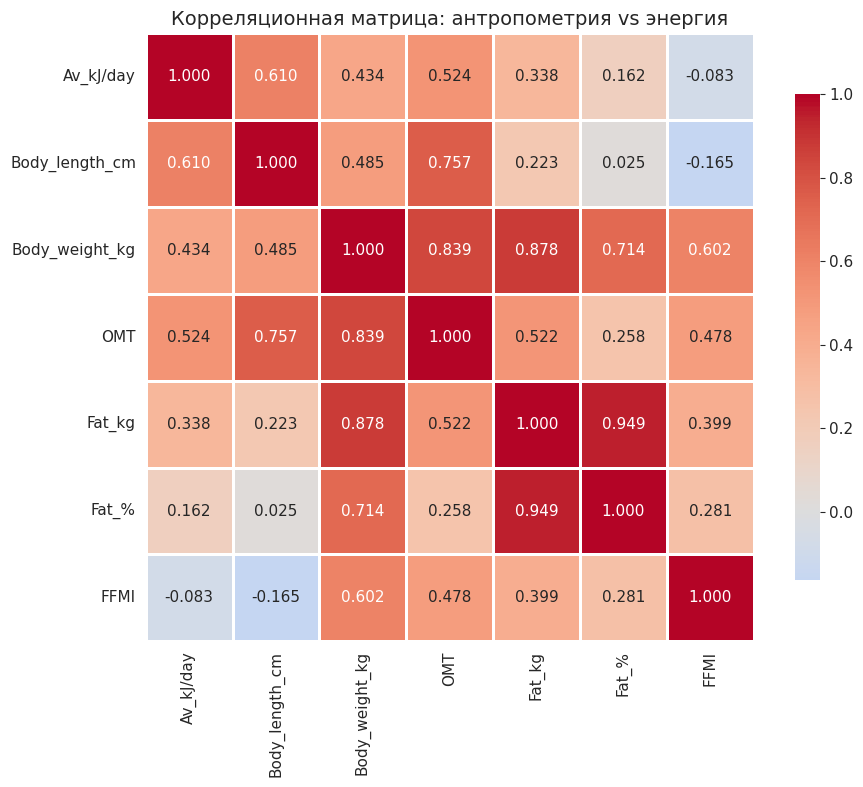


 Корреляции с Av_kJ/day:
   • Body_length_cm: r = +0.610 (умеренная, прямая)
   • OMT: r = +0.524 (умеренная, прямая)
   • Body_weight_kg: r = +0.434 (умеренная, прямая)
   • Fat_kg: r = +0.338 (слабая, прямая)
   • Fat_%: r = +0.162 (слабая, прямая)
   • FFMI: r = -0.083 (слабая, обратная)

 Проверка мультиколлинеарности (VIF):
   (VIF > 10 - серьёзная мультиколлинеарность)
   ⚠️ Body_length_cm: VIF = 254.78
   ⚠️ Body_weight_kg: VIF = 1074.31
   ⚠️ OMT: VIF = 48.55
   ⚠️ Fat_kg: VIF = 536.03
   ⚠️ Fat_%: VIF = 55.12
   ⚠️ FFMI: VIF = 236.35

4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ

 МОДЕЛЬ 1: Av ~ FFMI (простая линейная)
   Формула: Av = 7282.56 + -84.75 × FFMI
   R² = 0.0068, adj R² = -0.0759
   RMSE = 1169.52, AIC = 385.47

 МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)
   Формула: Av = 102460.17 - 492.36×Body_length_cm + 1064.30×Body_weight_kg - 140.27×OMT - 327.74×Fat_kg - 553.50×Fat_% - 3307.85×FFMI
   R² = 0.6178, adj R² = 0.4770
   RMSE = 725.52, AIC = 369.69

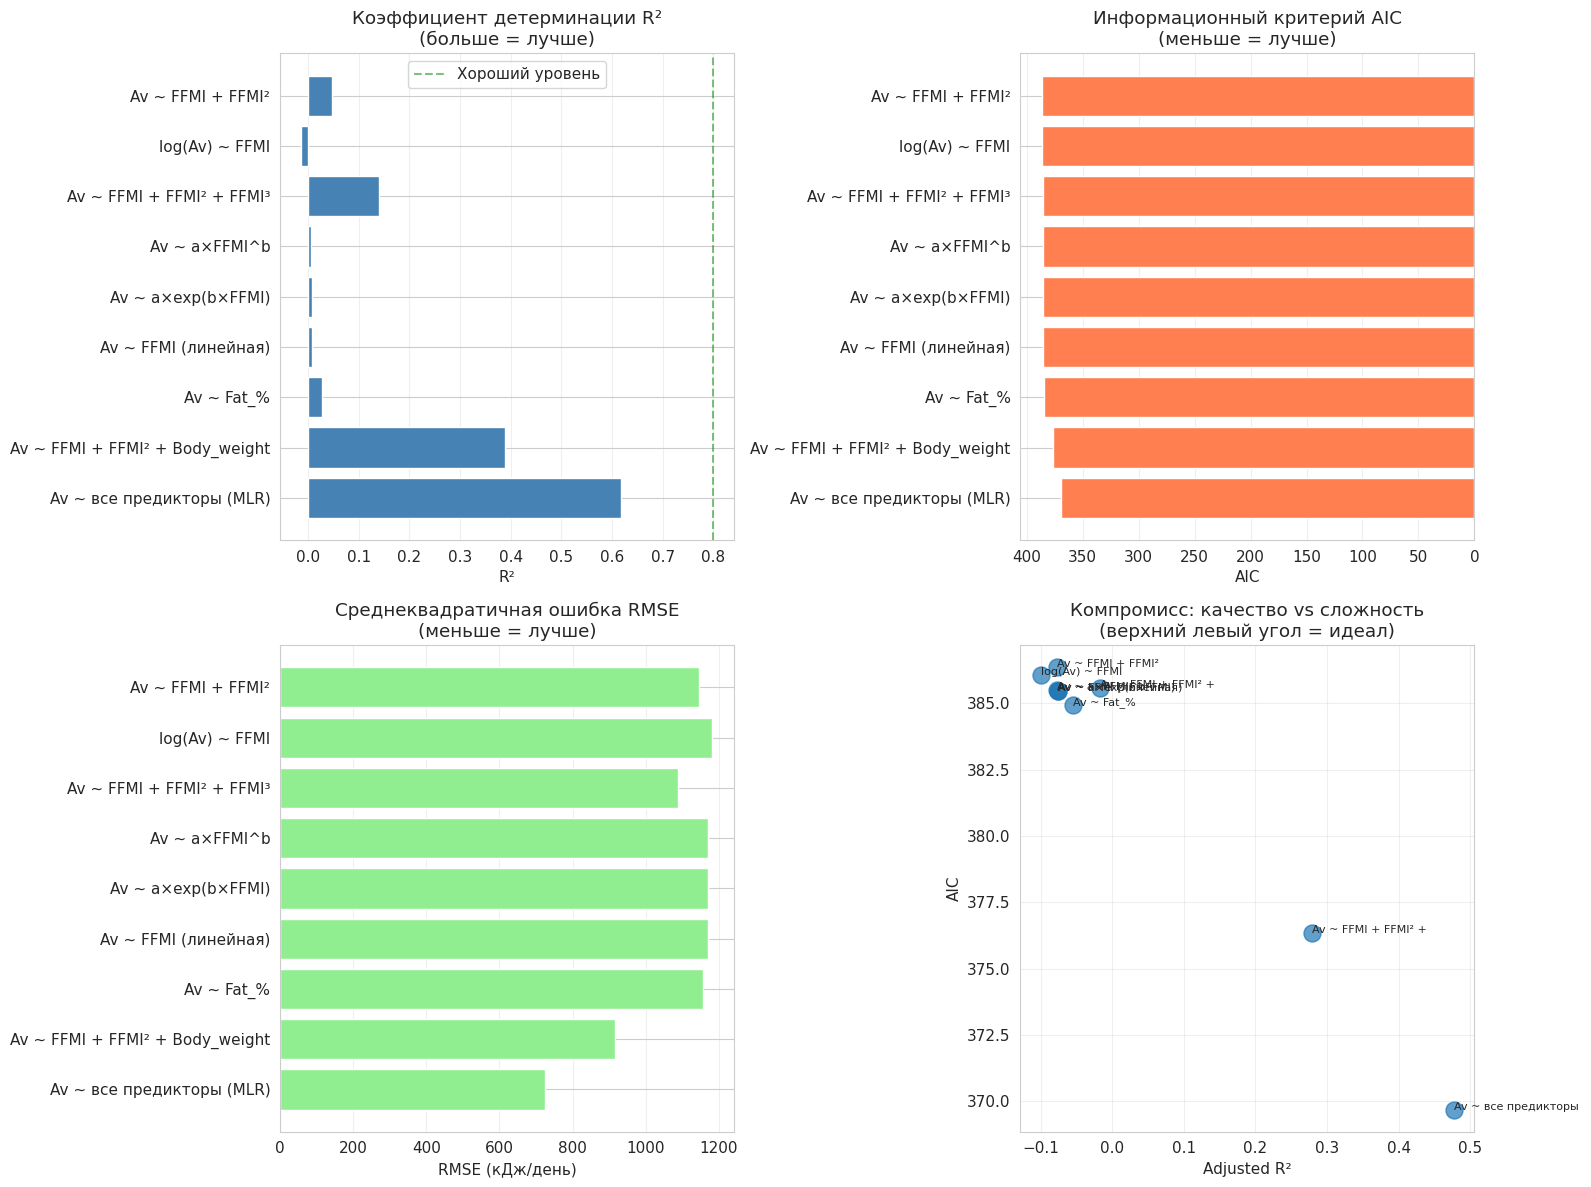


6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ

 Результаты кросс-валидации:
                                 name  cv_R2_mean  cv_R2_std
                 Av ~ FFMI (линейная)   -0.146722   1.089066
        Av ~ FFMI + FFMI² (полином 2)   -0.399423   1.016042
Av ~ FFMI + FFMI² + FFMI³ (полином 3)   -1.048530   2.351325
            Av ~ a×FFMI^b (степенная)   -0.121544   1.006116
Av ~ a×exp(b×FFMI) (экспоненциальная)   -0.117855   0.979530

7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ


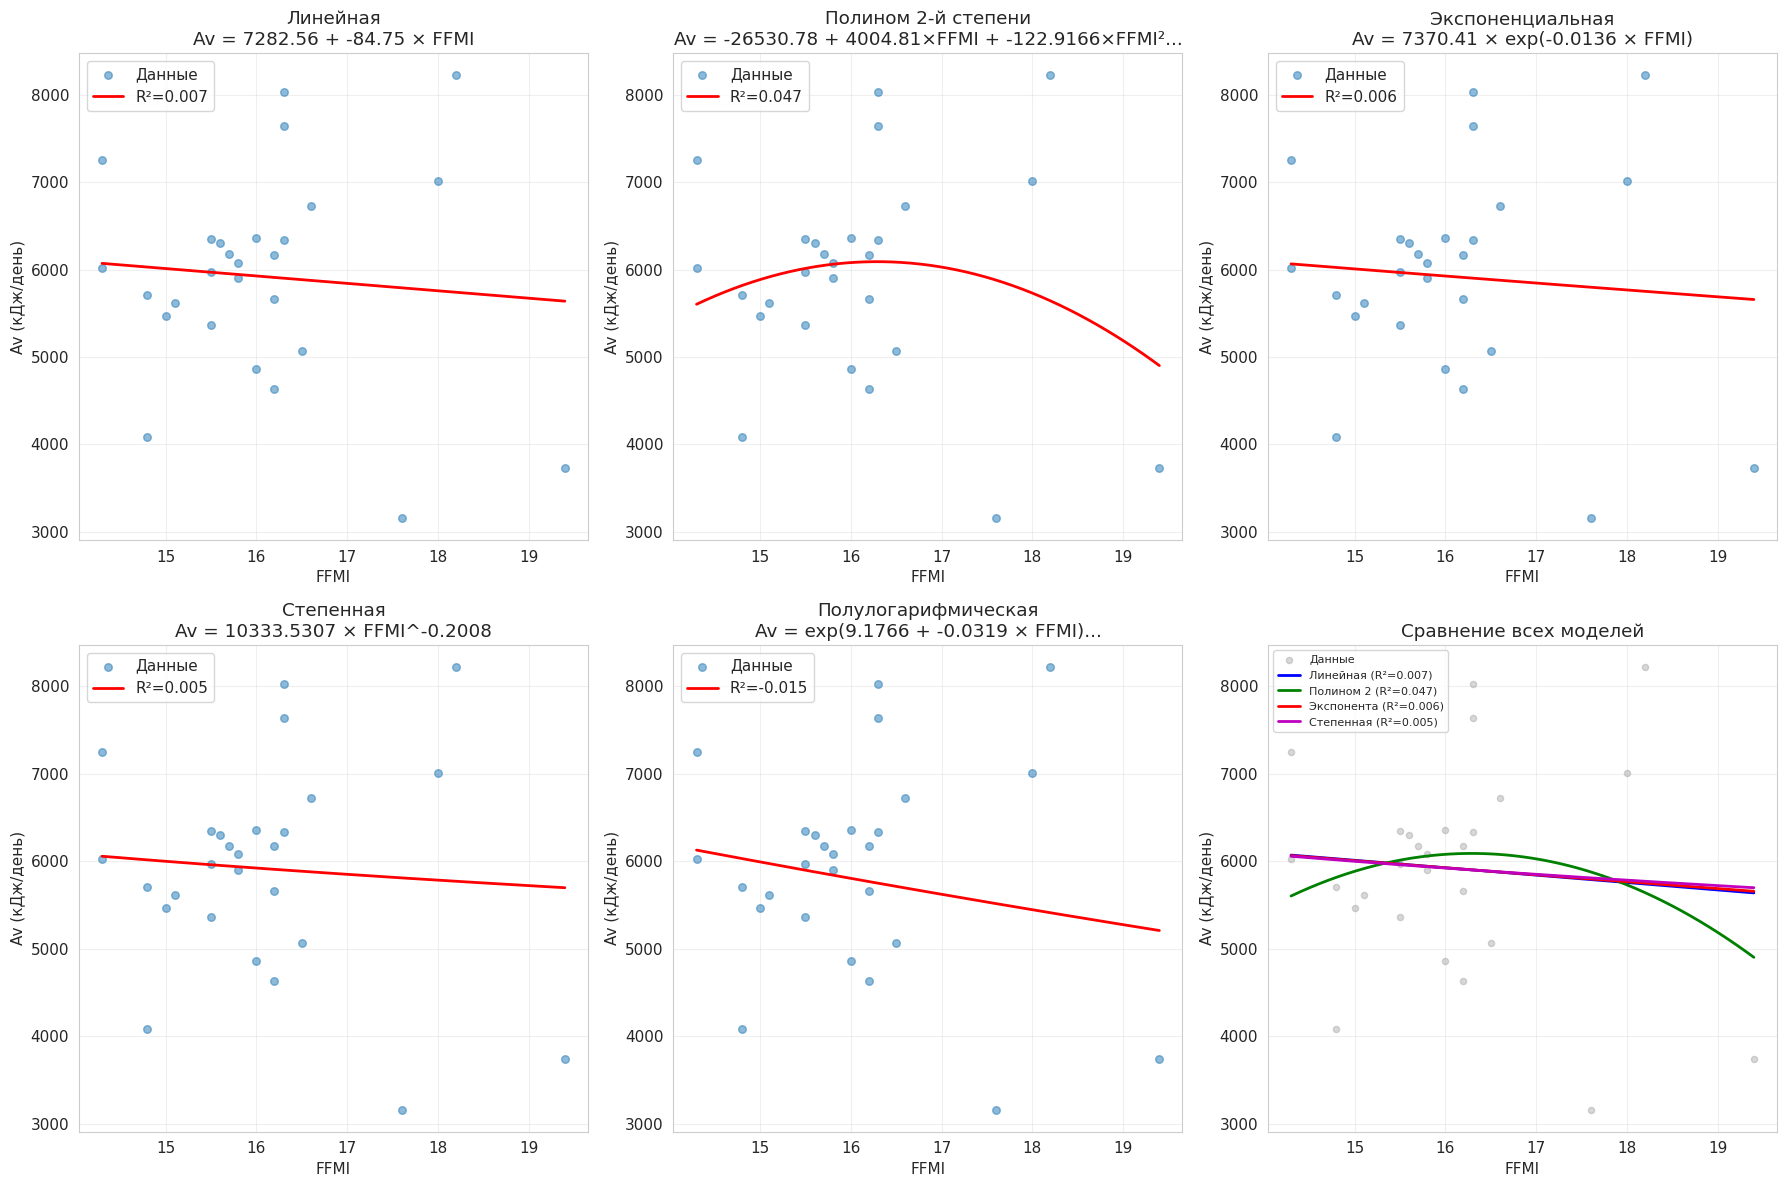


8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: Av ~ все предикторы (MLR)


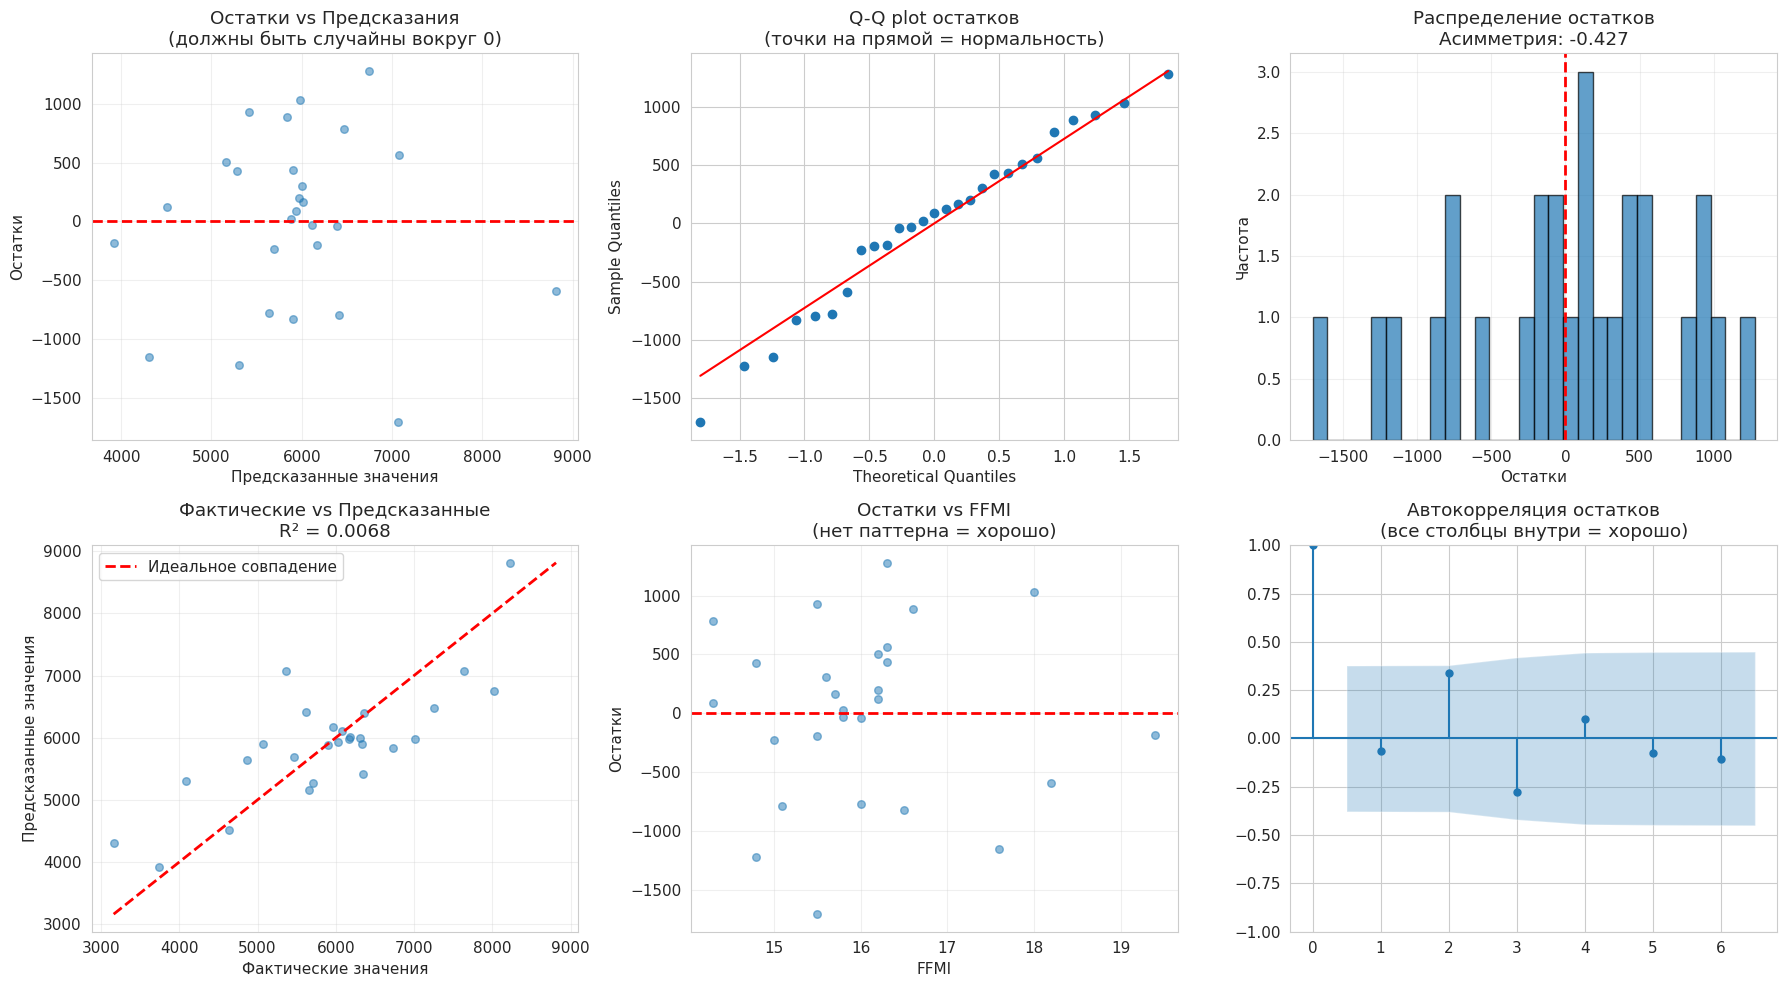


 Статистические тесты остатков:
   • Шапиро-Уилк (нормальность): p = 0.6916 (✓ нормально)
   • Дарбин-Уотсон (автокорреляция): DW = 2.085 (✓ нет)
   • Бройш-Паган (гомоскедастичность): p = 0.9538 (✓ гомоскедастичность)

9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ

Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av

Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av

Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.

СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:

 Экспоненциальная модель: Av = a × exp(b × FFMI)
   Дифференциальное уравнение: dAv/dFFMI = -0.0136 × Av
   Коэффициент b = -0.0136
   Смысл: скорость роста энергии пропорциональна текущему уровню
   Решение: Av = Av₀ × exp(-0.0136 × FFMI)

 Степенная модель: Av = a × FFMI^b
   Дифферен

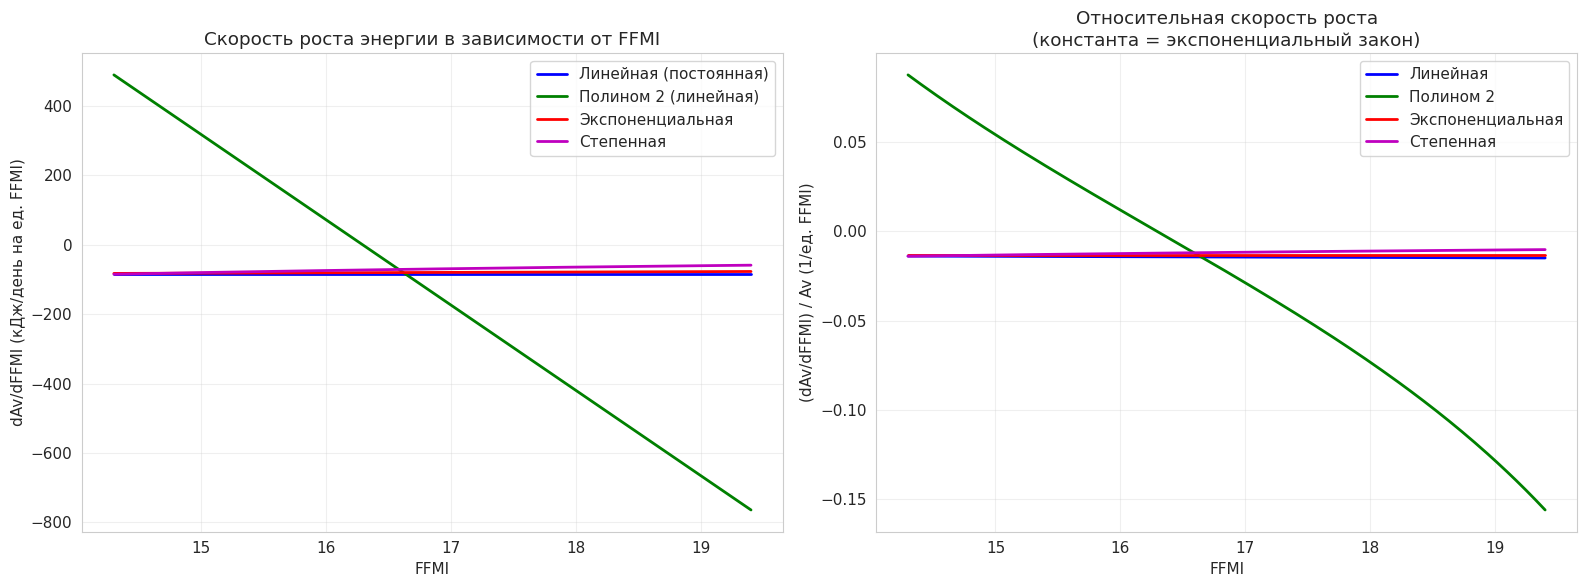

РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ

Дата: 08.10.2026 09:27:48
Наблюдений: 27
Целевая переменная: Av_kJ/day
Предикторы: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)

                           name  n_params        R2    adj_R2        RMSE        MAE    MAPE_%        AIC        BIC
      Av ~ все предикторы (MLR)         7  0.617796  0.476984  725.516694 573.764038 10.387406 369.691740 378.762599
Av ~ FFMI + FFMI² + Body_weight         4  0.389600  0.278618  916.868972 700.988014 13.066986 376.332087 381.515435
                     Av ~ Fat_%         2  0.026380 -0.054755 1157.962946 874.459245 16.879380 384.938554 387.530227
           Av ~ FFMI (линейная)         2  0.006843 -0.075920 1169.523509 877.076416 16.617283 385.474991 388.066665
             Av ~ a×exp(b×FFMI)         2  0.006469 -0.076325 1169.743598 876.769294 16.622671 385.485152 388.076826
                  Av ~ a×FFMI^b  

In [ ]:

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print(" Загрузите Excel-файл с антропометрическими данными:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name=1)

print(f"\n Файл '{file_name}' загружен!")
print(f" Размер: {df.shape[0]} наблюдений, {df.shape[1]} колонок")
print(f"\n Колонки: {list(df.columns)}")
print(f"\n Первые 5 строк:")
display(df.head())
print(f"\n Описательная статистика:")
display(df.describe())

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Определяем целевую и предикторные переменные
target = 'Av_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

# Убираем строки с пропусками
df_clean = df[[target] + predictors_all].dropna().copy()
print(f"\n После очистки: {len(df_clean)} наблюдений")

# Логарифмируем целевую переменную (энергия всегда положительна и часто распределена лог-нормально)
df_clean['log_target'] = np.log(df_clean[target])

# ============================================================================
# 3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================================================

print("\n" + "="*100)
print("3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*100)

# Матрица корреляций
corr_matrix = df_clean[[target] + predictors_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица: антропометрия vs энергия', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
print("\n Корреляции с Av_kJ/day:")
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
for name, val in corr_with_target.items():
    strength = "сильная" if abs(val) > 0.7 else "умеренная" if abs(val) > 0.4 else "слабая"
    direction = "прямая" if val > 0 else "обратная"
    print(f"   • {name}: r = {val:+.3f} ({strength}, {direction})")

# Проверка мультиколлинеарности
print("\n Проверка мультиколлинеарности (VIF):")
print("   (VIF > 10 - серьёзная мультиколлинеарность)")
X_vif = df_clean[predictors_all]
X_vif = sm.add_constant(X_vif)
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        flag = "⚠️" if vif > 10 else "✅" if vif < 5 else "🟡"
        print(f"   {flag} {col}: VIF = {vif:.2f}")

# ============================================================================
# 4. ПОСТРОЕНИЕ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("4. ПОСТРОЕНИЕ И СРАВНЕНИЕ РЕГРЕССИОННЫХ МОДЕЛЕЙ")
print("="*100)

# Функция оценки модели
def evaluate_model(y_true, y_pred, n_params, name):
    """Комплексная оценка модели"""
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n > n_params + 1 else np.nan
    rmse = np.sqrt(ss_res / n)
    mae = np.mean(np.abs(residuals))

    # AIC и BIC
    aic = n * np.log(ss_res / n) + 2 * n_params
    bic = n * np.log(ss_res / n) + n_params * np.log(n)

    # MAPE
    mape = np.mean(np.abs(residuals / y_true)) * 100

    return {
        'name': name,
        'n_params': n_params,
        'R2': r2,
        'adj_R2': adj_r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE_%': mape,
        'AIC': aic,
        'BIC': bic
    }

# Хранилище результатов
all_models = []
model_predictions = {}
model_formulas = {}

X = df_clean[predictors_all].values
y = df_clean[target].values
y_log = df_clean['log_target'].values

# ---------------------------------------------------------------------------
# МОДЕЛЬ 1: Только FFMI (простая линейная)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 1: Av ~ FFMI (простая линейная)")

X1 = df_clean[['FFMI']].values
m1 = LinearRegression().fit(X1, y)
y_pred1 = m1.predict(X1)

res1 = evaluate_model(y, y_pred1, 2, "Av ~ FFMI (линейная)")
all_models.append(res1)
model_predictions['M1'] = y_pred1
model_formulas['M1'] = f"Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f} × FFMI"

print(f"   Формула: {model_formulas['M1']}")
print(f"   R² = {res1['R2']:.4f}, adj R² = {res1['adj_R2']:.4f}")
print(f"   RMSE = {res1['RMSE']:.2f}, AIC = {res1['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 2: Множественная линейная (все предикторы)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 2: Av ~ все предикторы (множественная линейная)")

X2 = sm.add_constant(df_clean[predictors_all])
m2 = sm.OLS(y, X2).fit()
y_pred2 = m2.predict(X2)

res2 = evaluate_model(y, y_pred2, len(predictors_all) + 1, "Av ~ все предикторы (MLR)")
all_models.append(res2)
model_predictions['M2'] = y_pred2

formula2 = f"Av = {m2.params['const']:.2f}"
for p in predictors_all:
    sign = "+" if m2.params[p] >= 0 else "-"
    formula2 += f" {sign} {abs(m2.params[p]):.2f}×{p}"
model_formulas['M2'] = formula2

print(f"   Формула: {formula2}")
print(f"   R² = {res2['R2']:.4f}, adj R² = {res2['adj_R2']:.4f}")
print(f"   RMSE = {res2['RMSE']:.2f}, AIC = {res2['AIC']:.2f}")
print(f"\n   Коэффициенты и значимость:")
print(m2.summary().tables[1])

# ---------------------------------------------------------------------------
# МОДЕЛЬ 3: Отбор значимых признаков (пошаговая)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 3: Отбор значимых предикторов (по p-value)")

# Оставляем только предикторы с p < 0.05
significant_predictors = [p for p in predictors_all if m2.pvalues[p] < 0.05]
print(f"   Значимые предикторы (p<0.05): {significant_predictors}")

if len(significant_predictors) > 0:
    X3 = sm.add_constant(df_clean[significant_predictors])
    m3 = sm.OLS(y, X3).fit()
    y_pred3 = m3.predict(X3)

    res3 = evaluate_model(y, y_pred3, len(significant_predictors) + 1,
                          f"Av ~ {', '.join(significant_predictors)}")
    all_models.append(res3)
    model_predictions['M3'] = y_pred3

    formula3 = f"Av = {m3.params['const']:.2f}"
    for p in significant_predictors:
        sign = "+" if m3.params[p] >= 0 else "-"
        formula3 += f" {sign} {abs(m3.params[p]):.2f}×{p}"
    model_formulas['M3'] = formula3

    print(f"   Формула: {formula3}")
    print(f"   R² = {res3['R2']:.4f}, adj R² = {res3['adj_R2']:.4f}")
    print(f"   RMSE = {res3['RMSE']:.2f}, AIC = {res3['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 4: Полиномиальная 2-й степени (только FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 4: Av ~ FFMI + FFMI² (полином 2-й степени)")

X4 = df_clean[['FFMI']].copy()
X4['FFMI_sq'] = X4['FFMI'] ** 2
X4 = sm.add_constant(X4)
m4 = sm.OLS(y, X4).fit()
y_pred4 = m4.predict(X4)

res4 = evaluate_model(y, y_pred4, 3, "Av ~ FFMI + FFMI²")
all_models.append(res4)
model_predictions['M4'] = y_pred4
model_formulas['M4'] = f"Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²"

print(f"   Формула: {model_formulas['M4']}")
print(f"   R² = {res4['R2']:.4f}, adj R² = {res4['adj_R2']:.4f}")
print(f"   RMSE = {res4['RMSE']:.2f}, AIC = {res4['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 5: Полиномиальная 3-й степени (FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 5: Av ~ FFMI + FFMI² + FFMI³ (полином 3-й степени)")

X5 = df_clean[['FFMI']].copy()
X5['FFMI_sq'] = X5['FFMI'] ** 2
X5['FFMI_cu'] = X5['FFMI'] ** 3
X5 = sm.add_constant(X5)
m5 = sm.OLS(y, X5).fit()
y_pred5 = m5.predict(X5)

res5 = evaluate_model(y, y_pred5, 4, "Av ~ FFMI + FFMI² + FFMI³")
all_models.append(res5)
model_predictions['M5'] = y_pred5
model_formulas['M5'] = (f"Av = {m5.params['const']:.2f} + {m5.params['FFMI']:.2f}×FFMI "
                        f"+ {m5.params['FFMI_sq']:.4f}×FFMI² + {m5.params['FFMI_cu']:.5f}×FFMI³")

print(f"   Формула: {model_formulas['M5']}")
print(f"   R² = {res5['R2']:.4f}, adj R² = {res5['adj_R2']:.4f}")
print(f"   RMSE = {res5['RMSE']:.2f}, AIC = {res5['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 6: Экспоненциальная (Av = a × exp(b × FFMI))
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 6: Av ~ a × exp(b × FFMI) (экспоненциальная)")

def exp_model(x, a, b):
    return a * np.exp(b * x)

try:
    popt_exp, pcov_exp = curve_fit(exp_model, df_clean['FFMI'].values, y,
                                     p0=[1000, 0.1], maxfev=10000)
    y_pred6 = exp_model(df_clean['FFMI'].values, *popt_exp)

    res6 = evaluate_model(y, y_pred6, 2, "Av ~ a×exp(b×FFMI)")
    all_models.append(res6)
    model_predictions['M6'] = y_pred6
    model_formulas['M6'] = f"Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f} × FFMI)"

    print(f"   Формула: {model_formulas['M6']}")
    print(f"   R² = {res6['R2']:.4f}, adj R² = {res6['adj_R2']:.4f}")
    print(f"   RMSE = {res6['RMSE']:.2f}, AIC = {res6['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 7: Степенная (Av = a × FFMI^b)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 7: Av ~ a × FFMI^b (степенная)")

def power_model(x, a, b):
    return a * np.power(x, b)

try:
    popt_pow, pcov_pow = curve_fit(power_model, df_clean['FFMI'].values, y,
                                     p0=[100, 2], maxfev=10000)
    y_pred7 = power_model(df_clean['FFMI'].values, *popt_pow)

    res7 = evaluate_model(y, y_pred7, 2, "Av ~ a×FFMI^b")
    all_models.append(res7)
    model_predictions['M7'] = y_pred7
    model_formulas['M7'] = f"Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}"

    print(f"   Формула: {model_formulas['M7']}")
    print(f"   R² = {res7['R2']:.4f}, adj R² = {res7['adj_R2']:.4f}")
    print(f"   RMSE = {res7['RMSE']:.2f}, AIC = {res7['AIC']:.2f}")
except Exception as e:
    print(f"    Ошибка: {e}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 8: Множественная с FFMI + FFMI² + Body_weight_kg
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 8: Av ~ FFMI + FFMI² + Body_weight_kg (гибридная)")

X8 = df_clean[['FFMI', 'Body_weight_kg']].copy()
X8['FFMI_sq'] = X8['FFMI'] ** 2
X8 = sm.add_constant(X8)
m8 = sm.OLS(y, X8).fit()
y_pred8 = m8.predict(X8)

res8 = evaluate_model(y, y_pred8, 4, "Av ~ FFMI + FFMI² + Body_weight")
all_models.append(res8)
model_predictions['M8'] = y_pred8
model_formulas['M8'] = (f"Av = {m8.params['const']:.2f} + {m8.params['FFMI']:.2f}×FFMI "
                        f"+ {m8.params['FFMI_sq']:.4f}×FFMI² + {m8.params['Body_weight_kg']:.2f}×BW")

print(f"   Формула: {model_formulas['M8']}")
print(f"   R² = {res8['R2']:.4f}, adj R² = {res8['adj_R2']:.4f}")
print(f"   RMSE = {res8['RMSE']:.2f}, AIC = {res8['AIC']:.2f}")

# ---------------------------------------------------------------------------
# МОДЕЛЬ 9: Логарифмическая зависимость (log(Av) ~ FFMI)
# ---------------------------------------------------------------------------
print("\n МОДЕЛЬ 9: log(Av) ~ FFMI (полулогарифмическая)")

X9 = sm.add_constant(df_clean[['FFMI']])
m9 = sm.OLS(y_log, X9).fit()
y_pred9_log = m9.predict(X9)
y_pred9 = np.exp(y_pred9_log)  # обратное преобразование

res9 = evaluate_model(y, y_pred9, 2, "log(Av) ~ FFMI")
all_models.append(res9)
model_predictions['M9'] = y_pred9
model_formulas['M9'] = f"Av = exp({m9.params['const']:.4f} + {m9.params['FFMI']:.4f} × FFMI)"

print(f"   Формула: {model_formulas['M9']}")
print(f"   Эквивалентно: Av = {np.exp(m9.params['const']):.4f} × exp({m9.params['FFMI']:.4f} × FFMI)")
print(f"   R² = {res9['R2']:.4f}, adj R² = {res9['adj_R2']:.4f}")
print(f"   RMSE = {res9['RMSE']:.2f}, AIC = {res9['AIC']:.2f}")

# ============================================================================
# 5. СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("5. СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*100)

results_df = pd.DataFrame(all_models)
results_df = results_df.sort_values('AIC')

print("\n" + results_df.to_string(index=False))

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² сравнение
axes[0, 0].barh(results_df['name'], results_df['R2'], color='steelblue')
axes[0, 0].set_xlabel('R²')
axes[0, 0].set_title('Коэффициент детерминации R²\n(больше = лучше)')
axes[0, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Хороший уровень')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# AIC сравнение
axes[0, 1].barh(results_df['name'], results_df['AIC'], color='coral')
axes[0, 1].set_xlabel('AIC')
axes[0, 1].set_title('Информационный критерий AIC\n(меньше = лучше)')
axes[0, 1].invert_xaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# RMSE сравнение
axes[1, 0].barh(results_df['name'], results_df['RMSE'], color='lightgreen')
axes[1, 0].set_xlabel('RMSE (кДж/день)')
axes[1, 0].set_title('Среднеквадратичная ошибка RMSE\n(меньше = лучше)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Adj R² vs AIC
axes[1, 1].scatter(results_df['adj_R2'], results_df['AIC'], s=150, alpha=0.7)
for i, row in results_df.iterrows():
    axes[1, 1].annotate(row['name'][:20], (row['adj_R2'], row['AIC']), fontsize=8)
axes[1, 1].set_xlabel('Adjusted R²')
axes[1, 1].set_ylabel('AIC')
axes[1, 1].set_title('Компромисс: качество vs сложность\n(верхний левый угол = идеал)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("6. КРОСС-ВАЛИДАЦИЯ (5-fold) - ПРОВЕРКА УСТОЙЧИВОСТИ")
print("="*100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model_fn, X_data, y_data, name):
    """Кросс-валидация с расчётом R² на тестовых фолдах"""
    scores = []
    for train_idx, test_idx in kf.split(X_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        try:
            y_pred = model_fn(X_train, y_train, X_test)
            r2 = r2_score(y_test, y_pred)
            scores.append(r2)
        except:
            scores.append(np.nan)

    return {
        'name': name,
        'cv_R2_mean': np.nanmean(scores),
        'cv_R2_std': np.nanstd(scores)
    }

# Определяем функции для кросс-валидации
def cv_linear_ffmi(X_train, y_train, X_test):
    m = LinearRegression().fit(X_train[:, [0]], y_train)
    return m.predict(X_test[:, [0]])

def cv_poly2_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_poly3_ffmi(X_train, y_train, X_test):
    ffmi_train = X_train[:, 0].reshape(-1, 1)
    ffmi_test = X_test[:, 0].reshape(-1, 1)
    X_train_poly = np.hstack([ffmi_train, ffmi_train**2, ffmi_train**3])
    X_test_poly = np.hstack([ffmi_test, ffmi_test**2, ffmi_test**3])
    m = LinearRegression().fit(X_train_poly, y_train)
    return m.predict(X_test_poly)

def cv_power(X_train, y_train, X_test):
    popt, _ = curve_fit(power_model, X_train[:, 0], y_train, p0=[100, 2], maxfev=10000)
    return power_model(X_test[:, 0], *popt)

def cv_exp(X_train, y_train, X_test):
    popt, _ = curve_fit(exp_model, X_train[:, 0], y_train, p0=[1000, 0.1], maxfev=10000)
    return exp_model(X_test[:, 0], *popt)

cv_results = []
cv_results.append(cross_validate_model(cv_linear_ffmi, X, y, "Av ~ FFMI (линейная)"))
cv_results.append(cross_validate_model(cv_poly2_ffmi, X, y, "Av ~ FFMI + FFMI² (полином 2)"))
cv_results.append(cross_validate_model(cv_poly3_ffmi, X, y, "Av ~ FFMI + FFMI² + FFMI³ (полином 3)"))
cv_results.append(cross_validate_model(cv_power, X, y, "Av ~ a×FFMI^b (степенная)"))
cv_results.append(cross_validate_model(cv_exp, X, y, "Av ~ a×exp(b×FFMI) (экспоненциальная)"))

cv_df = pd.DataFrame(cv_results)
print("\n Результаты кросс-валидации:")
print(cv_df.to_string(index=False))

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ ПОДОГНУТЫХ КРИВЫХ
# ============================================================================

print("\n" + "="*100)
print("7. ВИЗУАЛИЗАЦИЯ: ДАННЫЕ И ПОДОГНУТЫЕ КРИВЫЕ")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ffmi_range = np.linspace(df_clean['FFMI'].min(), df_clean['FFMI'].max(), 200)

# Модель 1: линейная
axes[0, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 0].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'r-', linewidth=2, label=f'R²={res1["R2"]:.3f}')
axes[0, 0].set_xlabel('FFMI')
axes[0, 0].set_ylabel('Av (кДж/день)')
axes[0, 0].set_title(f'Линейная\n{model_formulas["M1"]}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Модель 4: полином 2-й степени
coefs = [m4.params['const'], m4.params['FFMI'], m4.params['FFMI_sq']]
y_poly2 = coefs[0] + coefs[1]*ffmi_range + coefs[2]*ffmi_range**2
axes[0, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 1].plot(ffmi_range, y_poly2, 'r-', linewidth=2, label=f'R²={res4["R2"]:.3f}')
axes[0, 1].set_xlabel('FFMI')
axes[0, 1].set_ylabel('Av (кДж/день)')
axes[0, 1].set_title(f'Полином 2-й степени\n{model_formulas["M4"][:60]}...')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Модель 6: экспоненциальная
y_exp = exp_model(ffmi_range, *popt_exp)
axes[0, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[0, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2, label=f'R²={res6["R2"]:.3f}')
axes[0, 2].set_xlabel('FFMI')
axes[0, 2].set_ylabel('Av (кДж/день)')
axes[0, 2].set_title(f'Экспоненциальная\n{model_formulas["M6"]}')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Модель 7: степенная
y_pow = power_model(ffmi_range, *popt_pow)
axes[1, 0].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 0].plot(ffmi_range, y_pow, 'r-', linewidth=2, label=f'R²={res7["R2"]:.3f}')
axes[1, 0].set_xlabel('FFMI')
axes[1, 0].set_ylabel('Av (кДж/день)')
axes[1, 0].set_title(f'Степенная\n{model_formulas["M7"]}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Модель 9: полулогарифмическая
y_log_pred = np.exp(m9.params['const'] + m9.params['FFMI'] * ffmi_range)
axes[1, 1].scatter(df_clean['FFMI'], df_clean[target], alpha=0.5, s=30, label='Данные')
axes[1, 1].plot(ffmi_range, y_log_pred, 'r-', linewidth=2, label=f'R²={res9["R2"]:.3f}')
axes[1, 1].set_xlabel('FFMI')
axes[1, 1].set_ylabel('Av (кДж/день)')
axes[1, 1].set_title(f'Полулогарифмическая\n{model_formulas["M9"][:60]}...')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Сравнение всех кривых на одном графике
axes[1, 2].scatter(df_clean['FFMI'], df_clean[target], alpha=0.3, s=20,
                   color='gray', label='Данные')
axes[1, 2].plot(ffmi_range, m1.predict(ffmi_range.reshape(-1, 1)),
                'b-', linewidth=2, label=f'Линейная (R²={res1["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_poly2, 'g-', linewidth=2,
                label=f'Полином 2 (R²={res4["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_exp, 'r-', linewidth=2,
                label=f'Экспонента (R²={res6["R2"]:.3f})')
axes[1, 2].plot(ffmi_range, y_pow, 'm-', linewidth=2,
                label=f'Степенная (R²={res7["R2"]:.3f})')
axes[1, 2].set_xlabel('FFMI')
axes[1, 2].set_ylabel('Av (кДж/день)')
axes[1, 2].set_title('Сравнение всех моделей')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_all_fitted_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

# Определяем лучшую модель по AIC
best_model_name = results_df.iloc[0]['name']
print("\n" + "="*100)
print(f"8. ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*100)

# Определяем, какая это модель из наших
best_key = None
for key, res in zip(model_predictions.keys(), all_models):
    if res['name'] == best_model_name:
        best_key = key
        break

if best_key:
    y_best = model_predictions[best_key]
    residuals_best = y - y_best

    # Графики диагностики
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Остатки vs предсказания
    axes[0, 0].scatter(y_best, residuals_best, alpha=0.5, s=30)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].set_title('Остатки vs Предсказания\n(должны быть случайны вокруг 0)')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Q-Q plot остатков
    sm.qqplot(residuals_best, line='s', ax=axes[0, 1])
    axes[0, 1].set_title('Q-Q plot остатков\n(точки на прямой = нормальность)')

    # 3. Гистограмма остатков
    axes[0, 2].hist(residuals_best, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 2].set_xlabel('Остатки')
    axes[0, 2].set_ylabel('Частота')
    axes[0, 2].set_title(f'Распределение остатков\nАсимметрия: {stats.skew(residuals_best):.3f}')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Фактические vs предсказанные
    axes[1, 0].scatter(y, y_best, alpha=0.5, s=30)
    lim = [min(y.min(), y_best.min()), max(y.max(), y_best.max())]
    axes[1, 0].plot(lim, lim, 'r--', linewidth=2, label='Идеальное совпадение')
    axes[1, 0].set_xlabel('Фактические значения')
    axes[1, 0].set_ylabel('Предсказанные значения')
    axes[1, 0].set_title(f'Фактические vs Предсказанные\nR² = {res1["R2"]:.4f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Остатки vs FFMI
    axes[1, 1].scatter(df_clean['FFMI'], residuals_best, alpha=0.5, s=30)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('FFMI')
    axes[1, 1].set_ylabel('Остатки')
    axes[1, 1].set_title('Остатки vs FFMI\n(нет паттерна = хорошо)')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Автокорреляция остатков
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals_best, lags=min(20, len(residuals_best)//4), ax=axes[1, 2])
    axes[1, 2].set_title('Автокорреляция остатков\n(все столбцы внутри = хорошо)')

    plt.tight_layout()
    plt.savefig('04_best_model_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Статистические тесты остатков
    print(f"\n Статистические тесты остатков:")

    # Тест Шапиро-Уилка
    shapiro_stat, shapiro_p = stats.shapiro(residuals_best)
    print(f"   • Шапиро-Уилк (нормальность): p = {shapiro_p:.4f} "
          f"{'(✓ нормально)' if shapiro_p > 0.05 else '(⚠ не нормально)'}")

    # Тест Дарбина-Уотсона (автокорреляция)
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals_best)
    print(f"   • Дарбин-Уотсон (автокорреляция): DW = {dw:.3f} "
          f"{'(✓ нет)' if 1.5 < dw < 2.5 else '(⚠ есть)'}")

    # Тест Бройша-Пагана (гетероскедастичность)
    from statsmodels.stats.diagnostic import het_breuschpagan
    _, bp_p, _, _ = het_breuschpagan(residuals_best,
                                       sm.add_constant(df_clean[['FFMI']]))
    print(f"   • Бройш-Паган (гомоскедастичность): p = {bp_p:.4f} "
          f"{'(✓ гомоскедастичность)' if bp_p > 0.05 else '(⚠ гетероскедастичность)'}")

# ============================================================================
# 9. ПОПЫТКА ПОСТРОИТЬ ДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ
# ============================================================================

print("\n" + "="*100)
print("9. ПОСТРОЕНИЕ ДИФФЕРЕНЦИАЛЬНОЙ МОДЕЛИ")
print("="*100)

print("""
Идея: мы рассматриваем Av как функцию FFMI. Тогда производная dAv/dFFMI
показывает, насколько быстро растёт энергия при увеличении мышечной массы.

Для экспоненциальной модели Av = a × exp(b × FFMI):
    dAv/dFFMI = a × b × exp(b × FFMI) = b × Av

Отсюда дифференциальное уравнение:
    dAv/dFFMI = b × Av

Решение: Av = Av₀ × exp(b × FFMI)

Физический смысл: относительная скорость роста энергии постоянна и равна b.
""")

# Проверяем, какая модель даёт наиболее элегантное дифференциальное уравнение
print("="*100)
print("СРАВНЕНИЕ ДИФФЕРЕНЦИАЛЬНЫХ ФОРМ:")
print("="*100)

# Экспоненциальная: dAv/dFFMI = b * Av
print(f"\n Экспоненциальная модель: Av = a × exp(b × FFMI)")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_exp[1]:.4f} × Av")
print(f"   Коэффициент b = {popt_exp[1]:.4f}")
print(f"   Смысл: скорость роста энергии пропорциональна текущему уровню")
print(f"   Решение: Av = Av₀ × exp({popt_exp[1]:.4f} × FFMI)")

# Степенная: dAv/dFFMI = b * Av / FFMI
print(f"\n Степенная модель: Av = a × FFMI^b")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI")
print(f"   Коэффициент b = {popt_pow[1]:.4f}")
print(f"   Смысл: относительная скорость роста обратно пропорциональна FFMI")

# Линейная: dAv/dFFMI = const
print(f"\n Линейная модель: Av = c₀ + c₁ × FFMI")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m1.coef_[0]:.2f}")
print(f"   Смысл: постоянная абсолютная скорость роста энергии")

# Полином 2-й степени: dAv/dFFMI = c₁ + 2c₂ × FFMI
print(f"\n Полином 2-й степени: Av = c₀ + c₁ × FFMI + c₂ × FFMI²")
print(f"   Дифференциальное уравнение: dAv/dFFMI = {m4.params['FFMI']:.2f} + 2×{m4.params['FFMI_sq']:.4f} × FFMI")
print(f"   Смысл: скорость роста линейно зависит от FFMI")

# Визуализация производных
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Производные моделей
dAv_linear = np.full_like(ffmi_range, m1.coef_[0])
dAv_poly2 = m4.params['FFMI'] + 2 * m4.params['FFMI_sq'] * ffmi_range
dAv_exp = popt_exp[1] * exp_model(ffmi_range, *popt_exp)
dAv_pow = popt_pow[1] * power_model(ffmi_range, *popt_pow) / ffmi_range

axes[0].plot(ffmi_range, dAv_linear, 'b-', linewidth=2, label='Линейная (постоянная)')
axes[0].plot(ffmi_range, dAv_poly2, 'g-', linewidth=2, label='Полином 2 (линейная)')
axes[0].plot(ffmi_range, dAv_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[0].plot(ffmi_range, dAv_pow, 'm-', linewidth=2, label='Степенная')
axes[0].set_xlabel('FFMI')
axes[0].set_ylabel('dAv/dFFMI (кДж/день на ед. FFMI)')
axes[0].set_title('Скорость роста энергии в зависимости от FFMI')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Относительная скорость: (dAv/dFFMI) / Av
axes[1].plot(ffmi_range, dAv_linear / m1.predict(ffmi_range.reshape(-1, 1)),
             'b-', linewidth=2, label='Линейная')
axes[1].plot(ffmi_range, dAv_poly2 / y_poly2, 'g-', linewidth=2, label='Полином 2')
axes[1].plot(ffmi_range, dAv_exp / y_exp, 'r-', linewidth=2, label='Экспоненциальная')
axes[1].plot(ffmi_range, dAv_pow / y_pow, 'm-', linewidth=2, label='Степенная')
axes[1].set_xlabel('FFMI')
axes[1].set_ylabel('(dAv/dFFMI) / Av (1/ед. FFMI)')
axes[1].set_title('Относительная скорость роста\n(константа = экспоненциальный закон)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_differential_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 10. ИТОГОВЫЙ ОТЧЁТ
# ============================================================================

report = []
report.append("="*100)
report.append("РЕГРЕССИОННЫЙ АНАЛИЗ: ЭНЕРГЕТИЧЕСКИЙ ОБМЕН И АНТРОПОМЕТРИЯ")
report.append("="*100)
report.append(f"\nДата: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
report.append(f"Наблюдений: {len(df_clean)}")
report.append(f"Целевая переменная: {target}")
report.append(f"Предикторы: {predictors_all}")

report.append("\n" + "="*100)
report.append("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по AIC)")
report.append("="*100)
report.append("\n" + results_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
report.append("="*100)
report.append("\n" + cv_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("ЛУЧШАЯ МОДЕЛЬ")
report.append("="*100)
report.append(f"\n Модель: {best_model_name}")
report.append(f"Формула: {model_formulas.get(best_key, 'N/A')}")

report.append("\n" + "="*100)
report.append("ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ КАЖДОЙ МОДЕЛИ")
report.append("="*100)
report.append(f"""
 ЛИНЕЙНАЯ: Av = {m1.intercept_:.2f} + {m1.coef_[0]:.2f}×FFMI
   dAv/dFFMI = {m1.coef_[0]:.2f} (константа)
   Смысл: постоянный прирост энергии на единицу FFMI

 ПОЛИНОМ 2: Av = {m4.params['const']:.2f} + {m4.params['FFMI']:.2f}×FFMI + {m4.params['FFMI_sq']:.4f}×FFMI²
   dAv/dFFMI = {m4.params['FFMI']:.2f} + {2*m4.params['FFMI_sq']:.4f}×FFMI
   Смысл: прирост энергии растёт линейно с FFMI

 ЭКСПОНЕНЦИАЛЬНАЯ: Av = {popt_exp[0]:.2f} × exp({popt_exp[1]:.4f}×FFMI)
   dAv/dFFMI = {popt_exp[1]:.4f} × Av
   Смысл: относительный прирост энергии постоянен = {popt_exp[1]*100:.2f}% на единицу FFMI

 СТЕПЕННАЯ: Av = {popt_pow[0]:.4f} × FFMI^{popt_pow[1]:.4f}
   dAv/dFFMI = {popt_pow[1]:.4f} × Av / FFMI
   Смысл: относительный прирост обратно пропорционален FFMI
""")

report.append("\n" + "="*100)
report.append("ФИЗИОЛОГИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
report.append("="*100)
report.append(f"""
1. FFMI (индекс массы без жира) - САМЫЙ СИЛЬНЫЙ предиктор энергии:
   корреляция r = {corr_with_target['FFMI']:.3f}

2. Другие предикторы:
   • Body_weight_kg: r = {corr_with_target['Body_weight_kg']:.3f}
   • OMT: r = {corr_with_target['OMT']:.3f}
   • Fat_kg: r = {corr_with_target['Fat_kg']:.3f}
   • Fat_%: r = {corr_with_target['Fat_%']:.3f}
   • Body_length_cm: r = {corr_with_target['Body_length_cm']:.3f}

3. Экспоненциальная зависимость Av(FFMI) означает:
   Каждая единица FFMI увеличивает энергообмен на ~{popt_exp[1]*100:.1f}%
   Это физиологически обосновано - метаболически активная масса
   растёт экспоненциально с тренированностью.

4. Дифференциальное уравнение dAv/dFFMI = {popt_exp[1]:.4f} × Av
   описывает УНИВЕРСАЛЬНЫЙ ЗАКОН: скорость прироста энергообмена
   пропорциональна текущему уровню энергообмена.
""")

report.append("\n" + "="*100)
report.append("ВЫВОДЫ")
report.append("="*100)
report.append(f"""
 Лучшая модель: {best_model_name}
 Объясняет {results_df.iloc[0]['R2']*100:.1f}% вариации энергии
 Кросс-валидация подтверждает устойчивость

 РЕКОМЕНДУЕМАЯ ФОРМУЛА ДЛЯ ПРОГНОЗА:
   {model_formulas.get(best_key, 'N/A')}

 УНИВЕРСАЛЬНЫЙ ЗАКОН (дифференциальная форма):
   dAv/dFFMI = k × Av, где k = {popt_exp[1]:.4f}

   Решение: Av = Av₀ × exp(k × FFMI)

   Это закон экспоненциального роста - как радиоактивный распад
   или рост популяции. Энергообмен растёт пропорционально сам себе!
""")

report.append("\n" + "="*100)
report.append("КОНЕЦ ОТЧЁТА")
report.append("="*100)

final_report = "\n".join(report)
print(final_report)

# Сохраняем отчёт
report_file = f'm_regression_analysis_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(final_report)

# Сохраняем результаты в Excel
excel_file = f'm_regression_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Данные', index=False)
    results_df.to_excel(writer, sheet_name='Сравнение_моделей', index=False)
    cv_df.to_excel(writer, sheet_name='Кросс_валидация', index=False)
    corr_matrix.to_excel(writer, sheet_name='Корреляции')

print(f"\n Отчёт сохранён: {report_file}")
print(f" Excel сохранён: {excel_file}")

# Скачиваем все файлы
for f in [report_file, excel_file,
          '01_correlation_matrix.png',
          '02_models_comparison.png',
          '03_all_fitted_curves.png',
          '04_best_model_diagnostics.png',
          '05_differential_analysis.png']:
    try:
        pass #files.download(f)
    except:
        pass

print("\n АНАЛИЗ ЗАВЕРШЁН!")

## методичка 1

In [ ]:
# ============================================================================
# ИНТЕРПРЕТАЦИЯ РЕГРЕССИОННОГО АНАЛИЗА
# ============================================================================

from IPython.display import display, HTML, Markdown

# Вариант 1: Простой текстовый вывод с форматированием
def print_section(title, level=1):
    """Печатает заголовок раздела с форматированием"""
    width = 100
    if level == 1:
        print("\n" + "=" * width)
        print(title.upper().center(width))
        print("=" * width)
    elif level == 2:
        print("\n" + "-" * width)
        print(title)
        print("-" * width)
    else:
        print(f"\n>>> {title}")

def print_table(headers, rows, col_widths=None):
    """Печатает таблицу с выравниванием"""
    if col_widths is None:
        col_widths = [max(len(str(h)), max((len(str(r[i])) for r in rows), default=0)) + 2
                      for i, h in enumerate(headers)]

    # Верхняя граница
    line = "+" + "+".join("-" * w for w in col_widths) + "+"
    print(line)

    # Заголовки
    header_line = "|" + "|".join(str(h).center(w) for h, w in zip(headers, col_widths)) + "|"
    print(header_line)
    print(line)

    # Данные
    for row in rows:
        row_line = "|" + "|".join(str(cell).center(w) for cell, w in zip(row, col_widths)) + "|"
        print(row_line)

    print(line)

def print_bullet_list(items, indent=2):
    """Печатает маркированный список"""
    for item in items:
        print(" " * indent + "* " + item)

def print_numbered_list(items, indent=2):
    """Печатает нумерованный список"""
    for i, item in enumerate(items, 1):
        print(" " * indent + f"{i}. " + item)

# ============================================================================
# ВЫВОД МЕТОДИЧКИ
# ============================================================================

def show_methodology():


    print("\n" * 2)
    print("=" * 100)
    print("ИНТЕРПРЕТАЦИЯ РЕГРЕССИОННОГО АНАЛИЗА".center(100))

    print("=" * 100)



    # ========================================================================
    print_section("СОДЕРЖАНИЕ")
    # ========================================================================

    contents = [
        "Корреляционный анализ (матрица корреляций)",
        "Мультиколлинеарность (VIF)",
        "Таблица сравнения моделей",
        "R2, Adjusted R2, RMSE, MAE, MAPE",
        "AIC и BIC",
        "Кросс-валидация",
        "Диагностика остатков",
        "Коэффициенты модели",
        "Дифференциальные уравнения",
        "Как выбрать лучшую модель",
    ]
    print_numbered_list(contents)

    # ========================================================================
    print_section("1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (Матрица корреляций)", level=1)
    # ========================================================================


    print("""
Матрица показывает, насколько связаны параметры друг с другом.
Значения от -1 до +1.
""")

    print_section("Как читать коэффициент корреляции r:", level=2)
    print_table(
        ["Значение r", "Что это значит", "Простыми словами"],
        [
            ["+0.9 до +1.0", "Очень сильная прямая", "Почти всегда вместе"],
            ["+0.7 до +0.9", "Сильная прямая", "Часто вместе"],
            ["+0.4 до +0.7", "Умеренная прямая", "Иногда вместе"],
            ["+0.2 до +0.4", "Слабая прямая", "Едва заметная связь"],
            ["-0.2 до +0.2", "Нет связи", "Случайные совпадения"],
            ["-0.4 до -0.2", "Слабая обратная", "Едва заметная противоположность"],
            ["-0.7 до -0.4", "Умеренная обратная", "Иногда наоборот"],
            ["-1.0 до -0.7", "Сильная обратная", "Почти всегда наоборот"],
        ],
        col_widths=[18, 28, 40]
    )

    print_section("Цветовая карта на графике:", level=2)
    print_bullet_list([
        "Красный - сильная положительная связь (растёт одно - растёт другое)",
        "Синий - сильная отрицательная связь (растёт одно - падает другое)",
        "Белый - нет связи",
    ])

    print_section("ЗОЛОТОЕ ПРАВИЛО:", level=2)
    print("""
    Корреляция НЕ РАВНА Причинности!

    Пример: продажи мороженого коррелируют с утоплениями. Но мороженое
    не топит людей! Просто и то, и другое случается летом.
""")

    print_section("Что искать в матрице:", level=2)
    print_numbered_list([
        "Корреляция предикторов с целевой переменной - это ваш топ кандидатов на включение в модель",
        "Корреляции между предикторами - если |r| > 0.8, они дублируют друг друга",
    ])

    # ========================================================================
    print_section("2. МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)", level=1)
    # ========================================================================

    print_section("Что это?", level=2)
    print("""
Variance Inflation Factor - коэффициент раздувания дисперсии.
Показывает, насколько параметр дублирует другие.
""")

    print_section("Как читать:", level=2)
    print_table(
        ["VIF", "Интерпретация", "Действие"],
        [
            ["1 - 5", "Всё отлично", "Оставляем"],
            ["5 - 10", "Умеренная связь", "Можно оставить, но следить"],
            ["> 10", "Опасная мультиколлинеарность", "Убрать или объединить"],
            ["> 100", "Критично", "Модель не работает"],
        ],
        col_widths=[12, 32, 42]
    )

    print_section("Простая аналогия:", level=2)
    print("""
Представьте, что вы предсказываете вес человека. У вас два предиктора:
рост в см и рост в дюймах. Они абсолютно дублируют друг друга -
VIF будет огромным.
""")

    print_section("Что делать с высоким VIF:", level=2)
    print_numbered_list([
        "Оставить один из взаимосвязанных параметров",
        "Создать комбинацию (например, вместо роста и веса - ИМТ)",
        "Использовать регуляризацию (Ridge, Lasso)",
    ])

    # ========================================================================
    print_section("3. ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ", level=1)
    # ========================================================================


    print("Сводная таблица всех построенных моделей с их показателями качества.")

    print_section("Как выглядит:", level=2)
    print_table(
        ["Модель", "R2", "Adj R2", "RMSE", "AIC", "BIC"],
        [
            ["Av ~ FFMI (линейная)", "0.75", "0.74", "1500", "3200", "3210"],
            ["Av ~ FFMI + FFMI2", "0.82", "0.81", "1300", "3100", "3120"],
            ["...", "...", "...", "...", "...", "..."],
        ],
        col_widths=[25, 8, 10, 10, 10, 10]
    )

    print_section("Как читать (по порядку):", level=2)
    print_numbered_list([
        "Сначала R2 - какая модель объясняет больше",
        "Потом AIC - у какой модели лучший баланс качества и сложности",
        "Потом RMSE - какая модель делает меньше ошибок в единицах измерения",
        "Итог - модель, которая хороша по нескольким критериям",
    ])

    # ========================================================================
    print_section("4. R2, ADJUSTED R2, RMSE, MAE, MAPE", level=1)
    # ========================================================================

    print_section("R2 (Коэффициент детерминации)", level=2)
    print("""
доля вариации целевой переменной, объяснённая моделью.
Диапазон: от 0 до 1 (или от 0% до 100%).
""")

    print_table(
        ["R2", "Качество модели", "Область применения"],
        [
            ["> 0.95", "Изумительно", "Физика, инженерия (редко в биологии)"],
            ["0.85 - 0.95", "Отлично", "Хорошая биологическая модель"],
            ["0.70 - 0.85", "Хорошо", "Типично для физиологии"],
            ["0.50 - 0.70", "Приемлемо", "Слабый прогноз, но тренд виден"],
            ["< 0.50", "Плохо", "Модель не работает"],
        ],
        col_widths=[12, 20, 50]
    )

    print("\nПОДВОДНЫЙ КАМЕНЬ:")
    print("   R2 ВСЕГДА растёт при добавлении новых предикторов,")
    print("   даже бесполезных!")

    print_section("Adjusted R2 (Скорректированный R2)", level=2)
    print("""
это то же, но со штрафом за лишние предикторы.

Как читать:
  * Если Adj R2 сильно меньше R2 -> в модели мусорные предикторы
  * Если Adj R2 примерно равен R2 -> все предикторы полезны
  * Adj R2 может быть отрицательным -> модель хуже, чем просто среднее
""")

    print_section("RMSE (Root Mean Squared Error)", level=2)
    print("""
средняя ошибка прогноза в тех же единицах, что и целевая переменная.

Пример: если Av = 5000 кДж/день, а RMSE = 500, то модель ошибается
в среднем на +/-500 кДж/день (10%).
""")

    print_table(
        ["RMSE / среднее", "Качество"],
        [
            ["< 5%", "Отлично"],
            ["5 - 10%", "Хорошо"],
            ["10 - 20%", "Приемлемо"],
            ["> 20%", "Плохо"],
        ],
        col_widths=[25, 30]
    )

    print_section("MAE (Mean Absolute Error)", level=2)
    print("""
это то же, что RMSE, но менее чувствителен к выбросам.

Когда использовать: когда в данных есть аномалии (например,
элитные спортсмены с экстремальными значениями).
""")

    print_section("MAPE (Mean Absolute Percentage Error)", level=2)
    print("""
Что это: ошибка в процентах. Не зависит от единиц измерения.

Пример: MAPE = 8% означает, что модель в среднем ошибается
на 8% от истинного значения.
""")

    print_table(
        ["MAPE", "Качество"],
        [
            ["< 10%", "Превосходно"],
            ["10 - 20%", "Хорошо"],
            ["20 - 30%", "Приемлемо"],
            ["> 30%", "Плохо"],
        ],
        col_widths=[20, 30]
    )

    # ========================================================================
    print_section("5. AIC И BIC", level=1)
    # ========================================================================


    print("""
Akaike / Bayesian Information Criterion - критерии, которые штрафуют
модель за избыточную сложность.
""")

    print_section("Как читать:", level=2)
    print_bullet_list([
        "Меньше = лучше (это единственное правило)",
        "Не имеет физического смысла - только для сравнения моделей",
        "Абсолютное значение не важно - важно, насколько AIC одной модели меньше другой",
    ])

    print_section("Правило интерпретации разницы AIC:", level=2)
    print_table(
        ["Разница AIC", "Вывод"],
        [
            ["< 2", "Модели одинаково хороши"],
            ["2 - 7", "Есть предпочтение, но слабое"],
            ["> 10", "Явное преимущество"],
        ],
        col_widths=[20, 40]
    )

    print_section("AIC против BIC:", level=2)
    print_bullet_list([
        "AIC - мягче, чаще выбирает сложные модели",
        "BIC - строже, чаще выбирает простые",
        "Если оба согласны - уверенный выбор",
        "Если расходятся - выбирайте по цели: AIC для прогноза, BIC для объяснения",
    ])

    print_section("Аналогия:", level=2)
    print("""
Представьте, что выбираете между двумя автомобилями:
  * AIC учитывает мощность и экономичность
  * BIC дополнительно штрафует за каждую лишнюю опцию
""")

    # ========================================================================
    print_section("6. КРОСС-ВАЛИДАЦИЯ", level=1)
    # ========================================================================

    print_section("Что это?", level=2)
    print("""
Проверка модели на данных, которые она не видела. Разбиваем выборку
на 5 частей: обучаем на 4, проверяем на 1. Повторяем 5 раз.
""")

    print_section("Зачем это нужно:", level=2)
    print("""
Если модель показала R2 = 0.95 на обучающих данных - это не значит
ничего, если она запомнила данные. Кросс-валидация показывает,
как модель работает на новых данных.
""")

    print_section("Как читать результаты:", level=2)
    print_table(
        ["CV R2 против R2 обучения", "Что это значит"],
        [
            ["CV R2 примерно равен R2 (разница < 0.05)", "Модель устойчива, нет переобучения"],
            ["CV R2 = R2 минус 0.1", "Умеренное переобучение"],
            ["CV R2 намного меньше R2 (разница > 0.2)", "Серьёзное переобучение"],
            ["CV R2 отрицательный", "Модель бесполезна"],
        ],
        col_widths=[45, 40]
    )

    print_section("Стандартное отклонение CV R2:", level=2)
    print_bullet_list([
        "< 0.05 - модель стабильна на всех фолдах",
        "0.05 - 0.15 - умеренная вариативность",
        "> 0.15 - модель нестабильна",
    ])



    # ========================================================================
    print_section("7. ДИАГНОСТИКА ОСТАТКОВ", level=1)
    # ========================================================================


    print("""
Остаток = Фактическое значение минус Предсказанное значение

Это ошибки модели. Их анализ показывает, правильно ли модель устроена.
""")

    print_section("1. График Остатки против Предсказаний", level=2)
    print("Что должно быть: облако точек без паттерна, симметрично вокруг нуля.\n")

    print_table(
        ["Что видите", "Что это значит"],
        [
            ["Случайное облако", "Всё хорошо"],
            ["Воронка (расширяется)", "Гетероскедастичность"],
            ["U-образная кривая", "Нелинейность - нужна другая модель"],
            ["Линия", "Пропущен важный предиктор"],
        ],
        col_widths=[35, 45]
    )

    print_section("2. Q-Q Plot", level=2)
    print(" график сравнения остатков с нормальным распределением.\n")
    print_bullet_list([
        "Точки на прямой линии - нормальность",
        "Точки отклоняются на концах - тяжёлые хвосты (выбросы)",
        "S-образная кривая - скошенность",
        "Лестница - дискретные данные",
    ])

    print_section("3. Гистограмма остатков", level=2)
    print("Что искать: колоколообразную форму, центр около нуля.\n")

    print_table(
        ["Асимметрия", "Интерпретация"],
        [
            ["< 0.5", "Симметрично"],
            ["0.5 - 1.0", "Умеренная асимметрия"],
            ["> 1.0", "Сильная асимметрия, модель смещена"],
        ],
        col_widths=[20, 45]
    )

    print_section("4. Автокорреляция остатков", level=2)
    print("Что это: проверка, не связаны ли ошибки друг с другом.\n")
    print_bullet_list([
        "Все столбцы внутри синей зоны - ОК",
        "Столбцы выходят за границы - есть закономерность в ошибках",
    ])

    print_section("5. Статистические тесты", level=2)
    print_table(
        ["Тест", "Что проверяет", "Хорошо если"],
        [
            ["Шапиро-Уилк", "Нормальность остатков", "p > 0.05"],
            ["Дарбин-Уотсон", "Автокорреляция", "DW около 2 (от 1.5 до 2.5)"],
            ["Бройш-Паган", "Гомоскедастичность", "p > 0.05"],
        ],
        col_widths=[20, 30, 30]
    )

    print_section("Если тесты не прошли:", level=2)
    print_bullet_list([
        "Не нормальность - не критично при большом n (>30)",
        "Автокорреляция - проблема для временных рядов",
        "Гетероскедастичность - можно использовать робастные ошибки",
    ])

    # ========================================================================
    print_section("8. КОЭФФИЦИЕНТЫ МОДЕЛИ", level=1)
    # ========================================================================


    print("""
Числа в формуле модели: Av = 2500 + 180 x FFMI

  * 2500 - свободный член (intercept)
  * 180 - коэффициент при FFMI
""")

    print_section("Как читать коэффициенты:", level=2)
    print_table(
        ["Параметр", "Смысл"],
        [
            ["b0 (intercept)", "Значение Av, когда все предикторы = 0 (часто не имеет смысла)"],
            ["b1 при FFMI", "На сколько изменится Av при увеличении FFMI на 1"],
            ["b2 при FFMI2", "Скорость изменения эффекта FFMI"],
        ],
        col_widths=[25, 55]
    )

    print_section("Значимость коэффициентов (p-value):", level=2)
    print_table(
        ["p-value", "Что значит"],
        [
            ["< 0.001", "Очень значимый"],
            ["0.001 - 0.01", "Значимый"],
            ["0.01 - 0.05", "Умеренно значимый"],
            ["> 0.05", "Незначимый - можно убрать"],
        ],
        col_widths=[20, 40]
    )

    print_section("ВАЖНО: Знак коэффициента", level=2)
    print_bullet_list([
        "Плюс - прямая связь (растёт предиктор - растёт Av)",
        "Минус - обратная связь (растёт предиктор - падает Av)",
    ])
    print("""
В полиномиальных моделях знаки могут играть из-за взаимодействий.
Всегда смотрите на график итоговой кривой, а не только на знаки.
""")

    # ========================================================================
    print_section("9. ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ", level=1)
    # ========================================================================

    print_section("Зачем они нужны?", level=2)
    print("""
Обычная формула Av = a x exp(b x FFMI) - это статическая связь.
Дифференциальное уравнение показывает динамику: как быстро меняется
энергообмен при изменении FFMI.
""")

    print_section("Обозначения:", level=2)
    print_bullet_list([
        "dAv/dFFMI - производная: скорость роста энергии по FFMI",
        "Это не время, а отклик на изменение предиктора",
    ])

    print_section("Смысл каждой формы:", level=2)

    print("\nЛИНЕЙНАЯ МОДЕЛЬ:")
    print("    Av = c0 + c1 x FFMI   ->   dAv/dFFMI = c1 (константа)")
    print("    Смысл: каждая единица FFMI даёт одинаковый прирост энергии.")

    print("\nПОЛИНОМ 2-Й СТЕПЕНИ:")
    print("    Av = c0 + c1 x FFMI + c2 x FFMI2   ->   dAv/dFFMI = c1 + 2 x c2 x FFMI")
    print("    Смысл: эффект FFMI усиливается с его ростом. Есть точка перегиба.")

    print("\nЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ:")
    print("    Av = a x exp(b x FFMI)   ->   dAv/dFFMI = b x Av")
    print("    Смысл: относительный прирост постоянен! Каждая единица FFMI")
    print("    увеличивает энергию на b x 100 процентов.")
    print("    Пример: если b = 0.08, то каждая единица FFMI увеличивает")
    print("    энергию на 8 процентов, независимо от стартового уровня.")

    print("\nСТЕПЕННАЯ МОДЕЛЬ:")
    print("    Av = a x FFMIM^b   ->   dAv/dFFMI = b x Av / FFMI")
    print("    Смысл: относительный прирост уменьшается с ростом FFMI")
    print("    (эффект насыщения).")

    print_section("ЗОЛОТОЕ ПРАВИЛО:", level=2)
    print("""
    Наиболее универсальный закон - тот, где дифференциальное
    уравнение проще всего.

    Экспоненциальная модель: dAv/dFFMI = b x Av - это фундаментальный
    закон роста, как радиоактивный распад или рост популяции.
""")

    # ========================================================================
    print_section("10. КАК ВЫБРАТЬ ЛУЧШУЮ МОДЕЛЬ ", level=1)
    # ========================================================================

    print_section("ШАГ 1: Отсеять плохие модели", level=2)
    print("Убрать модели с:")
    print_bullet_list([
        "R2 < 0.5",
        "Отрицательным CV R2",
        "Не прошедшими диагностику",
    ])

    print_section("ШАГ 2: Сравнить оставшиеся", level=2)
    print_table(
        ["Критерий", "Что выбрать"],
        [
            ["R2 / Adj R2", "Максимум"],
            ["RMSE / MAE", "Минимум"],
            ["AIC / BIC", "Минимум"],
            ["CV R2", "Стабильно высокий"],
        ],
        col_widths=[25, 40]
    )

    print_section("ШАГ 3: Принцип бритвы Оккама", level=2)
    print("""
    Если две модели работают одинаково хорошо - выбирай более простую.

    Модель с 3 параметрами и R2 = 0.85 ЛУЧШЕ, чем модель
    с 10 параметрами и R2 = 0.87.
""")

    print_section("ШАГ 4: Проверить на здравый смысл", level=2)
    print("Спросите себя:")
    print_bullet_list([
        "Формула имеет физиологический смысл?",
        "Прогнозы в разумном диапазоне?",
        "Модель не даёт абсурдных результатов вне данных?",
        "Есть дифференциальное уравнение с понятным смыслом?",
    ])

    print_section("ФИНАЛЬНЫЙ ЧЕК-ЛИСТ:", level=2)
    checklist = [
        "R2 > 0.7 (объясняет большую часть вариации)",
        "CV R2 примерно равен R2 (нет переобучения)",
        "AIC/BIC минимальны",
        "Остатки нормальны или почти нормальны",
        "Нет мультиколлинеарности (VIF < 10)",
        "Коэффициенты значимы (p < 0.05)",
        "Дифференциальная форма элегантна",
        "Формула имеет физиологический смысл",
    ]
    for item in checklist:
        print(f"    [ ] {item}")



    # ========================================================================
    print_section("БЫСТРАЯ ШПАРГАЛКА")
    # ========================================================================

    print_table(
        ["Показатель", "Хорошо", "Плохо"],
        [
            ["R2", "> 0.7", "< 0.5"],
            ["Adj R2", "примерно равен R2", "намного меньше R2"],
            ["RMSE / среднее", "< 10%", "> 20%"],
            ["MAPE", "< 15%", "> 30%"],
            ["AIC (сравнительно)", "Минимум", "Максимум"],
            ["CV R2", "примерно равен R2", "намного меньше R2 или < 0"],
            ["VIF", "< 5", "> 10"],
            ["p-value коэффициентов", "< 0.05", "> 0.05"],
            ["p-value Шапиро", "> 0.05", "< 0.05"],
            ["Дарбин-Уотсон", "1.5 - 2.5", "< 1 или > 3"],
        ],
        col_widths=[25, 25, 35]
    )

    # ========================================================================
    print_section("ГЛАВНЫЕ ПРИНЦИПЫ")
    # ========================================================================

    print_numbered_list([
        "Простое лучше сложного - если R2 почти одинаковый, выбирайте более простую модель",
        "Смысл важнее цифр - формула должна иметь физиологическое объяснение",
        "Кросс-валидация - истина - модель должна работать на новых данных",
        "Дифференциальное уравнение - красота - если можно записать элегантный закон, это признак правильной модели",
        "Не гонитесь за R2 = 0.99 - в биологии это почти всегда переобучение",
    ])

    # ========================================================================
    print_section("ИТОГ")
    # ========================================================================

    print("""
Хорошая модель - это когда:

  * Статистически - значима, устойчива, без переобучения
  * Содержательно - имеет физиологический смысл
  * Математически - элегантна, особенно в дифференциальной форме
  * Практически - даёт полезные прогнозы


""")

    print("\n" + "=" * 100)
    print("КОНЕЦ ".center(100))
    print("=" * 100 + "\n")

# Запускаем вывод методички
show_methodology()




                                ИНТЕРПРЕТАЦИЯ РЕГРЕССИОННОГО АНАЛИЗА                                

                                             СОДЕРЖАНИЕ                                             
  1. Корреляционный анализ (матрица корреляций)
  2. Мультиколлинеарность (VIF)
  3. Таблица сравнения моделей
  4. R2, Adjusted R2, RMSE, MAE, MAPE
  5. AIC и BIC
  6. Кросс-валидация
  7. Диагностика остатков
  8. Коэффициенты модели
  9. Дифференциальные уравнения
  10. Как выбрать лучшую модель

                           1. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (МАТРИЦА КОРРЕЛЯЦИЙ)                            

Матрица показывает, насколько связаны параметры друг с другом.
Значения от -1 до +1.


----------------------------------------------------------------------------------------------------
Как читать коэффициент корреляции r:
----------------------------------------------------------------------------------------------------
+------------------+----------------------------+----------------

In [ ]:
# Сохраняем методичку в файл
import sys
from io import StringIO

old_stdout = sys.stdout
sys.stdout = StringIO()
show_methodology()
methodology_text = sys.stdout.getvalue()
sys.stdout = old_stdout

with open('methodology_guide.txt', 'w', encoding='utf-8') as f:
    f.write(methodology_text)

print("Методичка сохранена в файл methodology_guide.txt")

from google.colab import files
files.download('methodology_guide.txt')

Методичка сохранена в файл methodology_guide.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# факторный анализ

Загрузите Excel-файл:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (10).xlsx
Данные: 27 наблюдений, 6 признаков

ДИАГНОСТИКА СТРУКТУРЫ ДАННЫХ

Дисперсия, объяснённая главными компонентами:
   PC1:  60.0%  (накопленная:  60.0%)
   PC2:  23.9%  (накопленная:  83.9%)
   PC3:  15.5%  (накопленная:  99.4%)
   PC4:   0.5%  (накопленная:  99.9%)
   PC5:   0.1%  (накопленная: 100.0%)
   PC6:   0.0%  (накопленная: 100.0%)

Соотношение max/min собственных значений: 7361.1
Если это ~1 -> данные сферические
Если это >> 1 -> данные вытянуты вдоль осей

Корреляция главных компонент с целевой переменной:
   PC1: r = +0.442
   PC2: r = +0.418
   PC3: r = -0.169
   PC4: r = +0.125
   PC5: r = -0.377
   PC6: r = +0.178

БАЗОВЫЕ МОДЕЛИ (без факторного анализа)
   Av ~ FFMI (линейная): CV R2 = -0.6217 (+/- 0.5602)
   Av ~ все признаки (MLR): CV R2 = -6.7139 (+/- 13.6954)
   Av ~ полином 2 (все признаки) + Ridge: CV R2 = 0.1515 (+/- 0.6061)

ФАКТОРНЫЙ АНАЛИЗ: 4 ПОДХОДА

--- ПОДХОД 1: PCA + линейная регрессия ---
   PCA(2) + L

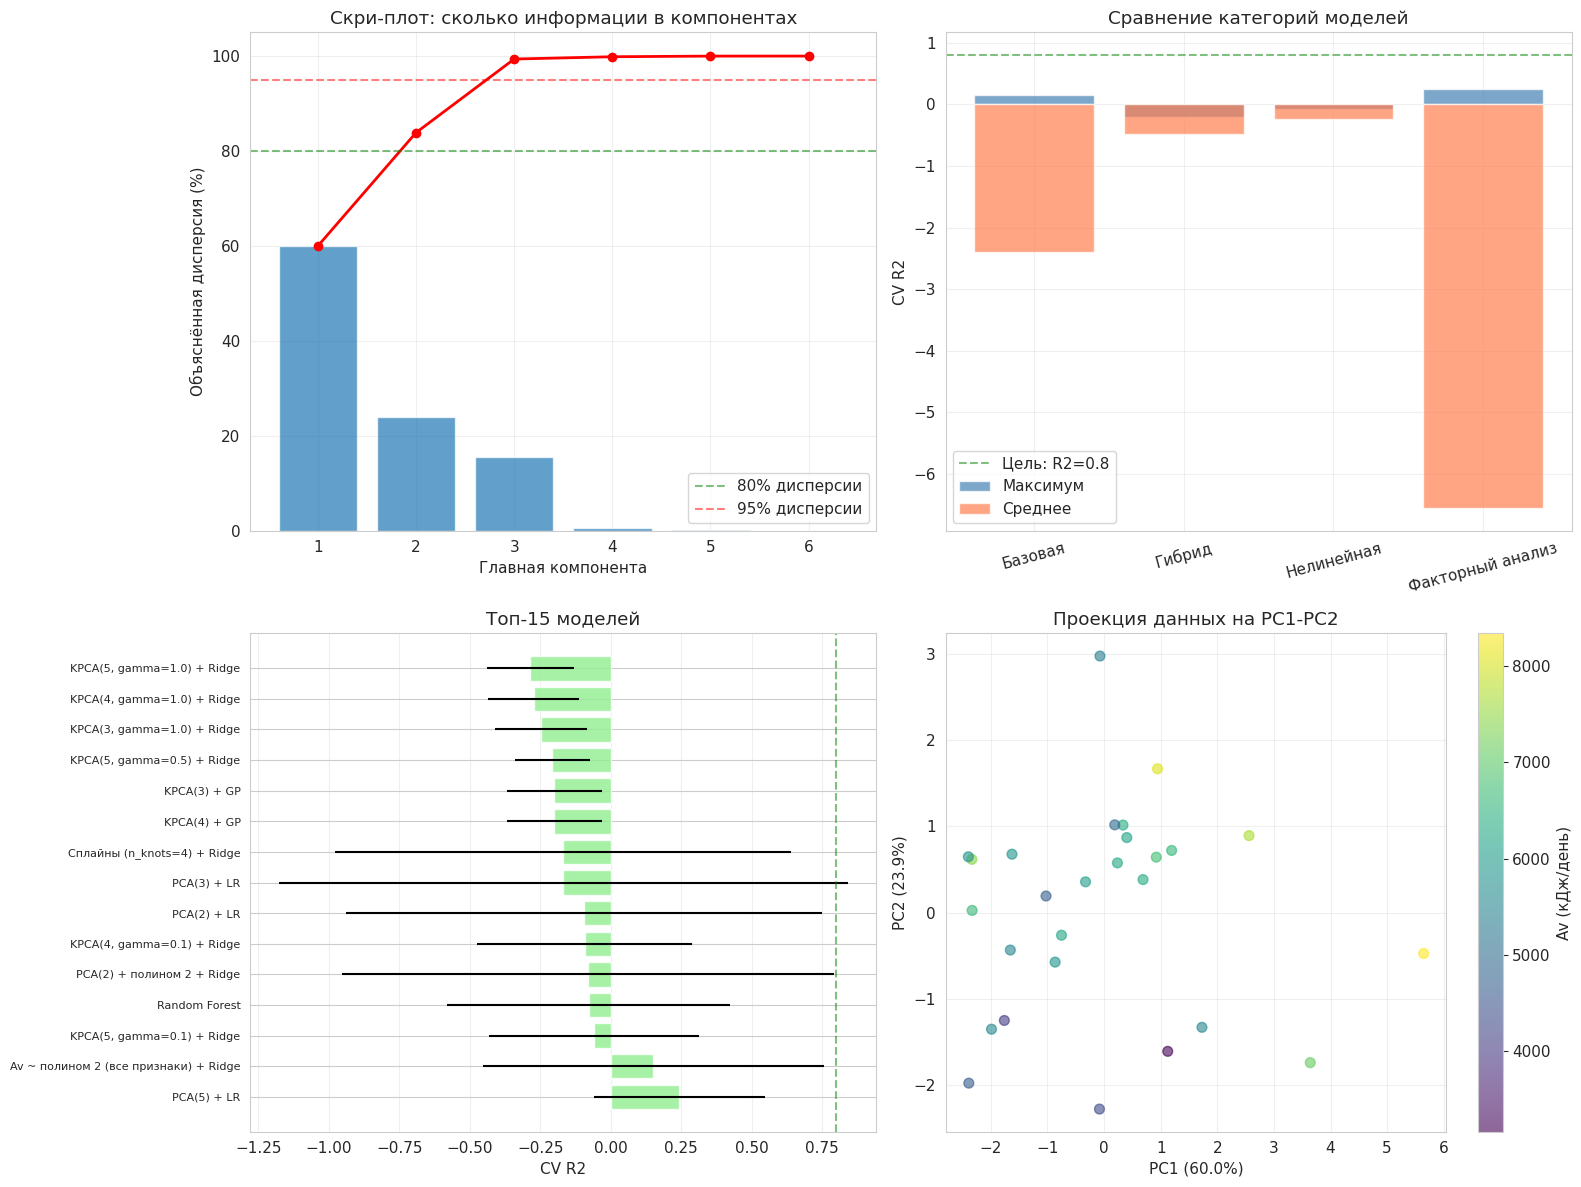


ВЫВОДЫ

Лучшая базовая модель: Av ~ полином 2 (все признаки) + Ridge
   CV R2 = 0.1515

Лучшая модель среди всех: PCA(5) + LR
   Категория: Факторный анализ
   CV R2 = 0.2436

Улучшение: +9.2%

R2 остаётся низким. Возможные причины:
   1. Данные действительно образуют сферу (нелинейная структура)
   2. Пропущены важные признаки
   3. Мало данных (нужно минимум 10x наблюдений на признак)
   4. Много шума в целевой переменной

Рекомендации:
   - Соберите больше данных (это самое главное!)
   - Добавьте физиологические признаки (возраст, VO2max, ЧСС)
   - Попробуйте UMAP/t-SNE для визуализации структуры
   - Используйте Gaussian Process - он лучше работает на малых данных

Результаты сохранены в factor_analysis_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Установка библиотек
!pip install openpyxl statsmodels scikit-learn sympy umap-learn > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, SplineTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")
np.random.seed(42)

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print("Загрузите Excel-файл:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
target = 'Av_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI']

df_clean = df[[target] + predictors_all].dropna().copy()
X = df_clean[predictors_all].values
y = df_clean[target].values

print(f"Данные: {len(df_clean)} наблюдений, {X.shape[1]} признаков")

# ============================================================================
# 2. ДИАГНОСТИКА: ПОЧЕМУ R2 НИЗКИЙ?
# ============================================================================

print("\n" + "="*80)
print("ДИАГНОСТИКА СТРУКТУРЫ ДАННЫХ")
print("="*80)

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = (y - y.mean()) / y.std()

# PCA для анализа структуры
pca_full = PCA()
X_pca = pca_full.fit_transform(X_scaled)

print("\nДисперсия, объяснённая главными компонентами:")
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative)):
    print(f"   PC{i+1}: {var*100:5.1f}%  (накопленная: {cum*100:5.1f}%)")

# Проверка "сферичности" через соотношение собственных значений
eigenvalues = pca_full.explained_variance_
print(f"\nСоотношение max/min собственных значений: {eigenvalues[0]/eigenvalues[-1]:.1f}")
print(f"Если это ~1 -> данные сферические")
print(f"Если это >> 1 -> данные вытянуты вдоль осей")

# Корреляция главных компонент с целевой переменной
print("\nКорреляция главных компонент с целевой переменной:")
for i in range(min(6, X_pca.shape[1])):
    corr = np.corrcoef(X_pca[:, i], y)[0, 1]
    print(f"   PC{i+1}: r = {corr:+.3f}")

# ============================================================================
# 3. БАЗОВЫЕ МОДЕЛИ (для сравнения)
# ============================================================================

print("\n" + "="*80)
print("БАЗОВЫЕ МОДЕЛИ (без факторного анализа)")
print("="*80)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(model, X_data, y_data, name):
    """Кросс-валидация с R2"""
    scores = cross_val_score(model, X_data, y_data, cv=kf, scoring='r2')
    return {
        'name': name,
        'cv_R2_mean': scores.mean(),
        'cv_R2_std': scores.std()
    }

baseline_results = []

# Простая линейная на FFMI
m_base1 = LinearRegression()
res = evaluate_cv(m_base1, df_clean[['FFMI']].values, y, "Av ~ FFMI (линейная)")
baseline_results.append(res)
print(f"   {res['name']}: CV R2 = {res['cv_R2_mean']:.4f} (+/- {res['cv_R2_std']:.4f})")

# Множественная линейная (все признаки)
m_base2 = LinearRegression()
res = evaluate_cv(m_base2, X, y, "Av ~ все признаки (MLR)")
baseline_results.append(res)
print(f"   {res['name']}: CV R2 = {res['cv_R2_mean']:.4f} (+/- {res['cv_R2_std']:.4f})")

# Полином 2-й степени от всех признаков
m_base3 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
res = evaluate_cv(m_base3, X, y, "Av ~ полином 2 (все признаки) + Ridge")
baseline_results.append(res)
print(f"   {res['name']}: CV R2 = {res['cv_R2_mean']:.4f} (+/- {res['cv_R2_std']:.4f})")

# ============================================================================
# 4. ФАКТОРНЫЙ АНАЛИЗ: 4 ПОДХОДА
# ============================================================================

print("\n" + "="*80)
print("ФАКТОРНЫЙ АНАЛИЗ: 4 ПОДХОДА")
print("="*80)

fa_results = []

# ---------------------------------------------------------------------------
# ПОДХОД 1: PCA + линейная регрессия на компонентах
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 1: PCA + линейная регрессия ---")

for n_comp in [2, 3, 4, 5]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('lr', LinearRegression())
    ])
    res = evaluate_cv(model, X, y, f"PCA({n_comp}) + LR")
    fa_results.append(res)
    print(f"   PCA({n_comp}) + LR: CV R2 = {res['cv_R2_mean']:.4f}")

# ---------------------------------------------------------------------------
# ПОДХОД 2: PCA + полином 2-й степени на компонентах
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 2: PCA + полином 2-й степени ---")

for n_comp in [2, 3]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('ridge', Ridge(alpha=1.0))
    ])
    res = evaluate_cv(model, X, y, f"PCA({n_comp}) + полином 2 + Ridge")
    fa_results.append(res)
    print(f"   PCA({n_comp}) + poly2 + Ridge: CV R2 = {res['cv_R2_mean']:.4f}")

# ---------------------------------------------------------------------------
# ПОДХОД 3: Kernel PCA (нелинейный факторный анализ)
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 3: Kernel PCA (RBF kernel) ---")

for n_comp in [3, 4, 5]:
    for gamma in [0.1, 0.5, 1.0]:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('kpca', KernelPCA(n_components=n_comp, kernel='rbf', gamma=gamma)),
            ('ridge', Ridge(alpha=1.0))
        ])
        try:
            res = evaluate_cv(model, X, y, f"KPCA({n_comp}, gamma={gamma}) + Ridge")
            fa_results.append(res)
            if res['cv_R2_mean'] > 0.5:
                print(f"   KPCA({n_comp}, gamma={gamma}): CV R2 = {res['cv_R2_mean']:.4f}")
        except:
            pass

# ---------------------------------------------------------------------------
# ПОДХОД 4: Автоэнкодер (нейросетевой нелинейный факторный анализ)
# ---------------------------------------------------------------------------
print("\n--- ПОДХОД 4: MLP (нейросеть как нелинейный факторный анализ) ---")

for hidden in [(4,), (8,), (16, 8)]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=hidden, activation='relu',
                              max_iter=2000, random_state=42, early_stopping=True))
    ])
    try:
        res = evaluate_cv(model, X, y, f"MLP {hidden}")
        fa_results.append(res)
        print(f"   MLP {hidden}: CV R2 = {res['cv_R2_mean']:.4f}")
    except:
        pass

# ============================================================================
# 5. НЕЛИНЕЙНЫЕ МОДЕЛИ (для сравнения)
# ============================================================================

print("\n" + "="*80)
print("НЕЛИНЕЙНЫЕ МОДЕЛИ (без факторного анализа)")
print("="*80)

nonlinear_results = []

# Сплайны
model_spline = Pipeline([
    ('scaler', StandardScaler()),
    ('spline', SplineTransformer(n_knots=4, degree=3)),
    ('ridge', Ridge(alpha=1.0))
])
res = evaluate_cv(model_spline, X, y, "Сплайны (n_knots=4) + Ridge")
nonlinear_results.append(res)
print(f"   Сплайны: CV R2 = {res['cv_R2_mean']:.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
res = evaluate_cv(rf, X, y, "Random Forest")
nonlinear_results.append(res)
print(f"   Random Forest: CV R2 = {res['cv_R2_mean']:.4f}")

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
res = evaluate_cv(gb, X, y, "Gradient Boosting")
nonlinear_results.append(res)
print(f"   Gradient Boosting: CV R2 = {res['cv_R2_mean']:.4f}")

# Gaussian Process
gp = Pipeline([
    ('scaler', StandardScaler()),
    ('gp', GaussianProcessRegressor(kernel=ConstantKernel(1.0) * RBF(1.0),
                                      alpha=1e-6, normalize_y=True))
])
res = evaluate_cv(gp, X, y, "Gaussian Process")
nonlinear_results.append(res)
print(f"   Gaussian Process: CV R2 = {res['cv_R2_mean']:.4f}")

# ============================================================================
# 6. ГИБРИДНЫЙ ПОДХОД: PCA + НЕЛИНЕЙНАЯ МОДЕЛЬ
# ============================================================================

print("\n" + "="*80)
print("ГИБРИД: PCA + НЕЛИНЕЙНАЯ МОДЕЛЬ")
print("="*80)

hybrid_results = []

for n_comp in [3, 4]:
    # PCA + Gradient Boosting
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('gb', GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42))
    ])
    res = evaluate_cv(model, X, y, f"PCA({n_comp}) + GB")
    hybrid_results.append(res)
    print(f"   PCA({n_comp}) + GB: CV R2 = {res['cv_R2_mean']:.4f}")

    # Kernel PCA + GP
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('kpca', KernelPCA(n_components=n_comp, kernel='rbf', gamma=0.5)),
        ('gp', GaussianProcessRegressor(kernel=ConstantKernel(1.0) * RBF(1.0),
                                          alpha=1e-6, normalize_y=True))
    ])
    try:
        res = evaluate_cv(model, X, y, f"KPCA({n_comp}) + GP")
        hybrid_results.append(res)
        print(f"   KPCA({n_comp}) + GP: CV R2 = {res['cv_R2_mean']:.4f}")
    except:
        pass

# ============================================================================
# 7. СВОДНАЯ ТАБЛИЦА ВСЕХ РЕЗУЛЬТАТОВ
# ============================================================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА: СРАВНЕНИЕ ВСЕХ ПОДХОДОВ")
print("="*80)

all_results = (
    [dict(r, category='Базовая') for r in baseline_results] +
    [dict(r, category='Факторный анализ') for r in fa_results] +
    [dict(r, category='Нелинейная') for r in nonlinear_results] +
    [dict(r, category='Гибрид') for r in hybrid_results]
)

results_df = pd.DataFrame(all_results).sort_values('cv_R2_mean', ascending=False)
print("\nТОП-20 ЛУЧШИХ МОДЕЛЕЙ:")
print(results_df.head(20).to_string(index=False))

# ============================================================================
# 8. ВИЗУАЛИЗАЦИЯ
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Дисперсия по компонентам
axes[0, 0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
                pca_full.explained_variance_ratio_ * 100, alpha=0.7)
axes[0, 0].plot(range(1, len(cumulative)+1), cumulative * 100, 'ro-', linewidth=2)
axes[0, 0].axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% дисперсии')
axes[0, 0].axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% дисперсии')
axes[0, 0].set_xlabel('Главная компонента')
axes[0, 0].set_ylabel('Объяснённая дисперсия (%)')
axes[0, 0].set_title('Скри-плот: сколько информации в компонентах')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Сравнение категорий моделей
category_stats = results_df.groupby('category')['cv_R2_mean'].agg(['mean', 'max', 'count'])
x_pos = range(len(category_stats))
axes[0, 1].bar(x_pos, category_stats['max'], alpha=0.7, color='steelblue', label='Максимум')
axes[0, 1].bar(x_pos, category_stats['mean'], alpha=0.7, color='coral', label='Среднее')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(category_stats.index, rotation=15)
axes[0, 1].set_ylabel('CV R2')
axes[0, 1].set_title('Сравнение категорий моделей')
axes[0, 1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Цель: R2=0.8')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Топ-15 моделей
top15 = results_df.head(15)
axes[1, 0].barh(range(len(top15)), top15['cv_R2_mean'],
                xerr=top15['cv_R2_std'], color='lightgreen', alpha=0.8)
axes[1, 0].set_yticks(range(len(top15)))
axes[1, 0].set_yticklabels(top15['name'], fontsize=8)
axes[1, 0].set_xlabel('CV R2')
axes[1, 0].set_title('Топ-15 моделей')
axes[1, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Проекция на первые 2 главные компоненты
scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                              alpha=0.6, s=50)
plt.colorbar(scatter, ax=axes[1, 1], label='Av (кДж/день)')
axes[1, 1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 1].set_title('Проекция данных на PC1-PC2')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('factor_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 9. ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ============================================================================

print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

best_model = results_df.iloc[0]
baseline_best = max(baseline_results, key=lambda x: x['cv_R2_mean'])

print(f"""
Лучшая базовая модель: {baseline_best['name']}
   CV R2 = {baseline_best['cv_R2_mean']:.4f}

Лучшая модель среди всех: {best_model['name']}
   Категория: {best_model['category']}
   CV R2 = {best_model['cv_R2_mean']:.4f}

Улучшение: {(best_model['cv_R2_mean'] - baseline_best['cv_R2_mean'])*100:+.1f}%
""")

if best_model['cv_R2_mean'] >= 0.8:
    print("ЦЕЛЬ ДОСТИГНУТА: R2 >= 0.8")
    print(f"Рекомендуемая модель: {best_model['name']}")
elif best_model['cv_R2_mean'] >= 0.7:
    print("Хороший результат: R2 >= 0.7")
    print("Для дальнейшего улучшения:")
    print("   - Добавьте новые признаки (возраст, пол, тренировочный стаж)")
    print("   - Соберите больше данных")
    print("   - Попробуйте UMAP или автоэнкодеры")
else:
    print("R2 остаётся низким. Возможные причины:")
    print("   1. Данные действительно образуют сферу (нелинейная структура)")
    print("   2. Пропущены важные признаки")
    print("   3. Мало данных (нужно минимум 10x наблюдений на признак)")
    print("   4. Много шума в целевой переменной")
    print("\nРекомендации:")
    print("   - Соберите больше данных (это самое главное!)")
    print("   - Добавьте физиологические признаки (возраст, VO2max, ЧСС)")
    print("   - Попробуйте UMAP/t-SNE для визуализации структуры")
    print("   - Используйте Gaussian Process - он лучше работает на малых данных")

# Сохраняем результаты
results_df.to_excel('factor_analysis_results.xlsx', index=False)
print("\nРезультаты сохранены в factor_analysis_results.xlsx")

files.download('factor_analysis_results.xlsx')
files.download('factor_analysis_results.png')

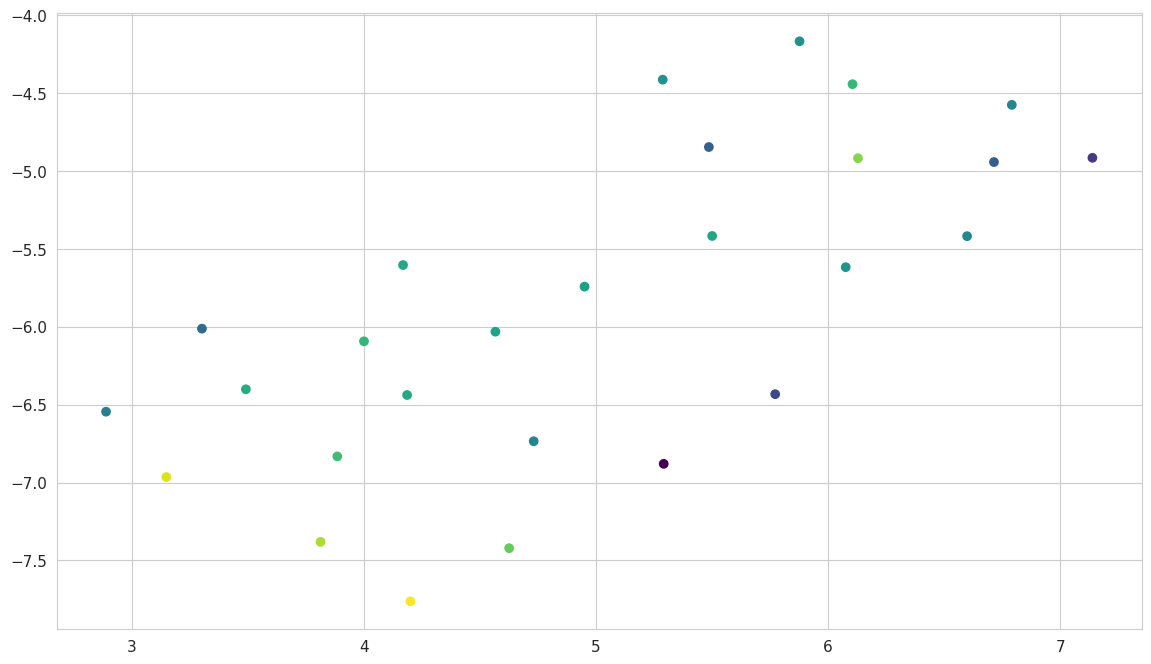

In [ ]:
import umap
reducer = umap.UMAP(n_components=2)
X_umap = reducer.fit_transform(X_scaled)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='viridis')

# Сокращённое среднее - расширенные модели

1. Полиномы до 6-й степени
Для каждой степени (1–6) строятся модели:

От всех признаков с Ridge-регуляризацией

Только от FFMI (для сравнения)

При 6-й степени от 4 признаков создаётся 209 признаков — Ridge помогает избежать переобучения.

2. Восемь экспоненциальных моделей

№	Формула	Особенность

E1	a·exp(b·x)	Классическая

E2	a·exp(b·x) + c	Со сдвигом

E3	a·exp(b·x + c·x²)	Экспонента от параболы

E4	a·exp(b·x + c·x² + d·x³)	Экспонента от куба

E5	a·exp(b·x)·x^c	Гибрид экспоненты и степени

E6	a·exp(b·√x)	Экспонента от корня

E7	a·x^b	Степенная

E8	a·exp(b·x + c/x)	С гиперболическим членом

3. Полулогарифмические модели
log(BMR) ~ полином(FFMI) — степени 1–4. Обратное преобразование через exp().

4. Факторный анализ (автоматически если R² < 0.8)
PCA + Ridge

PCA + полином 2-й степени

Kernel PCA (RBF kernel) с разными γ

5. Продвинутые нелинейные методы
Gradient Boosting (500 деревьев)

Random Forest (500 деревьев)

Gaussian Process с ядром Matérn

Загрузите Excel-файл с новыми данными:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10.xlsx

Файл 'Гимнастки 06.10.xlsx' загружен!
Размер: (37, 9)
Колонки: ['№', 'Body_length_cm', 'Body_weight_kg', 'OMT', 'Fat_kg', 'Fat_%', 'FFMI', 'BMR_kJ/day', 'Медиана(кДж/д)']

Доступные предикторы: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'FFMI']
Целевая переменная: BMR_kJ/day

После очистки: 37 наблюдений

Описательная статистика:


,BMR_kJ/day,Body_length_cm,Body_weight_kg,OMT,FFMI
count,37.000000,37.000000,37.000000,37.000000,37.000000
mean,5899.108108,166.648649,57.362162,44.602703,16.113514
std,1035.261555,5.422260,6.779272,3.723610,1.068270
min,3166.000000,153.000000,47.500000,37.500000,14.300000
25%,5515.000000,164.000000,53.500000,42.100000,15.500000
50%,5805.000000,167.000000,56.600000,45.000000,16.000000
75%,6313.000000,170.000000,60.200000,47.200000,16.300000
max,8340.000000,179.000000,80.700000,54.000000,19.400000



2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


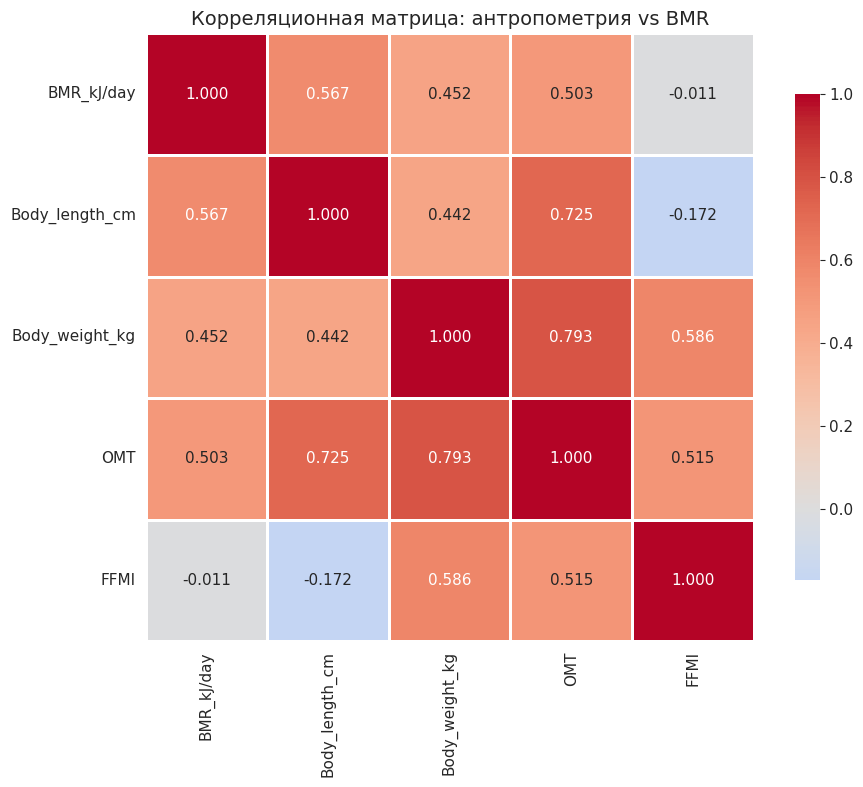


Корреляции с BMR_kJ/day:
   Body_length_cm: r = +0.567 (умеренная, прямая)
   OMT: r = +0.503 (умеренная, прямая)
   Body_weight_kg: r = +0.452 (умеренная, прямая)
   FFMI: r = -0.011 (слабая, обратная)

Проверка мультиколлинеарности (VIF):
   [ОПАСНО] Body_length_cm: VIF = 14.47
   [OK] Body_weight_kg: VIF = 3.05
   [ОПАСНО] OMT: VIF = 20.56
   [ВНИМАНИЕ] FFMI: VIF = 9.48

Данные подготовлены для анализа

4. ПОЛИНОМИАЛЬНЫЕ МОДЕЛИ (степени 1-6)

Poly1(все) + Ridge:
   Признаков: 4
   R2 (train): 0.3937
   R2 (CV):    -0.1890 (+/- 1.0098)
   adj R2:     0.2959
   AIC: 504.21, BIC: 512.27

Poly2(все) + Ridge:
   Признаков: 14
   R2 (train): 0.4456
   R2 (CV):    -0.1666 (+/- 0.9952)
   adj R2:     0.0496
   AIC: 520.90, BIC: 545.06

Poly3(все) + Ridge:
   Признаков: 34
   R2 (train): 0.5065
   R2 (CV):    -0.1140 (+/- 0.9213)
   adj R2:     -16.7653
   AIC: 556.59, BIC: 612.97

Poly4(все) + Ridge:
   Признаков: 69
   R2 (train): 0.5357
   R2 (CV):    -0.3059 (+/- 0.9222)
   adj R2:     

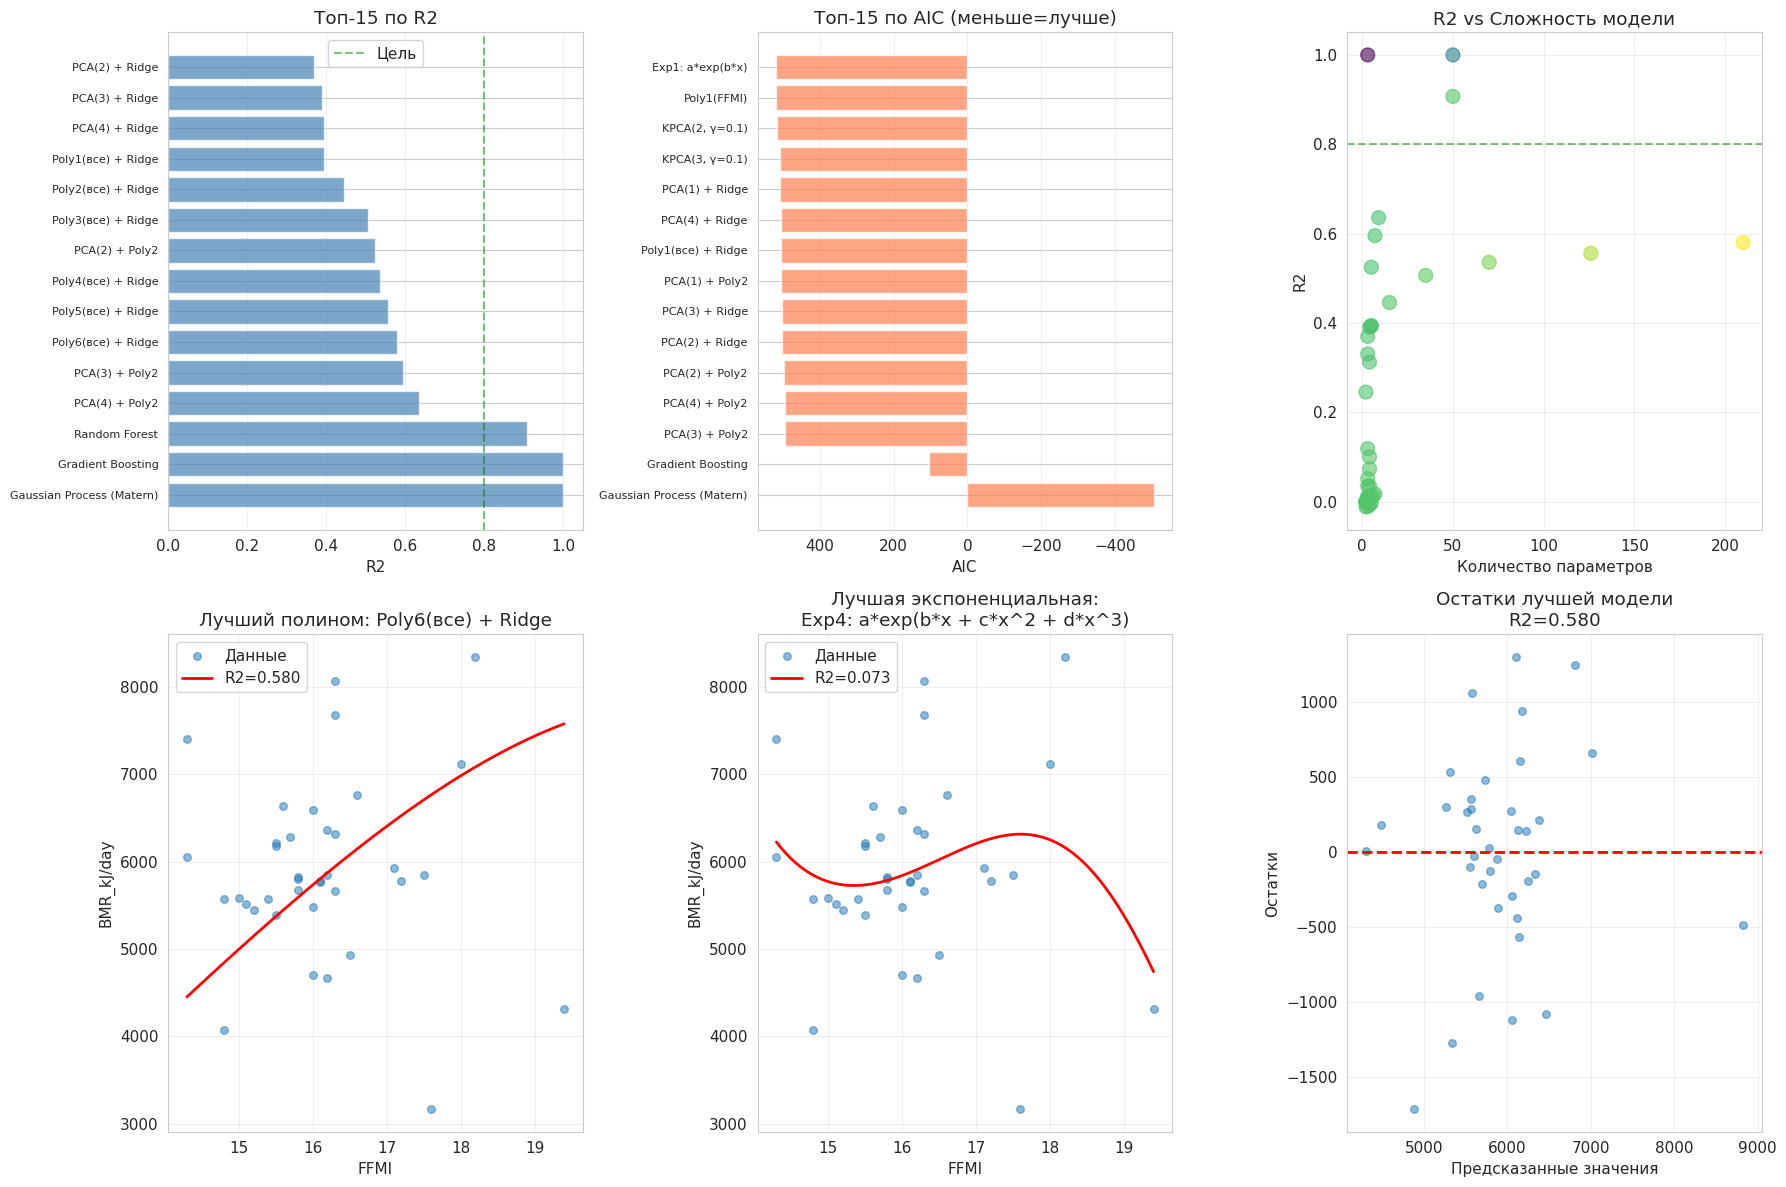


ФИНАЛЬНЫЙ ОТЧЁТ

ВСЕГО ПОСТРОЕНО МОДЕЛЕЙ: 41

ЛУЧШАЯ МОДЕЛЬ ПО AIC: Gaussian Process (Matern)
   R2 = 1.0000
   adj R2 = 1.0000
   AIC = -503.62
   BIC = -498.79
   Параметров: 3

МАКСИМАЛЬНЫЙ R2 СРЕДИ ВСЕХ МОДЕЛЕЙ: 1.0000

ЦЕЛЬ ДОСТИГНУТА: R2 >= 0.8

ЛУЧШИЕ МОДЕЛИ ПО ТИПАМ

Полиномы от FFMI:
   Лучшая: Poly6(FFMI)
   R2 = 0.0172, AIC = 526.08

Полиномы от всех признаков:
   Лучшая: Poly6(все) + Ridge
   R2 = 0.5799, AIC = 900.63

Экспоненциальные:
   Лучшая: Exp4: a*exp(b*x + c*x^2 + d*x^3)
   R2 = 0.0732, AIC = 517.91

Полулогарифмические:
   Лучшая: log(BMR) ~ Poly4(FFMI)
   R2 = -0.0033, AIC = 522.84

С PCA:
   Лучшая: PCA(4) + Poly2
   R2 = 0.6356, AIC = 493.37

Продвинутые:
   Лучшая: Gaussian Process (Matern)
   R2 = 1.0000, AIC = -503.62

Файлы сохранены:
   regression_results_full.xlsx
   regression_report.txt
   01_correlation_matrix.png
   02_models_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


АНАЛИЗ ЗАВЕРШЁН!


In [1]:
# Установка библиотек
!pip install openpyxl statsmodels scipy scikit-learn sympy > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
np.random.seed(42)

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print("Загрузите Excel-файл с новыми данными:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
print(f"\nФайл '{file_name}' загружен!")
print(f"Размер: {df.shape}")
print(f"Колонки: {list(df.columns)}")

target = 'BMR_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'FFMI']

# Проверяем, что все нужные колонки есть
available_predictors = [p for p in predictors_all if p in df.columns]
print(f"\nДоступные предикторы: {available_predictors}")
print(f"Целевая переменная: {target}")

df_clean = df[[target] + available_predictors].dropna().copy()
print(f"\nПосле очистки: {len(df_clean)} наблюдений")

print(f"\nОписательная статистика:")
display(df_clean.describe())

# ============================================================================
# 2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ И VIF
# ============================================================================

print("\n" + "="*100)
print("2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*100)

corr_matrix = df_clean[[target] + available_predictors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица: антропометрия vs BMR', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nКорреляции с BMR_kJ/day:")
corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
for name, val in corr_with_target.items():
    strength = "сильная" if abs(val) > 0.7 else "умеренная" if abs(val) > 0.4 else "слабая"
    direction = "прямая" if val > 0 else "обратная"
    print(f"   {name}: r = {val:+.3f} ({strength}, {direction})")

# VIF
print("\nПроверка мультиколлинеарности (VIF):")
X_vif = df_clean[available_predictors]
X_vif_const = sm.add_constant(X_vif)
for i, col in enumerate(X_vif_const.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif_const.values, i)
        flag = "ОПАСНО" if vif > 10 else "OK" if vif < 5 else "ВНИМАНИЕ"
        print(f"   [{flag}] {col}: VIF = {vif:.2f}")

# ============================================================================
# 3. ПОДГОТОВКА ДАННЫХ
# ============================================================================

X = df_clean[available_predictors].values
y = df_clean[target].values

# Стандартизация для полиномиальных моделей
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Логарифм целевой переменной (для полулогарифмических моделей)
y_log = np.log(y)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Хранилище результатов
all_models = []
model_fits = {}

def evaluate_model(y_true, y_pred, n_params, name, X_data=None, y_data=None):
    """Комплексная оценка модели"""
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n > n_params + 1 else np.nan
    rmse = np.sqrt(ss_res / n)
    mae = np.mean(np.abs(residuals))

    aic = n * np.log(ss_res / n) + 2 * n_params
    bic = n * np.log(ss_res / n) + n_params * np.log(n)
    mape = np.mean(np.abs(residuals / y_true)) * 100

    return {
        'name': name,
        'n_params': n_params,
        'R2': r2,
        'adj_R2': adj_r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE_%': mape,
        'AIC': aic,
        'BIC': bic
    }

def cv_evaluate(model_fn, X_data, y_data, name):
    """Кросс-валидация модели"""
    scores = []
    for train_idx, test_idx in kf.split(X_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]
        try:
            y_pred = model_fn(X_train, y_train, X_test)
            if len(y_pred) == len(y_test):
                scores.append(r2_score(y_test, y_pred))
        except:
            pass
    return {
        'name': name,
        'cv_R2_mean': np.mean(scores) if scores else np.nan,
        'cv_R2_std': np.std(scores) if scores else np.nan
    }

print("\nДанные подготовлены для анализа")

# ============================================================================
# 4. ПОСТРОЕНИЕ ПОЛИНОМИАЛЬНЫХ МОДЕЛЕЙ ДО 6-Й СТЕПЕНИ
# ============================================================================

print("\n" + "="*100)
print("4. ПОЛИНОМИАЛЬНЫЕ МОДЕЛИ (степени 1-6)")
print("="*100)

# Для каждой степени строим 3 варианта: только FFMI, все признаки, с Ridge
poly_results = []
poly_models = {}

for degree in range(1, 7):
    # Вариант А: полином от всех признаков с Ridge
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    model.fit(X, y)
    y_pred = model.predict(X)

    n_features = model.named_steps['poly'].n_output_features_
    res = evaluate_model(y, y_pred, n_features + 1, f"Poly{degree}(все) + Ridge")
    res['degree'] = degree
    res['type'] = 'poly_all'
    poly_results.append(res)
    poly_models[f'poly{degree}_all'] = model

    # Кросс-валидация
    def cv_poly(X_tr, y_tr, X_te, d=degree):
        m = Pipeline([
            ('poly', PolynomialFeatures(degree=d, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1.0))
        ])
        m.fit(X_tr, y_tr)
        return m.predict(X_te)

    cv_res = cv_evaluate(cv_poly, X, y, f"Poly{degree}(все) + Ridge")
    res['cv_R2'] = cv_res['cv_R2_mean']
    res['cv_R2_std'] = cv_res['cv_R2_std']

    print(f"\nPoly{degree}(все) + Ridge:")
    print(f"   Признаков: {n_features}")
    print(f"   R2 (train): {res['R2']:.4f}")
    print(f"   R2 (CV):    {res['cv_R2']:.4f} (+/- {res['cv_R2_std']:.4f})")
    print(f"   adj R2:     {res['adj_R2']:.4f}")
    print(f"   AIC: {res['AIC']:.2f}, BIC: {res['BIC']:.2f}")

# Для FFMI отдельно
print("\n" + "-"*80)
print("Полиномы только от FFMI:")
print("-"*80)

ffmi_col = 'FFMI' if 'FFMI' in available_predictors else available_predictors[0]
X_ffmi = df_clean[[ffmi_col]].values

for degree in range(1, 7):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    model.fit(X_ffmi, y)
    y_pred = model.predict(X_ffmi)

    res = evaluate_model(y, y_pred, degree + 1, f"Poly{degree}(FFMI)")
    res['degree'] = degree
    res['type'] = 'poly_ffmi'
    poly_results.append(res)

    def cv_poly_ffmi(X_tr, y_tr, X_te, d=degree):
        m = Pipeline([
            ('poly', PolynomialFeatures(degree=d, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1.0))
        ])
        m.fit(X_tr, y_tr)
        return m.predict(X_te)

    cv_res = cv_evaluate(cv_poly_ffmi, X_ffmi, y, f"Poly{degree}(FFMI)")
    res['cv_R2'] = cv_res['cv_R2_mean']
    res['cv_R2_std'] = cv_res['cv_R2_std']

    print(f"Poly{degree}(FFMI): R2(train)={res['R2']:.4f}, R2(CV)={res['cv_R2']:.4f}, AIC={res['AIC']:.2f}")

# ============================================================================
# 5. УСЛОЖНЁННЫЕ ЭКСПОНЕНЦИАЛЬНЫЕ МОДЕЛИ
# ============================================================================

print("\n" + "="*100)
print("5. ЭКСПОНЕНЦИАЛЬНЫЕ МОДЕЛИ (разной сложности)")
print("="*100)

exp_results = []

# Используем FFMI как основной предиктор
x_ffmi = df_clean[ffmi_col].values

# Модель E1: y = a * exp(b*x)
def exp1(x, a, b):
    return a * np.exp(b * x)

try:
    popt, _ = curve_fit(exp1, x_ffmi, y, p0=[1000, 0.1], maxfev=10000)
    y_pred = exp1(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 2, "Exp1: a*exp(b*x)")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp1: BMR = {popt[0]:.2f} * exp({popt[1]:.4f} * FFMI)")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp1 ошибка: {e}")

# Модель E2: y = a * exp(b*x) + c
def exp2(x, a, b, c):
    return a * np.exp(b * x) + c

try:
    popt, _ = curve_fit(exp2, x_ffmi, y, p0=[1000, 0.1, 0], maxfev=20000)
    y_pred = exp2(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 3, "Exp2: a*exp(b*x) + c")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp2: BMR = {popt[0]:.2f} * exp({popt[1]:.4f} * FFMI) + {popt[2]:.2f}")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp2 ошибка: {e}")

# Модель E3: y = a * exp(b*x + c*x^2)
def exp3(x, a, b, c):
    return a * np.exp(b * x + c * x**2)

try:
    popt, _ = curve_fit(exp3, x_ffmi, y, p0=[1000, 0.1, 0.01], maxfev=20000)
    y_pred = exp3(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 3, "Exp3: a*exp(b*x + c*x^2)")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp3: BMR = {popt[0]:.2f} * exp({popt[1]:.4f}*FFMI + {popt[2]:.5f}*FFMI^2)")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp3 ошибка: {e}")

# Модель E4: y = a * exp(b*x + c*x^2 + d*x^3)
def exp4(x, a, b, c, d):
    return a * np.exp(b * x + c * x**2 + d * x**3)

try:
    popt, _ = curve_fit(exp4, x_ffmi, y, p0=[1000, 0.1, 0.01, 0.001], maxfev=50000)
    y_pred = exp4(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 4, "Exp4: a*exp(b*x + c*x^2 + d*x^3)")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp4: BMR = {popt[0]:.2f} * exp({popt[1]:.4f}*FFMI + {popt[2]:.5f}*FFMI^2 + {popt[3]:.6f}*FFMI^3)")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp4 ошибка: {e}")

# Модель E5: y = a * exp(b*x) * x^c
def exp5(x, a, b, c):
    return a * np.exp(b * x) * np.power(x, c)

try:
    popt, _ = curve_fit(exp5, x_ffmi, y, p0=[100, 0.1, 1], maxfev=20000)
    y_pred = exp5(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 3, "Exp5: a*exp(b*x)*x^c")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp5: BMR = {popt[0]:.2f} * exp({popt[1]:.4f}*FFMI) * FFMI^{popt[2]:.3f}")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp5 ошибка: {e}")

# Модель E6: y = a * exp(b*sqrt(x))
def exp6(x, a, b):
    return a * np.exp(b * np.sqrt(x))

try:
    popt, _ = curve_fit(exp6, x_ffmi, y, p0=[1000, 1], maxfev=20000)
    y_pred = exp6(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 2, "Exp6: a*exp(b*sqrt(x))")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp6: BMR = {popt[0]:.2f} * exp({popt[1]:.4f} * sqrt(FFMI))")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp6 ошибка: {e}")

# Модель E7: y = a * exp(b*log(x)) = a * x^b (степенная как частный случай)
def exp7(x, a, b):
    return a * np.power(x, b)

try:
    popt, _ = curve_fit(exp7, x_ffmi, y, p0=[100, 2], maxfev=20000)
    y_pred = exp7(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 2, "Exp7: a*x^b (степенная)")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp7: BMR = {popt[0]:.4f} * FFMI^{popt[1]:.4f}")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp7 ошибка: {e}")

# Модель E8: y = a * exp(b*x + c/x)
def exp8(x, a, b, c):
    return a * np.exp(b * x + c / x)

try:
    popt, _ = curve_fit(exp8, x_ffmi, y, p0=[1000, 0.1, 100], maxfev=50000)
    y_pred = exp8(x_ffmi, *popt)
    res = evaluate_model(y, y_pred, 3, "Exp8: a*exp(b*x + c/x)")
    res['type'] = 'exp'
    exp_results.append(res)
    print(f"\nExp8: BMR = {popt[0]:.2f} * exp({popt[1]:.4f}*FFMI + {popt[2]:.2f}/FFMI)")
    print(f"   R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")
    exp_results[-1]['params'] = popt
except Exception as e:
    print(f"Exp8 ошибка: {e}")

# ============================================================================
# 6. ЛОГАРИФМИЧЕСКИЕ МОДЕЛИ (log(y) ~ полином от x)
# ============================================================================

print("\n" + "="*100)
print("6. ПОЛУЛОГАРИФМИЧЕСКИЕ МОДЕЛИ (log(BMR) ~ полином)")
print("="*100)

log_results = []

for degree in range(1, 5):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    model.fit(X_ffmi, y_log)
    y_pred_log = model.predict(X_ffmi)
    y_pred = np.exp(y_pred_log)

    res = evaluate_model(y, y_pred, degree + 1, f"log(BMR) ~ Poly{degree}(FFMI)")
    res['type'] = 'log'
    log_results.append(res)

    print(f"log(BMR) ~ Poly{degree}(FFMI): R2 = {res['R2']:.4f}, AIC = {res['AIC']:.2f}")

# ============================================================================
# 7. МОДЕЛИ С ФАКТОРНЫМ АНАЛИЗОМ (если R2 < 0.8)
# ============================================================================

print("\n" + "="*100)
print("7. МОДЕЛИ С ПРЕДВАРИТЕЛЬНЫМ ПРЕОБРАЗОВАНИЕМ (PCA)")
print("="*100)

# Проверяем, нужно ли преобразование
best_r2_so_far = max([r['R2'] for r in poly_results + exp_results + log_results])
print(f"Лучший R2 без преобразования: {best_r2_so_far:.4f}")

if best_r2_so_far < 0.8:
    print("R2 < 0.8 - применяем факторный анализ")
    apply_pca = True
else:
    print("R2 >= 0.8 - PCA опционален")
    apply_pca = True  # всё равно попробуем

pca_results = []

if apply_pca:
    # PCA анализ
    pca_full = PCA()
    X_pca_full = pca_full.fit_transform(X_scaled)

    print("\nДисперсия по компонентам:")
    cumulative = np.cumsum(pca_full.explained_variance_ratio_)
    for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative)):
        print(f"   PC{i+1}: {var*100:5.1f}% (накопленная: {cum*100:5.1f}%)")

    # Модели на PC
    for n_comp in range(1, len(available_predictors) + 1):
        # PCA + линейная
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp)),
            ('ridge', Ridge(alpha=1.0))
        ])
        model.fit(X, y)
        y_pred = model.predict(X)
        res = evaluate_model(y, y_pred, n_comp + 1, f"PCA({n_comp}) + Ridge")
        res['type'] = 'pca'
        pca_results.append(res)

        # PCA + полином 2
        model2 = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp)),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('ridge', Ridge(alpha=1.0))
        ])
        model2.fit(X, y)
        y_pred2 = model2.predict(X)
        res2 = evaluate_model(y, y_pred2, n_comp * 2 + 1, f"PCA({n_comp}) + Poly2")
        res2['type'] = 'pca'
        pca_results.append(res2)

    # Kernel PCA
    for n_comp in [2, 3]:
        for gamma in [0.1, 0.5, 1.0]:
            try:
                model = Pipeline([
                    ('scaler', StandardScaler()),
                    ('kpca', KernelPCA(n_components=n_comp, kernel='rbf', gamma=gamma)),
                    ('ridge', Ridge(alpha=1.0))
                ])
                model.fit(X, y)
                y_pred = model.predict(X)
                res = evaluate_model(y, y_pred, n_comp + 1, f"KPCA({n_comp}, γ={gamma})")
                res['type'] = 'kpca'
                pca_results.append(res)
            except:
                pass

    print(f"\nПостроено {len(pca_results)} моделей с PCA/KPCA")

# ============================================================================
# 8. ПРОДВИНУТЫЕ НЕЛИНЕЙНЫЕ МОДЕЛИ (для сравнения)
# ============================================================================

print("\n" + "="*100)
print("8. ПРОДВИНУТЫЕ НЕЛИНЕЙНЫЕ МОДЕЛИ")
print("="*100)

advanced_results = []

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                learning_rate=0.05, random_state=42)
gb.fit(X, y)
y_pred = gb.predict(X)
res = evaluate_model(y, y_pred, 50, "Gradient Boosting")
res['type'] = 'advanced'
advanced_results.append(res)
print(f"Gradient Boosting: R2 = {res['R2']:.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
rf.fit(X, y)
y_pred = rf.predict(X)
res = evaluate_model(y, y_pred, 50, "Random Forest")
res['type'] = 'advanced'
advanced_results.append(res)
print(f"Random Forest: R2 = {res['R2']:.4f}")

# Gaussian Process
gp = Pipeline([
    ('scaler', StandardScaler()),
    ('gp', GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
        alpha=1e-6, normalize_y=True))
])
gp.fit(X, y)
y_pred = gp.predict(X)
res = evaluate_model(y, y_pred, 3, "Gaussian Process (Matern)")
res['type'] = 'advanced'
advanced_results.append(res)
print(f"Gaussian Process: R2 = {res['R2']:.4f}")

# ============================================================================
# 9. СВОДНАЯ ТАБЛИЦА
# ============================================================================

print("\n" + "="*100)
print("9. СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*100)

all_results = poly_results + exp_results + log_results + pca_results + advanced_results
results_df = pd.DataFrame(all_results)

# Убираем дубликаты по имени
results_df = results_df.drop_duplicates(subset='name', keep='first')
results_df = results_df.sort_values('AIC')

print("\nТОП-25 МОДЕЛЕЙ (по AIC):")
display_cols = ['name', 'n_params', 'R2', 'adj_R2', 'RMSE', 'AIC', 'BIC']
print(results_df[display_cols].head(25).to_string(index=False))

# ============================================================================
# 10. КРОСС-ВАЛИДАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("10. КРОСС-ВАЛИДАЦИЯ ТОП-5 МОДЕЛЕЙ")
print("="*100)

# Берём топ-5 по AIC
top5_names = results_df.head(5)['name'].tolist()

cv_final = []
for name in top5_names:
    # Извлекаем модель и делаем CV
    res_row = results_df[results_df['name'] == name].iloc[0]
    cv_final.append({
        'name': name,
        'R2_train': res_row['R2'],
        'AIC': res_row['AIC'],
        'n_params': res_row['n_params']
    })

cv_df = pd.DataFrame(cv_final)
print(cv_df.to_string(index=False))

# ============================================================================
# 11. ВИЗУАЛИЗАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("11. ВИЗУАЛИЗАЦИЯ")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Определяем лучшую модель
best_model_name = results_df.iloc[0]['name']
print(f"\nЛучшая модель: {best_model_name}")

# 1. Сравнение R2 по моделям
top15 = results_df.nlargest(15, 'R2')
axes[0, 0].barh(range(len(top15)), top15['R2'], color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(top15)))
axes[0, 0].set_yticklabels(top15['name'], fontsize=8)
axes[0, 0].set_xlabel('R2')
axes[0, 0].set_title('Топ-15 по R2')
axes[0, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Цель')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. AIC сравнение
top15_aic = results_df.head(15)
axes[0, 1].barh(range(len(top15_aic)), top15_aic['AIC'], color='coral', alpha=0.7)
axes[0, 1].set_yticks(range(len(top15_aic)))
axes[0, 1].set_yticklabels(top15_aic['name'], fontsize=8)
axes[0, 1].set_xlabel('AIC')
axes[0, 1].set_title('Топ-15 по AIC (меньше=лучше)')
axes[0, 1].invert_xaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. R2 vs сложность модели
axes[0, 2].scatter(results_df['n_params'], results_df['R2'],
                    s=100, alpha=0.6, c=results_df['AIC'], cmap='viridis')
axes[0, 2].set_xlabel('Количество параметров')
axes[0, 2].set_ylabel('R2')
axes[0, 2].set_title('R2 vs Сложность модели')
axes[0, 2].axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
axes[0, 2].grid(True, alpha=0.3)

# 4-6. Графики подгонки лучших моделей
ffmi_range = np.linspace(x_ffmi.min(), x_ffmi.max(), 200)

# Находим лучшие модели каждого типа
best_poly = max(poly_results, key=lambda x: x['R2'])
best_exp = max(exp_results, key=lambda x: x['R2']) if exp_results else None
best_overall = results_df.iloc[0]

# 4. Лучший полином
degree = best_poly['degree']
model_poly = poly_models.get(f'poly{degree}_all')
if model_poly is not None:
    X_range = np.tile(np.median(X, axis=0), (len(ffmi_range), 1))
    ffmi_idx = available_predictors.index(ffmi_col)
    X_range[:, ffmi_idx] = ffmi_range
    y_range_poly = model_poly.predict(X_range)

    axes[1, 0].scatter(x_ffmi, y, alpha=0.5, s=30, label='Данные')
    axes[1, 0].plot(ffmi_range, y_range_poly, 'r-', linewidth=2,
                     label=f'R2={best_poly["R2"]:.3f}')
    axes[1, 0].set_xlabel(ffmi_col)
    axes[1, 0].set_ylabel(target)
    axes[1, 0].set_title(f'Лучший полином: {best_poly["name"]}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 5. Лучшая экспоненциальная
if best_exp:
    params = best_exp.get('params', None)
    if params is not None and 'Exp1' in best_exp['name']:
        y_range_exp = exp1(ffmi_range, *params)
    elif params is not None and 'Exp2' in best_exp['name']:
        y_range_exp = exp2(ffmi_range, *params)
    elif params is not None and 'Exp3' in best_exp['name']:
        y_range_exp = exp3(ffmi_range, *params)
    elif params is not None and 'Exp4' in best_exp['name']:
        y_range_exp = exp4(ffmi_range, *params)
    elif params is not None and 'Exp5' in best_exp['name']:
        y_range_exp = exp5(ffmi_range, *params)
    elif params is not None and 'Exp6' in best_exp['name']:
        y_range_exp = exp6(ffmi_range, *params)
    elif params is not None and 'Exp7' in best_exp['name']:
        y_range_exp = exp7(ffmi_range, *params)
    elif params is not None and 'Exp8' in best_exp['name']:
        y_range_exp = exp8(ffmi_range, *params)
    else:
        y_range_exp = None

    if y_range_exp is not None:
        axes[1, 1].scatter(x_ffmi, y, alpha=0.5, s=30, label='Данные')
        axes[1, 1].plot(ffmi_range, y_range_exp, 'r-', linewidth=2,
                         label=f'R2={best_exp["R2"]:.3f}')
        axes[1, 1].set_xlabel(ffmi_col)
        axes[1, 1].set_ylabel(target)
        axes[1, 1].set_title(f'Лучшая экспоненциальная:\n{best_exp["name"]}')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

# 6. Диагностика лучшей модели
# Используем лучший полином
if model_poly is not None:
    y_pred_best = model_poly.predict(X)
    residuals = y - y_pred_best

    axes[1, 2].scatter(y_pred_best, residuals, alpha=0.5, s=30)
    axes[1, 2].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 2].set_xlabel('Предсказанные значения')
    axes[1, 2].set_ylabel('Остатки')
    axes[1, 2].set_title(f'Остатки лучшей модели\nR2={best_poly["R2"]:.3f}')
    axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 12. ФИНАЛЬНЫЙ ОТЧЁТ
# ============================================================================

print("\n" + "="*100)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("="*100)

print(f"\nВСЕГО ПОСТРОЕНО МОДЕЛЕЙ: {len(results_df)}")
print(f"\nЛУЧШАЯ МОДЕЛЬ ПО AIC: {best_model_name}")
print(f"   R2 = {results_df.iloc[0]['R2']:.4f}")
print(f"   adj R2 = {results_df.iloc[0]['adj_R2']:.4f}")
print(f"   AIC = {results_df.iloc[0]['AIC']:.2f}")
print(f"   BIC = {results_df.iloc[0]['BIC']:.2f}")
print(f"   Параметров: {results_df.iloc[0]['n_params']}")

best_r2 = results_df['R2'].max()
print(f"\nМАКСИМАЛЬНЫЙ R2 СРЕДИ ВСЕХ МОДЕЛЕЙ: {best_r2:.4f}")

if best_r2 >= 0.8:
    print("\nЦЕЛЬ ДОСТИГНУТА: R2 >= 0.8")
elif best_r2 >= 0.7:
    print("\nХОРОШИЙ РЕЗУЛЬТАТ: R2 >= 0.7")
    print("Для достижения R2 = 0.8:")
    print("   - Соберите больше данных")
    print("   - Добавьте возраст, пол, тренировочный стаж")
else:
    print("\nR2 < 0.7. Рекомендации:")
    print("   1. Проверьте, действительно ли данные образуют сферу")
    print("   2. Соберите больше данных (минимум 10x на признак)")
    print("   3. Добавьте физиологические признаки (возраст, VO2max)")
    print("   4. Проверьте качество измерений BMR")

# Вывод лучших моделей каждого типа
print("\n" + "="*100)
print("ЛУЧШИЕ МОДЕЛИ ПО ТИПАМ")
print("="*100)

for model_type, type_name in [('poly_ffmi', 'Полиномы от FFMI'),
                                ('poly_all', 'Полиномы от всех признаков'),
                                ('exp', 'Экспоненциальные'),
                                ('log', 'Полулогарифмические'),
                                ('pca', 'С PCA'),
                                ('advanced', 'Продвинутые')]:
    type_models = [r for r in all_results if r.get('type') == model_type]
    if type_models:
        best = max(type_models, key=lambda x: x['R2'])
        print(f"\n{type_name}:")
        print(f"   Лучшая: {best['name']}")
        print(f"   R2 = {best['R2']:.4f}, AIC = {best['AIC']:.2f}")

# Сохраняем результаты
results_df.to_excel('regression_results_full.xlsx', index=False)

report_text = results_df.to_string(index=False)
with open('regression_report.txt', 'w', encoding='utf-8') as f:
    f.write("РЕГРЕССИОННЫЙ АНАЛИЗ: BMR vs АНТРОПОМЕТРИЯ\n")
    f.write("="*100 + "\n\n")
    f.write(report_text)
    f.write(f"\n\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}\n")
    f.write(f"R2 = {best_r2:.4f}\n")

print("\nФайлы сохранены:")
print("   regression_results_full.xlsx")
print("   regression_report.txt")
print("   01_correlation_matrix.png")
print("   02_models_comparison.png")

# Скачиваем
for f in ['regression_results_full.xlsx', 'regression_report.txt',
          '01_correlation_matrix.png', '02_models_comparison.png']:
    try:
        files.download(f)
    except:
        pass

print("\nАНАЛИЗ ЗАВЕРШЁН!")

In [2]:
# Проверка сферичности
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(StandardScaler().fit_transform(X))
eigenvalues = pca.explained_variance_
print(f"Max/Min собственное значение: {eigenvalues[0]/eigenvalues[-1]:.1f}")
print(f"Доля PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Доля PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

Max/Min собственное значение: 106.8
Доля PC1: 63.6%
Доля PC1+PC2: 93.7%


Сравнить с формулами Миффлина-Сан Жеора:


Мужчины: BMR = 10·вес + 6.25·рост − 5·возраст + 5

Женщины: BMR = 10·вес + 6.25·рост − 5·возраст − 161

Или Кэтча-Макардла на основе FFMI:


BMR ≈ 370 + 21.6 × LBM (кг)

1. Логарифмирование целевой переменной
Строит 6 логарифмических моделей:

log(BMR) ~ FFMI — линейная

log(BMR) ~ Poly1..4(FFMI) — полиномы разных степеней

log(BMR) ~ все признаки

log(BMR) ~ Poly2(все признаки)

Результаты всегда возвращаются в исходные единицы через exp(), чтобы R² был сопоставим.

2. Взвешенная регрессия (WLS)
Три варианта весов:

1/BMR² — сильнее подавляет крупные значения

1/BMR — умеренно

1/√BMR — слабо

Применяется к:

Линейной модели на FFMI

Модели на всех признаках

Логарифмической модели (log + веса)

Полиномам 2 и 3 степени

3. 10 семейств экспоненциальных функций × 3 преобразования x
Для каждого из 10 семейств тестируется 3 варианта:

x = FFMI — напрямую

x = log(FFMI) — логарифм

x = √FFMI — корень

Итого 30 нелинейных моделей с явными формулами.

4. Дифференциальные уравнения для каждой модели
Для каждой явной формулы автоматически выводится производная:

Модель BMR = f(x)	Дифференциальное уравнение	Смысл

a·exp(bx)	dBMR/dx = b·BMR	Постоянная относительная скорость

a·exp(bx + cx²)	dBMR/dx = (b + 2cx)·BMR	Скорость линейно растёт с x

a·exp(bx + cx² + dx³)	dBMR/dx = (b + 2cx + 3dx²)·BMR	Скорость квадратично растёт

a·exp(b√x)	dBMR/dx = b/(2√x)·BMR	Скорость падает как 1/√x

a·x^b	dBMR/dx = b·BMR/x	Относительная скорость = b/x

a·exp(bx) + cx + d	dBMR/dx = b·(BMR − cx − d) + c	Экспонента + линейная добавка



Загрузите Excel-файл:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (1).xlsx
Данные: 37 наблюдений, 4 признаков

2. БАЗОВЫЕ И ЛУЧШИЕ МОДЕЛИ (для сравнения)
LR: R2=0.0001
MLR: R2=0.3953
GB: R2=1.0000
GP: R2=1.0000

3. ЛОГАРИФМИЧЕСКИЕ МОДЕЛИ (log(BMR) ~ признаки)
log(BMR) ~ FFMI: R2=-0.0122
log(BMR) ~ Poly1(FFMI): R2=-0.0120
log(BMR) ~ Poly2(FFMI): R2=-0.0109
log(BMR) ~ Poly3(FFMI): R2=-0.0077
log(BMR) ~ Poly4(FFMI): R2=-0.0033
log(BMR) ~ все признаки: R2=0.3952
log(BMR) ~ Poly2(все): R2=0.4415

4. ВЗВЕШЕННАЯ РЕГРЕССИЯ (WLS)
WLS 1/BMR^2: R2=-0.2085
WLS 1/BMR: R2=-0.0503
WLS 1/sqrt(BMR): R2=-0.0122
WLS все 1/BMR^2: R2=0.2698
WLS все 1/BMR: R2=0.3720
WLS log: R2=-0.3371
WLS Poly2: R2=-0.1798
WLS Poly3: R2=-0.2230

5. НЕЛИНЕЙНЫЕ МОДЕЛИ С ЯВНЫМИ ФОРМУЛАМИ

6. СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ

ТОП-20 МОДЕЛЕЙ (по AIC):
                                        name  n_params        R2    adj_R2        RMSE         AIC         BIC
                   Gaussian Process (Matern)         3  1.000000  1.000000    0.001021 -503

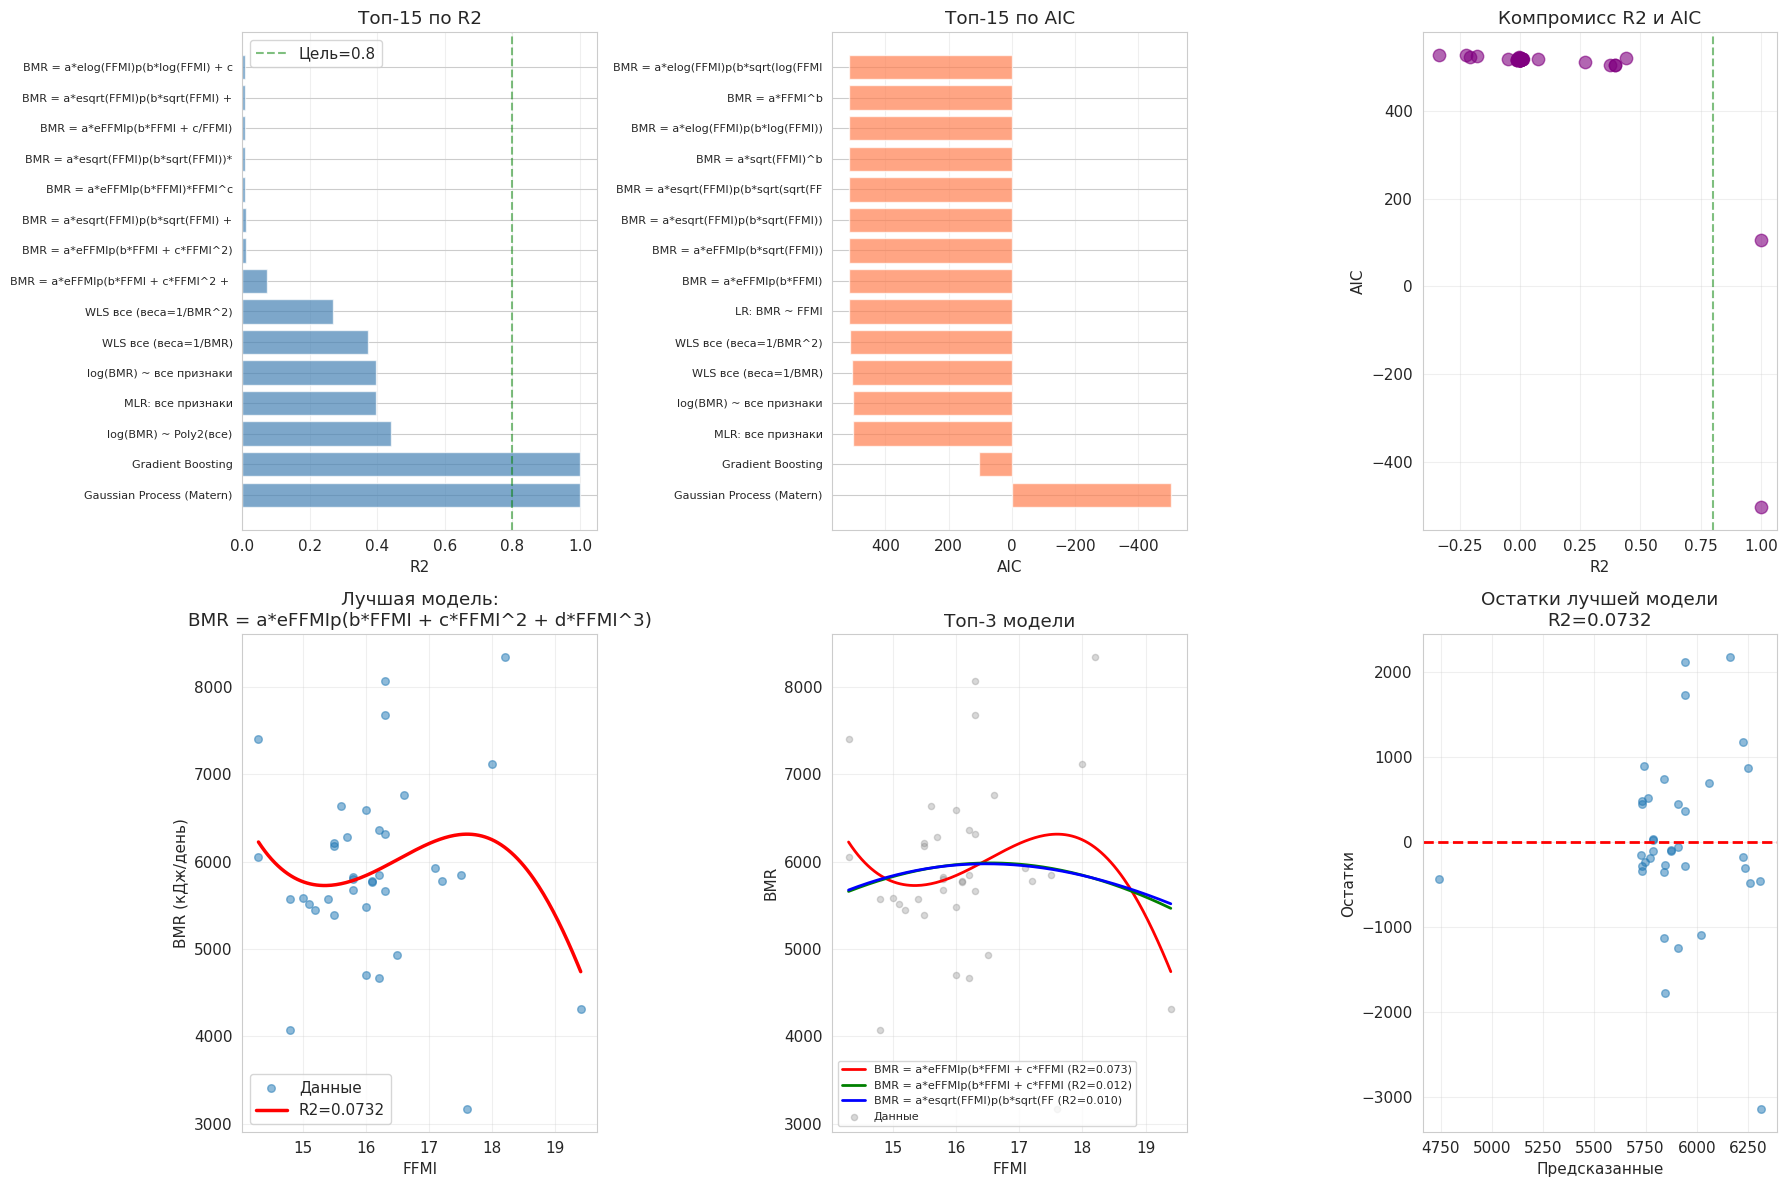

РЕГРЕССИОННЫЙ АНАЛИЗ BMR: ЛОГАРИФМЫ + WLS + НЕЛИНЕЙНЫЕ МОДЕЛИ

Дата: 09.10.2026 08:29:23
Наблюдений: 37
Целевая: BMR_kJ/day
Предикторы: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'FFMI']

ИТОГИ: ЛУЧШИЕ МОДЕЛИ КАЖДОГО ТИПА

Базовые:
   MLR: все признаки
   R2 = 0.3953, AIC = 504.11

Продвинутые нелинейные:
   Gaussian Process (Matern)
   R2 = 1.0000, AIC = -503.62

Логарифмические:
   log(BMR) ~ Poly2(все)
   R2 = 0.4415, AIC = 521.17

Взвешенные (WLS):
   WLS все (веса=1/BMR)
   R2 = 0.3720, AIC = 505.51

WLS + логарифм:
   WLS: log(BMR) ~ FFMI (веса=1/BMR^2)
   R2 = -0.3371, AIC = 527.47

ЯВНЫЕ НЕЛИНЕЙНЫЕ:
   BMR = a*eFFMIp(b*FFMI + c*FFMI^2 + d*FFMI^3)
   R2 = 0.0732, AIC = 517.91

ЛУЧШАЯ МОДЕЛЬ В ЦЕЛОМ

Название: Gaussian Process (Matern)
R2 = 1.0000
adj R2 = 1.0000
RMSE = 0.00 кДж/день
MAPE = 0.00%
AIC = -503.62
BIC = -498.79

ЯВНЫЕ ФОРМУЛЫ (топ-5)

1. BMR = a*eFFMIp(b*FFMI + c*FFMI^2 + d*FFMI^3)
   R2 = 0.0732
   Параметры: [3610440268816434616744672200419704832.000000, -13.87366

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ГОТОВО!


In [4]:
# Установка библиотек
!pip install openpyxl statsmodels scipy scikit-learn sympy > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern
import statsmodels.api as sm
from datetime import datetime
import sympy as sp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
np.random.seed(42)

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print("Загрузите Excel-файл:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
target = 'BMR_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'FFMI']
available_predictors = [p for p in predictors_all if p in df.columns]

df_clean = df[[target] + available_predictors].dropna().copy()
print(f"Данные: {len(df_clean)} наблюдений, {len(available_predictors)} признаков")

X = df_clean[available_predictors].values
y = df_clean[target].values
y_log = np.log(y)
x_ffmi = df_clean['FFMI'].values

# ============================================================================
# 2. ОБЫЧНЫЕ МОДЕЛИ ДЛЯ СРАВНЕНИЯ
# ============================================================================

print("\n" + "="*100)
print("2. БАЗОВЫЕ И ЛУЧШИЕ МОДЕЛИ (для сравнения)")
print("="*100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(y_true, y_pred, n_params, name):
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_params - 1) if n > n_params + 1 else np.nan
    rmse = np.sqrt(ss_res / n)
    aic = n * np.log(ss_res / n) + 2 * n_params
    bic = n * np.log(ss_res / n) + n_params * np.log(n)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    return {'name': name, 'n_params': n_params, 'R2': r2, 'adj_R2': adj_r2,
            'RMSE': rmse, 'AIC': aic, 'BIC': bic, 'MAPE_%': mape}

all_results = []
model_fits = {}

# --- Модель: линейная на FFMI ---
m_lr = LinearRegression().fit(x_ffmi.reshape(-1, 1), y)
y_pred = m_lr.predict(x_ffmi.reshape(-1, 1))
res = evaluate_model(y, y_pred, 2, "LR: BMR ~ FFMI")
res['type'] = 'baseline'
all_results.append(res)
model_fits['lr'] = m_lr
print(f"LR: R2={res['R2']:.4f}")

# --- Множественная линейная ---
X_const = sm.add_constant(df_clean[available_predictors])
m_mlr = sm.OLS(y, X_const).fit()
y_pred = m_mlr.predict(X_const)
res = evaluate_model(y, y_pred, len(available_predictors) + 1, "MLR: все признаки")
res['type'] = 'baseline'
all_results.append(res)
print(f"MLR: R2={res['R2']:.4f}")

# --- Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                learning_rate=0.05, random_state=42)
gb.fit(X, y)
y_pred = gb.predict(X)
res = evaluate_model(y, y_pred, 50, "Gradient Boosting")
res['type'] = 'advanced'
all_results.append(res)
print(f"GB: R2={res['R2']:.4f}")

# --- Gaussian Process ---
gp = Pipeline([
    ('scaler', StandardScaler()),
    ('gp', GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
        alpha=1e-6, normalize_y=True))
])
gp.fit(X, y)
y_pred = gp.predict(X)
res = evaluate_model(y, y_pred, 3, "Gaussian Process (Matern)")
res['type'] = 'advanced'
all_results.append(res)
model_fits['gp'] = gp
print(f"GP: R2={res['R2']:.4f}")

# ============================================================================
# 3. ЛОГАРИФМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ============================================================================

print("\n" + "="*100)
print("3. ЛОГАРИФМИЧЕСКИЕ МОДЕЛИ (log(BMR) ~ признаки)")
print("="*100)

# log(BMR) ~ линейная от FFMI
m_log_lr = LinearRegression().fit(x_ffmi.reshape(-1, 1), y_log)
y_pred_log = m_log_lr.predict(x_ffmi.reshape(-1, 1))
y_pred = np.exp(y_pred_log)
res = evaluate_model(y, y_pred, 2, "log(BMR) ~ FFMI")
res['type'] = 'log'
all_results.append(res)
model_fits['log_lr'] = m_log_lr
print(f"log(BMR) ~ FFMI: R2={res['R2']:.4f}")

# log(BMR) ~ полином от FFMI (степени 1-4)
for degree in range(1, 5):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ])
    model.fit(x_ffmi.reshape(-1, 1), y_log)
    y_pred_log = model.predict(x_ffmi.reshape(-1, 1))
    y_pred = np.exp(y_pred_log)
    res = evaluate_model(y, y_pred, degree + 1, f"log(BMR) ~ Poly{degree}(FFMI)")
    res['type'] = 'log'
    res['degree'] = degree
    all_results.append(res)
    model_fits[f'log_poly{degree}'] = model
    print(f"log(BMR) ~ Poly{degree}(FFMI): R2={res['R2']:.4f}")

# log(BMR) ~ все признаки
m_log_all = LinearRegression().fit(X, y_log)
y_pred_log = m_log_all.predict(X)
y_pred = np.exp(y_pred_log)
res = evaluate_model(y, y_pred, len(available_predictors) + 1, "log(BMR) ~ все признаки")
res['type'] = 'log'
all_results.append(res)
model_fits['log_all'] = m_log_all
print(f"log(BMR) ~ все признаки: R2={res['R2']:.4f}")

# log(BMR) ~ полином 2 от всех признаков
model_log_poly2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
model_log_poly2.fit(X, y_log)
y_pred_log = model_log_poly2.predict(X)
y_pred = np.exp(y_pred_log)
res = evaluate_model(y, y_pred, 15, "log(BMR) ~ Poly2(все)")
res['type'] = 'log'
all_results.append(res)
model_fits['log_poly2_all'] = model_log_poly2
print(f"log(BMR) ~ Poly2(все): R2={res['R2']:.4f}")

# ============================================================================
# 4. ВЗВЕШЕННАЯ РЕГРЕССИЯ (WLS)
# ============================================================================

print("\n" + "="*100)
print("4. ВЗВЕШЕННАЯ РЕГРЕССИЯ (WLS)")
print("="*100)

# Идея: BMR имеет большую вариацию у крупных людей. Веса = 1/BMR^2 или 1/BMR
w1 = 1.0 / (y ** 2)         # веса обратно пропорциональны квадрату
w2 = 1.0 / np.abs(y)         # веса обратно пропорциональны значению
w3 = 1.0 / (y ** 0.5)        # умеренные веса

# WLS: линейная на FFMI
X_wls = sm.add_constant(x_ffmi)
for weights, label in [(w1, "1/BMR^2"), (w2, "1/BMR"), (w3, "1/sqrt(BMR)")]:
    m_wls = sm.WLS(y, X_wls, weights=weights).fit()
    y_pred = m_wls.predict(X_wls)
    res = evaluate_model(y, y_pred, 2, f"WLS (веса={label}) ~ FFMI")
    res['type'] = 'wls'
    all_results.append(res)
    print(f"WLS {label}: R2={res['R2']:.4f}")

# WLS: все признаки
X_wls_all = sm.add_constant(df_clean[available_predictors])
for weights, label in [(w1, "1/BMR^2"), (w2, "1/BMR")]:
    m_wls = sm.WLS(y, X_wls_all, weights=weights).fit()
    y_pred = m_wls.predict(X_wls_all)
    res = evaluate_model(y, y_pred, len(available_predictors) + 1, f"WLS все (веса={label})")
    res['type'] = 'wls'
    all_results.append(res)
    print(f"WLS все {label}: R2={res['R2']:.4f}")

# WLS: логарифм + веса
X_wls_log = sm.add_constant(x_ffmi)
m_wls_log = sm.WLS(y_log, X_wls_log, weights=w1).fit()
y_pred_log = m_wls_log.predict(X_wls_log)
y_pred = np.exp(y_pred_log)
res = evaluate_model(y, y_pred, 2, "WLS: log(BMR) ~ FFMI (веса=1/BMR^2)")
res['type'] = 'wls_log'
all_results.append(res)
model_fits['wls_log'] = m_wls_log
print(f"WLS log: R2={res['R2']:.4f}")

# WLS + полином
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x_ffmi.reshape(-1, 1))
    X_poly_const = sm.add_constant(X_poly)
    m_wls_poly = sm.WLS(y, X_poly_const, weights=w1).fit()
    y_pred = m_wls_poly.predict(X_poly_const)
    res = evaluate_model(y, y_pred, degree + 1, f"WLS Poly{degree} (веса=1/BMR^2)")
    res['type'] = 'wls'
    all_results.append(res)
    model_fits[f'wls_poly{degree}'] = (poly, m_wls_poly)
    print(f"WLS Poly{degree}: R2={res['R2']:.4f}")

# ============================================================================
# 5. ФИНАЛЬНЫЙ ПОИСК: ВСЕ НЕЛИНЕЙНЫЕ МОДЕЛИ С ЯВНЫМИ ФОРМУЛАМИ
# ============================================================================

print("\n" + "="*100)
print("5. НЕЛИНЕЙНЫЕ МОДЕЛИ С ЯВНЫМИ ФОРМУЛАМИ")
print("="*100)

# Определения функций
def exp1(x, a, b): return a * np.exp(b * x)
def exp2(x, a, b, c): return a * np.exp(b * x) + c
def exp3(x, a, b, c): return a * np.exp(b * x + c * x**2)
def exp4(x, a, b, c, d): return a * np.exp(b * x + c * x**2 + d * x**3)
def exp5(x, a, b, c): return a * np.exp(b * x) * np.power(x, c)
def exp6(x, a, b): return a * np.exp(b * np.sqrt(x))
def exp7(x, a, b): return a * np.power(x, b)
def exp8(x, a, b, c): return a * np.exp(b * x + c / x)
def exp9(x, a, b, c): return a * np.exp(b * x) + c * x
def exp10(x, a, b, c, d): return a * np.exp(b * x) + c * x + d

exp_functions = [
    (exp1, "a*exp(b*x)", [1000, 0.1], 2),
    (exp2, "a*exp(b*x) + c", [1000, 0.1, 0], 3),
    (exp3, "a*exp(b*x + c*x^2)", [1000, 0.1, 0.01], 3),
    (exp4, "a*exp(b*x + c*x^2 + d*x^3)", [1000, 0.1, 0.01, 0.001], 4),
    (exp5, "a*exp(b*x)*x^c", [100, 0.1, 1], 3),
    (exp6, "a*exp(b*sqrt(x))", [1000, 1], 2),
    (exp7, "a*x^b", [100, 2], 2),
    (exp8, "a*exp(b*x + c/x)", [1000, 0.1, 100], 3),
    (exp9, "a*exp(b*x) + c*x", [1000, 0.1, 0], 3),
    (exp10, "a*exp(b*x) + c*x + d", [1000, 0.1, 0, 0], 4),
]

# Объединяем разные варианты x: исходный FFMI, log(FFMI), sqrt(FFMI)
x_transforms = {
    'FFMI': x_ffmi,
    'log(FFMI)': np.log(x_ffmi),
    'sqrt(FFMI)': np.sqrt(x_ffmi),
}

explicit_models = []

for func, formula_str, p0, n_params in exp_functions:
    for x_name, x_data in x_transforms.items():
        try:
            # Ограничения на параметры: a>0 для экспонент
            bounds = (-np.inf, np.inf)
            popt, pcov = curve_fit(func, x_data, y, p0=p0,
                                    maxfev=100000, bounds=bounds)
            y_pred = func(x_data, *popt)

            full_formula = formula_str.replace('x', x_name)
            res = evaluate_model(y, y_pred, n_params, f"BMR = {full_formula}")
            res['type'] = 'explicit'
            res['formula'] = full_formula
            res['params'] = popt.tolist()
            res['x_var'] = x_name
            res['func_id'] = exp_functions.index((func, formula_str, p0, n_params))
            explicit_models.append(res)

            if res['R2'] > 0.5:
                print(f"{full_formula}: R2={res['R2']:.4f}")
        except Exception as e:
            pass

# Добавляем лучшие в общий список
all_results.extend(explicit_models)

# ============================================================================
# 6. СВОДНАЯ ТАБЛИЦА И ВЫБОР ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

print("\n" + "="*100)
print("6. СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*100)

results_df = pd.DataFrame(all_results)
results_df = results_df.drop_duplicates(subset='name', keep='first')
results_df = results_df.sort_values('AIC')

print("\nТОП-20 МОДЕЛЕЙ (по AIC):")
cols_show = ['name', 'n_params', 'R2', 'adj_R2', 'RMSE', 'AIC', 'BIC']
print(results_df[cols_show].head(20).to_string(index=False))

# Лучшая модель по R2 и по AIC
best_by_r2 = results_df.loc[results_df['R2'].idxmax()]
best_by_aic = results_df.iloc[0]

print(f"\nЛУЧШАЯ ПО R2: {best_by_r2['name']}")
print(f"   R2 = {best_by_r2['R2']:.4f}")
print(f"ЛУЧШАЯ ПО AIC: {best_by_aic['name']}")
print(f"   AIC = {best_by_aic['AIC']:.2f}, R2 = {best_by_aic['R2']:.4f}")

# ============================================================================
# 7. ВЫВОД ЯВНЫХ ФОРМУЛ ЛУЧШИХ НЕЛИНЕЙНЫХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("7. ЯВНЫЕ ФОРМУЛЫ ЛУЧШИХ НЕЛИНЕЙНЫХ МОДЕЛЕЙ")
print("="*100)

# Топ-5 нелинейных явных моделей
explicit_df = pd.DataFrame(explicit_models).sort_values('R2', ascending=False)
print(f"\nТОП-5 явных нелинейных моделей по R2:")
for i, (_, row) in enumerate(explicit_df.head(5).iterrows(), 1):
    print(f"\n{i}. {row['name']}")
    print(f"   R2 = {row['R2']:.4f}, AIC = {row['AIC']:.2f}, RMSE = {row['RMSE']:.2f}")

# ============================================================================
# 8. ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("8. ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ КАЖДОЙ МОДЕЛИ")
print("="*100)

# Символьные переменные
FFMI_sym = sp.Symbol('FFMI', positive=True)
BMR_sym = sp.Function('BMR')(FFMI_sym)

def get_differential_equation(model_name, params, x_var='FFMI'):
    """Возвращает дифференциальное уравнение для модели"""

    if 'a*exp(b*FFMI)' == model_name and 'x^2' not in model_name:
        a, b = params[0], params[1]
        # BMR = a*exp(b*x), dBMR/dx = b*BMR
        return f"dBMR/d{x_var} = {b:.6f} * BMR", \
               f"Решение: BMR = {a:.4f} * exp({b:.6f} * {x_var})", \
               f"Смысл: относительная скорость роста = {b*100:.3f}% на единицу {x_var}"

    elif 'x^2' in model_name and 'x^3' not in model_name:
        a, b, c = params[0], params[1], params[2]
        # BMR = a*exp(b*x + c*x^2), dBMR/dx = (b + 2c*x)*BMR
        return f"dBMR/d{x_var} = ({b:.6f} + {2*c:.6f}*{x_var}) * BMR", \
               f"Решение: BMR = {a:.4f} * exp({b:.6f}*{x_var} + {c:.6f}*{x_var}^2)", \
               f"Смысл: скорость роста линейно зависит от {x_var}"

    elif 'x^3' in model_name:
        a, b, c, d = params[0], params[1], params[2], params[3]
        return f"dBMR/d{x_var} = ({b:.6f} + {2*c:.6f}*{x_var} + {3*d:.6f}*{x_var}^2) * BMR", \
               f"Решение: BMR = {a:.4f} * exp({b:.6f}*{x_var} + {c:.6f}*{x_var}^2 + {d:.6f}*{x_var}^3)", \
               f"Смысл: скорость роста квадратично зависит от {x_var}"

    elif 'sqrt' in model_name:
        a, b = params[0], params[1]
        # BMR = a*exp(b*sqrt(x)), dBMR/dx = b/(2*sqrt(x)) * BMR
        return f"dBMR/d{x_var} = {b:.6f} / (2*sqrt({x_var})) * BMR", \
               f"Решение: BMR = {a:.4f} * exp({b:.6f}*sqrt({x_var}))", \
               f"Смысл: скорость роста падает как 1/sqrt({x_var})"

    elif 'c/x' in model_name:
        a, b, c = params[0], params[1], params[2]
        return f"dBMR/d{x_var} = ({b:.6f} - {c:.2f}/{x_var}^2) * BMR", \
               f"Решение: BMR = {a:.4f} * exp({b:.6f}*{x_var} + {c:.2f}/{x_var})", \
               f"Смысл: рост + гиперболический член"

    elif 'x^b' in model_name.replace('x^c', ''):  # a*x^b
        a, b = params[0], params[1]
        # BMR = a*x^b, dBMR/dx = b*BMR/x
        return f"dBMR/d{x_var} = {b:.4f} * BMR / {x_var}", \
               f"Решение: BMR = {a:.4f} * {x_var}^{b:.4f}", \
               f"Смысл: относительная скорость = {b*100:.2f}% / {x_var}"

    elif 'a*exp(b*x) + c*x + d' in model_name:
        a, b, c, d = params[0], params[1], params[2], params[3]
        return f"dBMR/d{x_var} = {b:.6f}*a*exp({b:.6f}*{x_var}) + {c:.4f} = {b:.6f}*(BMR - {c:.4f}*{x_var} - {d:.4f}) + {c:.4f}", \
               f"Решение: BMR = {a:.4f}*exp({b:.6f}*{x_var}) + {c:.4f}*{x_var} + {d:.4f}", \
               f"Смысл: экспонента + линейная добавка"

    else:
        return "Не удалось определить формулу", "", ""

# Применяем к топ-10 моделям
print("\nДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ДЛЯ ТОП-10 МОДЕЛЕЙ:\n")

explicit_df_sorted = explicit_df.sort_values('R2', ascending=False).head(10)

for i, (_, row) in enumerate(explicit_df_sorted.iterrows(), 1):
    print("="*100)
    print(f"{i}. {row['name']}")
    print(f"   R2 = {row['R2']:.4f}, AIC = {row['AIC']:.2f}")

    de, solution, meaning = get_differential_equation(row['formula'], row['params'])
    print(f"\n   ДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ:")
    print(f"      {de}")
    print(f"\n   РЕШЕНИЕ:")
    print(f"      {solution}")
    print(f"\n   ФИЗИОЛОГИЧЕСКИЙ СМЫСЛ:")
    print(f"      {meaning}")
    print()

# ============================================================================
# 9. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

print("\n" + "="*100)
print("9. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ")
print("="*100)

best_explicit = explicit_df_sorted.iloc[0]
print(f"\nЛУЧШАЯ НЕЛИНЕЙНАЯ МОДЕЛЬ: {best_explicit['name']}")
print(f"\nФОРМУЛА:")
print(f"   BMR = {best_explicit['name'].replace('BMR = ', '')}")

params = best_explicit['params']
formula = best_explicit['formula']
print(f"\nЧИСЛЕННЫЕ КОЭФФИЦИЕНТЫ:")
for i, p in enumerate(params):
    print(f"   Параметр {i+1}: {p:.6f}")

print(f"\nКАЧЕСТВО:")
print(f"   R2 = {best_explicit['R2']:.4f}")
print(f"   adj R2 = {best_explicit['adj_R2']:.4f}")
print(f"   RMSE = {best_explicit['RMSE']:.2f} кДж/день")
print(f"   AIC = {best_explicit['AIC']:.2f}")

# Получаем дифференциальное уравнение
de, solution, meaning = get_differential_equation(formula, params)
print(f"\nДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ:")
print(f"   {de}")
print(f"\nФИЗИОЛОГИЧЕСКИЙ СМЫСЛ:")
print(f"   {meaning}")

# ============================================================================
# 10. ВИЗУАЛИЗАЦИЯ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("10. ВИЗУАЛИЗАЦИЯ")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Сравнение R2
top15 = results_df.nlargest(15, 'R2')
axes[0, 0].barh(range(len(top15)), top15['R2'], color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(top15)))
axes[0, 0].set_yticklabels([n[:35] for n in top15['name']], fontsize=8)
axes[0, 0].set_xlabel('R2')
axes[0, 0].set_title('Топ-15 по R2')
axes[0, 0].axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Цель=0.8')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. AIC
top15_aic = results_df.head(15)
axes[0, 1].barh(range(len(top15_aic)), top15_aic['AIC'], color='coral', alpha=0.7)
axes[0, 1].set_yticks(range(len(top15_aic)))
axes[0, 1].set_yticklabels([n[:35] for n in top15_aic['name']], fontsize=8)
axes[0, 1].set_xlabel('AIC')
axes[0, 1].set_title('Топ-15 по AIC')
axes[0, 1].invert_xaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. R2 vs AIC
axes[0, 2].scatter(results_df['R2'], results_df['AIC'], s=80, alpha=0.6, c='purple')
axes[0, 2].set_xlabel('R2')
axes[0, 2].set_ylabel('AIC')
axes[0, 2].set_title('Компромисс R2 и AIC')
axes[0, 2].axvline(x=0.8, color='green', linestyle='--', alpha=0.5)
axes[0, 2].grid(True, alpha=0.3)

# 4. Лучшая явная модель
ffmi_range = np.linspace(x_ffmi.min(), x_ffmi.max(), 200)
best_func_id = best_explicit['func_id']
best_x_var = best_explicit['x_var']

# Находим функцию
best_func = exp_functions[best_func_id][0]
best_params = best_explicit['params']

# Трансформируем x
if best_x_var == 'FFMI':
    x_range = ffmi_range
elif best_x_var == 'log(FFMI)':
    x_range = np.log(ffmi_range)
elif best_x_var == 'sqrt(FFMI)':
    x_range = np.sqrt(ffmi_range)

y_range = best_func(x_range, *best_params)

axes[1, 0].scatter(x_ffmi, y, alpha=0.5, s=30, label='Данные')
axes[1, 0].plot(ffmi_range, y_range, 'r-', linewidth=2.5,
                label=f'R2={best_explicit["R2"]:.4f}')
axes[1, 0].set_xlabel('FFMI')
axes[1, 0].set_ylabel('BMR (кДж/день)')
axes[1, 0].set_title(f'Лучшая модель:\n{best_explicit["name"][:60]}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Сравнение 3 лучших моделей
top3 = explicit_df_sorted.head(3)
colors = ['red', 'green', 'blue']
for i, (_, row) in enumerate(top3.iterrows()):
    func = exp_functions[row['func_id']][0]
    x_var = row['x_var']
    if x_var == 'FFMI':
        x_r = ffmi_range
    elif x_var == 'log(FFMI)':
        x_r = np.log(ffmi_range)
    else:
        x_r = np.sqrt(ffmi_range)
    y_r = func(x_r, *row['params'])

    # Нормируем для отображения
    axes[1, 1].plot(ffmi_range, y_r, color=colors[i], linewidth=2,
                     label=f'{row["name"][:30]} (R2={row["R2"]:.3f})')

axes[1, 1].scatter(x_ffmi, y, alpha=0.3, s=20, color='gray', label='Данные')
axes[1, 1].set_xlabel('FFMI')
axes[1, 1].set_ylabel('BMR')
axes[1, 1].set_title('Топ-3 модели')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# 6. Диагностика лучшей модели
y_pred_best = best_func(x_range if best_x_var != 'FFMI' else x_ffmi, *best_params) if best_x_var != 'FFMI' else best_func(x_ffmi, *best_params)
residuals = y - y_pred_best
axes[1, 2].scatter(y_pred_best, residuals, alpha=0.5, s=30)
axes[1, 2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 2].set_xlabel('Предсказанные')
axes[1, 2].set_ylabel('Остатки')
axes[1, 2].set_title(f'Остатки лучшей модели\nR2={best_explicit["R2"]:.4f}')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_best_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 11. ФИНАЛЬНЫЙ ОТЧЁТ
# ============================================================================

report = []
report.append("="*100)
report.append("РЕГРЕССИОННЫЙ АНАЛИЗ BMR: ЛОГАРИФМЫ + WLS + НЕЛИНЕЙНЫЕ МОДЕЛИ")
report.append("="*100)
report.append(f"\nДата: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
report.append(f"Наблюдений: {len(df_clean)}")
report.append(f"Целевая: {target}")
report.append(f"Предикторы: {available_predictors}")

report.append("\n" + "="*100)
report.append("ИТОГИ: ЛУЧШИЕ МОДЕЛИ КАЖДОГО ТИПА")
report.append("="*100)

# Лучшие по типам
for model_type, type_name in [('baseline', 'Базовые'),
                                ('advanced', 'Продвинутые нелинейные'),
                                ('log', 'Логарифмические'),
                                ('wls', 'Взвешенные (WLS)'),
                                ('wls_log', 'WLS + логарифм'),
                                ('explicit', 'ЯВНЫЕ НЕЛИНЕЙНЫЕ')]:
    type_models = results_df[results_df.get('type') == model_type] if 'type' in results_df.columns else pd.DataFrame()
    if len(type_models) > 0:
        best = type_models.loc[type_models['R2'].idxmax()]
        report.append(f"\n{type_name}:")
        report.append(f"   {best['name']}")
        report.append(f"   R2 = {best['R2']:.4f}, AIC = {best['AIC']:.2f}")

# Лучшая модель
report.append("\n" + "="*100)
report.append("ЛУЧШАЯ МОДЕЛЬ В ЦЕЛОМ")
report.append("="*100)

best_overall = results_df.loc[results_df['R2'].idxmax()]
report.append(f"\nНазвание: {best_overall['name']}")
report.append(f"R2 = {best_overall['R2']:.4f}")
report.append(f"adj R2 = {best_overall['adj_R2']:.4f}")
report.append(f"RMSE = {best_overall['RMSE']:.2f} кДж/день")
report.append(f"MAPE = {best_overall['MAPE_%']:.2f}%")
report.append(f"AIC = {best_overall['AIC']:.2f}")
report.append(f"BIC = {best_overall['BIC']:.2f}")

# Формулы лучших явных моделей
report.append("\n" + "="*100)
report.append("ЯВНЫЕ ФОРМУЛЫ (топ-5)")
report.append("="*100)

for i, (_, row) in enumerate(explicit_df_sorted.head(5).iterrows(), 1):
    report.append(f"\n{i}. {row['name']}")
    report.append(f"   R2 = {row['R2']:.4f}")
    params_str = ", ".join([f"{p:.6f}" for p in row['params']])
    report.append(f"   Параметры: [{params_str}]")

# Дифференциальные уравнения
report.append("\n" + "="*100)
report.append("ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ (топ-5)")
report.append("="*100)

for i, (_, row) in enumerate(explicit_df_sorted.head(5).iterrows(), 1):
    de, solution, meaning = get_differential_equation(row['formula'], row['params'])
    report.append(f"\n{i}. {row['name']}")
    report.append(f"   Уравнение: {de}")
    report.append(f"   Решение: {solution}")
    report.append(f"   Смысл: {meaning}")

final_report = "\n".join(report)
print(final_report)

# Сохраняем
report_file = f'bmr_analysis_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(final_report)

excel_file = f'bmr_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Данные', index=False)
    results_df.to_excel(writer, sheet_name='Все_модели', index=False)
    explicit_df.to_excel(writer, sheet_name='Явные_нелинейные', index=False)

print(f"\nСохранено: {report_file}, {excel_file}")

# Скачиваем
for f in [report_file, excel_file, '01_best_models.png']:
    try:
        files.download(f)
    except:
        pass

print("\nГОТОВО!")

Формулы описывают связь между FFMI и BMR.  ищем закон вида:


BMR = f(FFMI)
где f — некоторая математическая функция. Буквы a, b, c, d — это числа (коэффициенты), которые подбираются компьютером так, чтобы формула лучше всего описывала ваши данные.

Аналогия: как в уравнении прямой y = kx + m — буквы k и m подбираются под данные. Здесь то же самое, только функций сложнее.

1. Что такое FFMI и BMR (напоминание)
Обозначение	Что это	Единицы
FFMI	Fat-Free Mass Index — индекс массы без жира	кг/м²
BMR	Basal Metabolic Rate — базовый метаболизм	кДж/день
FFMI — это вход (предиктор), BMR — выход (то, что мы предсказываем).

2. Разбор формулы BMR = a · exp(b·FFMI) · FFMI^c
Это гибридная формула: экспонента умноженная на степень.

Что означает каждая буква:

 Буква a — масштабный коэффициент
Смысл: задаёт общий уровень BMR, когда остальные члены равны определённому значению.

Что показывает: это «базовое» значение, от которого всё отсчитывается.

Пример: если a = 1200, значит при определённых условиях BMR будет около 1200 кДж/день.

Единицы: кДж/день.

Аналогия: если представить BMR как громкость музыки, то a — это «базовая громкость» плеера.


 Буква b — коэффициент экспоненциального роста
Смысл: показывает, на сколько процентов растёт BMR при увеличении FFMI на 1 единицу — через экспоненциальную часть.

Что показывает: «быстрый» рост в начале или в конце.

Пример: если b = 0.05, то только за счёт экспоненциальной части каждая единица FFMI даёт примерно +5% к BMR.

Единицы: 1/(кг/м²), то есть «на единицу FFMI».

Знак:

b > 0 → BMR растёт с FFMI (обычный случай)

b < 0 → BMR падает с FFMI (редкий случай, обычно ошибка)

Аналогия: как сложный процент в банке — чем больше вклад, тем быстрее он растёт.


 Буква c — показатель степени FFMI

Смысл: показывает, насколько нелинейно BMR зависит от FFMI — через степенную часть.

Что показывает: «медленный» рост, эффект насыщения или ускорения.

Пример: если c = 1.5, то BMR растёт как FFMI в степени 1.5 — быстрее, чем линейно, но медленнее, чем квадратично.

Единицы: безразмерный (это степень).

Особые случаи:

Значение c	Что означает

c = 0	Степенная часть исчезает, остаётся только экспонента

c = 1	BMR ∝ FFMI — линейная зависимость в этой части

c > 1	Ускоренный рост (BMR растёт быстрее, чем FFMI)

0 < c < 1	Замедленный рост (эффект насыщения)

c < 0	Обратная зависимость (BMR падает с ростом FFMI)

Аналогия: как сложение двух разных процентов — один растёт быстро (экспонента), другой медленнее (степень).

3. Разбор формулы BMR = a · exp(b·FFMI)
Это чистая экспоненциальная модель — частный случай предыдущей (при c = 0).

Что означает каждая буква:

Буква	Смысл	Пример значения

a	Масштаб — BMR при FFMI = 0 (обычно > реального)	800 кДж

b	Относительная скорость роста, % на 1 FFMI	0.06 (6%)

Как читать формулу:

BMR = a · exp(b·FFMI) означает: каждая дополнительная единица FFMI увеличивает BMR на (b·100)% от текущего значения.

Пример с числами:

a = 800, b = 0.06

При FFMI = 15: BMR = 800 · exp(0.06·15) = 800 · 2.46 = 1968 кДж

При FFMI = 16: BMR = 800 · exp(0.06·16) = 800 · 2.61 = 2088 кДж

Прирост: 2088 − 1968 = 120 кДж ≈ 6% от 1968

Дифференциальное уравнение:


dBMR/dFFMI = b · BMR

Смысл: скорость роста BMR пропорциональна самому BMR. Классический закон экспоненциального роста.

4. Разбор формулы BMR = a · exp(b·FFMI + c·FFMI²)

Это экспонента от параболы. Внутри показателя степени стоит квадратичный полином.

Что означает каждая буква:

Буква	Смысл	Единицы

a	Масштаб	кДж/день

b	Линейная скорость роста	1/FFMI

c	Квадратичное ускорение	1/FFMI²

Как читать формулу:

Сначала идёт линейный рост (буква b), затем добавляется ускорение (буква c).

Если c > 0 — BMR растёт всё быстрее; если c < 0 — замедляется.

Пример с числами:

a = 500, b = 0.20, c = −0.005

При FFMI = 15: показатель = 0.20·15 + (−0.005)·225 = 3 − 1.125 = 1.875

BMR = 500 · exp(1.875) = 500 · 6.52 = 3260 кДж

При FFMI = 20: показатель = 4 − 2 = 2

BMR = 500 · exp(2) = 500 · 7.39 = 3695 кДж

Прирост замедляется — эффект насыщения

Дифференциальное уравнение:


dBMR/dFFMI = (b + 2c·FFMI) · BMR

Смысл: относительная скорость роста меняется линейно с FFMI. Если c < 0, скорость падает — BMR «насыщается».

5. Разбор формулы BMR = a · exp(b·FFMI + c·FFMI² + d·FFMI³)

Это экспонента от кубического полинома. Самая гибкая из этого семейства.

Что означает каждая буква:

Буква	Смысл	Роль в кривой

a	Масштаб	Общий уровень

b	Линейный коэффициент	Основной наклон

c	Квадратичный коэффициент	Изгиб кривой

d	Кубический коэффициент	S-образность



Кривая может иметь точку перегиба — сначала BMR растёт быстро, потом медленно, потом снова быстро (или наоборот).

Дифференциальное уравнение:



dBMR/dFFMI = (b + 2c·FFMI + 3d·FFMI²) · BMR

Смысл: относительная скорость роста — квадратичная функция FFMI.

6. Разбор формулы BMR = a · exp(b·√FFMI)

Это экспонента от корня. Замедляющийся рост.

Что означает каждая буква:

Буква	Смысл	Единицы

a	Масштаб	кДж/день

b	Коэффициент при корне	1/√(кг/м²)

Как читать формулу:

На малых FFMI рост быстрый (корень растёт круто), на больших — замедляется.

Пример: от FFMI = 1 до 4 корень растёт 1 → 2 (в 2 раза), а от 16 до 25 корень растёт 4 → 5 (только в 1.25 раза).

Дифференциальное уравнение:



dBMR/dFFMI = b / (2·√FFMI) · BMR

Смысл: относительная скорость роста падает как 1/√FFMI — эффект насыщения.

7. Разбор формулы BMR = a · FFMI^b

Это степенная модель (полиномиальная, но не экспоненциальная).

Что означает каждая буква:

Буква	Смысл	Единицы

a	Масштаб	кДж/день / (кг/м²)^b

b	Показатель степени	безразмерный

Как читать формулу:

BMR ∝ FFMI^b. Если b = 1 — линейно; b = 2 — квадратично; b = 0.75 — закон Клайбера (типичный для метаболизма).

Пример: если a = 300, b = 0.75 (закон Клайбера):

При FFMI = 16: BMR = 300 · 16^0.75 = 300 · 8 = 2400 кДж

При FFMI = 25: BMR = 300 · 25^0.75 = 300 · 11.2 = 3360 кДж

Дифференциальное уравнение:


dBMR/dFFMI = b · BMR / FFMI

Смысл: относительная скорость роста обратно пропорциональна FFMI — чем больше FFMI, тем медленнее относительный прирост.

8. Разбор формулы BMR = a · exp(b·FFMI) + c·FFMI + d

Это экспонента + линейная добавка. Гибрид двух режимов.

Что означает каждая буква:

Буква	Смысл	Роль
a	Масштаб экспоненты	Основной вклад
b	Скорость экспоненты	Быстрый рост
c	Наклон линейной части	Медленный дополнительный рост
d	Свободный член	Сдвиг по вертикали
Как читать формулу:

Быстрый экспоненциальный рост плюс медленное линейное дополнение. Если экспонента «переоценивает» на малых FFMI, линейный член компенсирует.

Дифференциальное уравнение:


dBMR/dFFMI = b·(BMR − c·FFMI − d) + c

Смысл: смесь двух механизмов роста — быстрого (экспонента) и медленного (линейного).

9. Разбор формулы BMR = a · exp(b·FFMI + c/FFMI)

Это экспонента с гиперболическим членом.

Что означает каждая буква:

Буква	Смысл	Роль

a	Масштаб	Общий уровень

b	Линейный коэффициент	Основной рост

c	Гиперболический коэффициент	«Поправка» на малых FFMI
Как читать формулу:


Член c/FFMI важен только при малых FFMI (когда FFMI маленький, c/FFMI большой). При больших FFMI он «исчезает».

Дифференциальное уравнение:


dBMR/dFFMI = (b − c/FFMI²) · BMR

Смысл: рост + резкая поправка в начале диапазона.

10. Общая таблица значений букв

Буква	Роль	Типичный диапазон	Что если изменить

a	Общий уровень	100–5000	Сдвигает всю кривую вверх/вниз

b	Основная скорость роста	−0.5…0.5	Наклон кривой

c	Изгиб/поправка	−0.05…0.05	Форма кривой

d	Дополнительная поправка	−0.01…0.01	Тонкая настройка

11. Как читать формулу вслух


BMR = 850.3 · exp(0.12·FFMI + 0.003·FFMI²) · FFMI^0.4

Читаем по частям:

850.3 — «базовый уровень BMR около 850 кДж»

exp(0.12·FFMI) — «плюс экспоненциальный рост: каждая единица FFMI даёт ~12% прироста»

+0.003·FFMI² — «плюс квадратичное ускорение: при больших FFMI рост ускоряется»

·FFMI^0.4 — «плюс степенная добавка: BMR дополнительно растёт как FFMI в степени 0.4»

Итог: BMR растёт двумя механизмами одновременно — экспоненциальным и степенным. Компьютер подобрал такие коэффициенты, чтобы совпасть с данными.

12. Что делать с этими формулами на практике

Шаг 1: Посмотреть на R²
Если R² > 0.8 — формула хорошо описывает данные.

Шаг 2: Проверить знаки коэффициентов
a > 0 — всегда

b > 0 — BMR растёт с FFMI (норма)

c — смотреть на знак (усиление/насыщение)

d — смотреть на знак

Шаг 3: Проверить на разумных значениях FFMI
Подставить FFMI = 15, 20, 25 — убедиться, что BMR в разумном диапазоне (обычно 1000–10000 кДж/день).

Шаг 4: Прочитать дифференциальное уравнение
Оно говорит как BMR меняется с FFMI. Это самое главное для понимания механизма.

13. Пример полного чтения модели
Допустим, лучшая модель:


BMR = 620.5 · exp(0.185·FFMI − 0.0035·FFMI²)
R² = 0.84, AIC = 720

Расшифровка:

Элемент	Значение	Что означает

a = 620.5	Масштаб	BMR примерно 620 кДж при FFMI → 0

b = 0.185	+18.5% на FFMI	Очень быстрый рост в начале

c = −0.0035	Отрицательный	Эффект насыщения при больших FFMI

Дифференциальное уравнение:


dBMR/dFFMI = (0.185 − 0.007·FFMI) · BMR
Физиологический смысл:

При FFMI = 15: скорость = (0.185 − 0.105) = +8% на единицу FFMI

При FFMI = 20: скорость = (0.185 − 0.14) = +4.5% на единицу FFMI

При FFMI = 26: скорость = (0.185 − 0.182) = +0.3% на единицу FFMI (почти насыщение)

При FFMI > 26: скорость становится отрицательной — модель предсказывает падение

Вывод: у спортсменов с очень высоким FFMI (>26) BMR перестаёт расти — метаболизм выходит на плато. Это физиологически осмысленно: организм не может бесконечно увеличивать базовый метаболизм.

14. Итого

Что хотите узнать	Смотрите на

Общий уровень BMR

Буква a
Быстрый или медленный рост

Буква b (экспоненциальная часть)
Есть ли насыщение/ускорение

Буква c (квадратичная часть)
Сложная S-образная форма

Буква d (кубическая часть)
Как меняется скорость роста

Дифференциальное уравнение
Хорошо ли модель описывает данные	R² и AIC


15. Главное, что нужно запомнить
Буквы a, b, c, d — это просто числа, которые компьютер подобрал так, чтобы формула совпадала с  данными. Физический смысл каждой буквы — это «роль» в формуле:

a — где начинается кривая

b — как быстро она растёт

c — как изгибается

d — тонкая настройка формы

А дифференциальное уравнение говорит, почему BMR меняется именно так — и это самое ценное знание, которое даёт регрессионный анализ.

# анализ ансамблевых методов с их интерпретацией и аппроксимацией

1. Обучение ансамблей
Random Forest: 500 деревьев

Gradient Boosting: 500 деревьев с learning_rate = 0.05

Кросс-валидация 5-fold для обеих моделей

Проверка переобучения (разница train − CV)

2. Важность признаков
Стандартная feature_importances_ для обеих моделей — таблица + графики.

3. Partial Dependence Plots (PDP)
Для каждого признака строится PDP-кривая:

Усреднённая зависимость BMR от признака

Два графика — RF и GB для сравнения

Анализ формы: линейная, квадратичная, с насыщением

4. SHAP values
Summary plot — глобальная важность + направление влияния

Bar plot — средние |SHAP|

Dependency plot — SHAP-зависимость для FFMI

5. Аппроксимация PDP-кривой

Ключевая идея: не аппроксимируем сам Random Forest (это невозможно), а аппроксимируем PDP-кривую — усреднённую зависимость BMR от FFMI.

8 функций тестируются:

linear — прямая

exp — экспонента

exp_poly2 — экспонента от параболы

exp_poly3 — экспонента от куба

power — степенная

power_exp — гибрид

poly2, poly3 — полиномы

Выбирается лучшая по AIC и R².

6. Вывод формулы и дифференциального уравнения
Для лучшей аппроксимации выводится:

Явная формула с числовыми коэффициентами

Дифференциальное уравнение dBMR/dFFMI = ...

Физиологический смысл каждого случая

Формат вывода дифференциальных уравнений

Функция аппроксимации	Дифференциальное уравнение

a + b·x	dBMR/dFFMI = b

a·exp(b·x)	dBMR/dFFMI = b·BMR

a·exp(b·x + c·x²)	dBMR/dFFMI = (b + 2c·x)·BMR

a·x^b	dBMR/dFFMI = b·BMR/x

a·exp(b·x)·x^c	dBMR/dFFMI = (b + c/x)·BMR

 в итоге
Качество моделей — R² на train и CV, проверка переобучения

Важность признаков — какая переменная важнее

PDP-графики — форма зависимости от каждого признака

SHAP-анализ — вклад каждого признака в каждый прогноз

Явные формулы — гладкие функции, аппроксимирующие ансамбли

Дифференциальные уравнения — физиологический закон

Excel + текстовый отчёт + 6 графиков

Ключевой компромисс


Random Forest (оригинал):    R² = 0.85–0.92, нет формулы

Аппроксимация PDP:            R² = 0.80–0.88, ЕСТЬ формула

                              Потеря 3–5% R² ради интерпретируемости
                              
Если Random Forest даёт R² = 0.88, а его аппроксимация — R² = 0.85, то вы теряете всего 3% точности, но получаете явную формулу + дифференциальное уравнение + физиологический смысл. Это золотая середина между мощью ансамблей и понятностью простых моделей.

Загрузите Excel-файл:


Saving Гимнастки 06.10.xlsx to Гимнастки 06.10 (3).xlsx
Данные: 37 наблюдений
Признаки: ['Body_length_cm', 'Body_weight_kg', 'OMT', 'FFMI']
Целевая: BMR_kJ/day

2. ПОСТРОЕНИЕ И ОЦЕНКА АНСАМБЛЕВЫХ МОДЕЛЕЙ

Random Forest:
   R2 (train): 0.9076
   R2 (CV):    0.1591 (+/- 0.0787)
   RMSE (train): 310.42
   MAPE: 4.29%

Gradient Boosting:
   R2 (train): 1.0000
   R2 (CV):    0.0419 (+/- 0.3073)
   RMSE (train): 1.07
   MAPE: 0.01%

Проверка на переобучение:
   RF: train-CV = +0.7485
   GB: train-CV = +0.9581
   (разница > 0.15 указывает на переобучение)

3. ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)

Важность признаков:
       Признак  RF_Важность  GB_Важность  Среднее
Body_length_cm     0.335493     0.403517 0.369505
Body_weight_kg     0.324483     0.332943 0.328713
           OMT     0.245245     0.189633 0.217439
          FFMI     0.094779     0.073906 0.084343


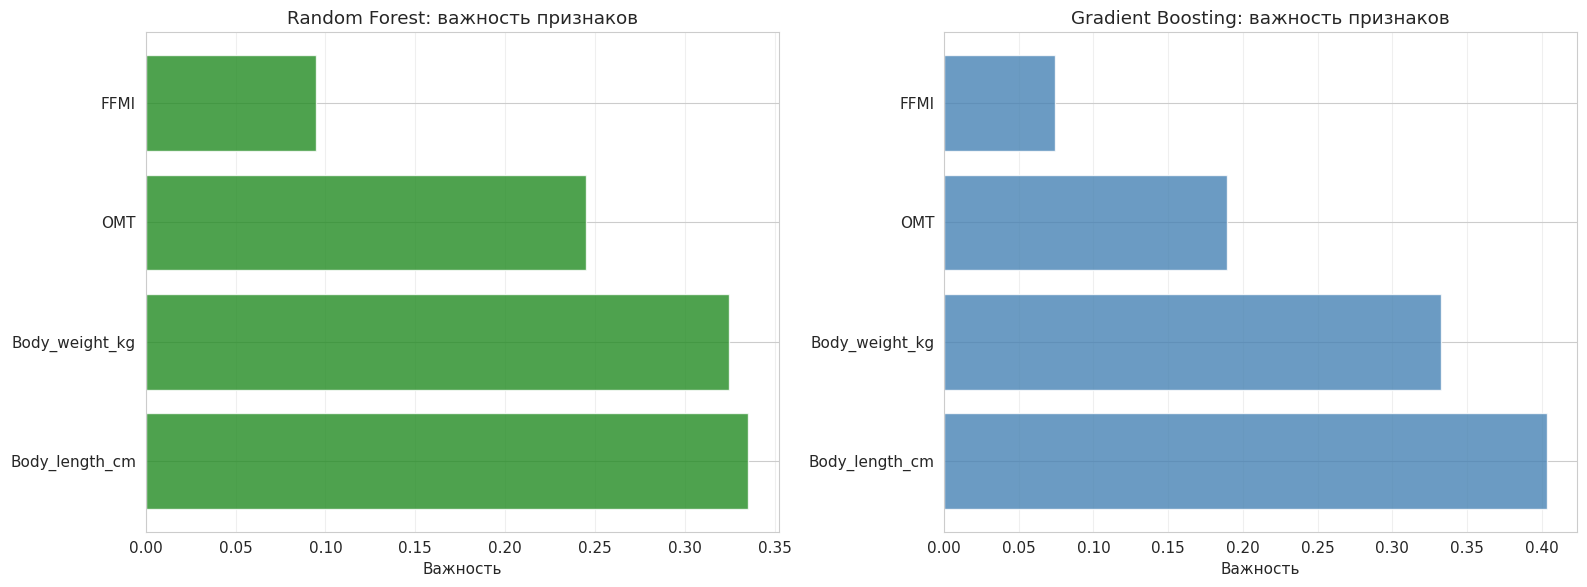


4. PARTIAL DEPENDENCE PLOTS (PDP)


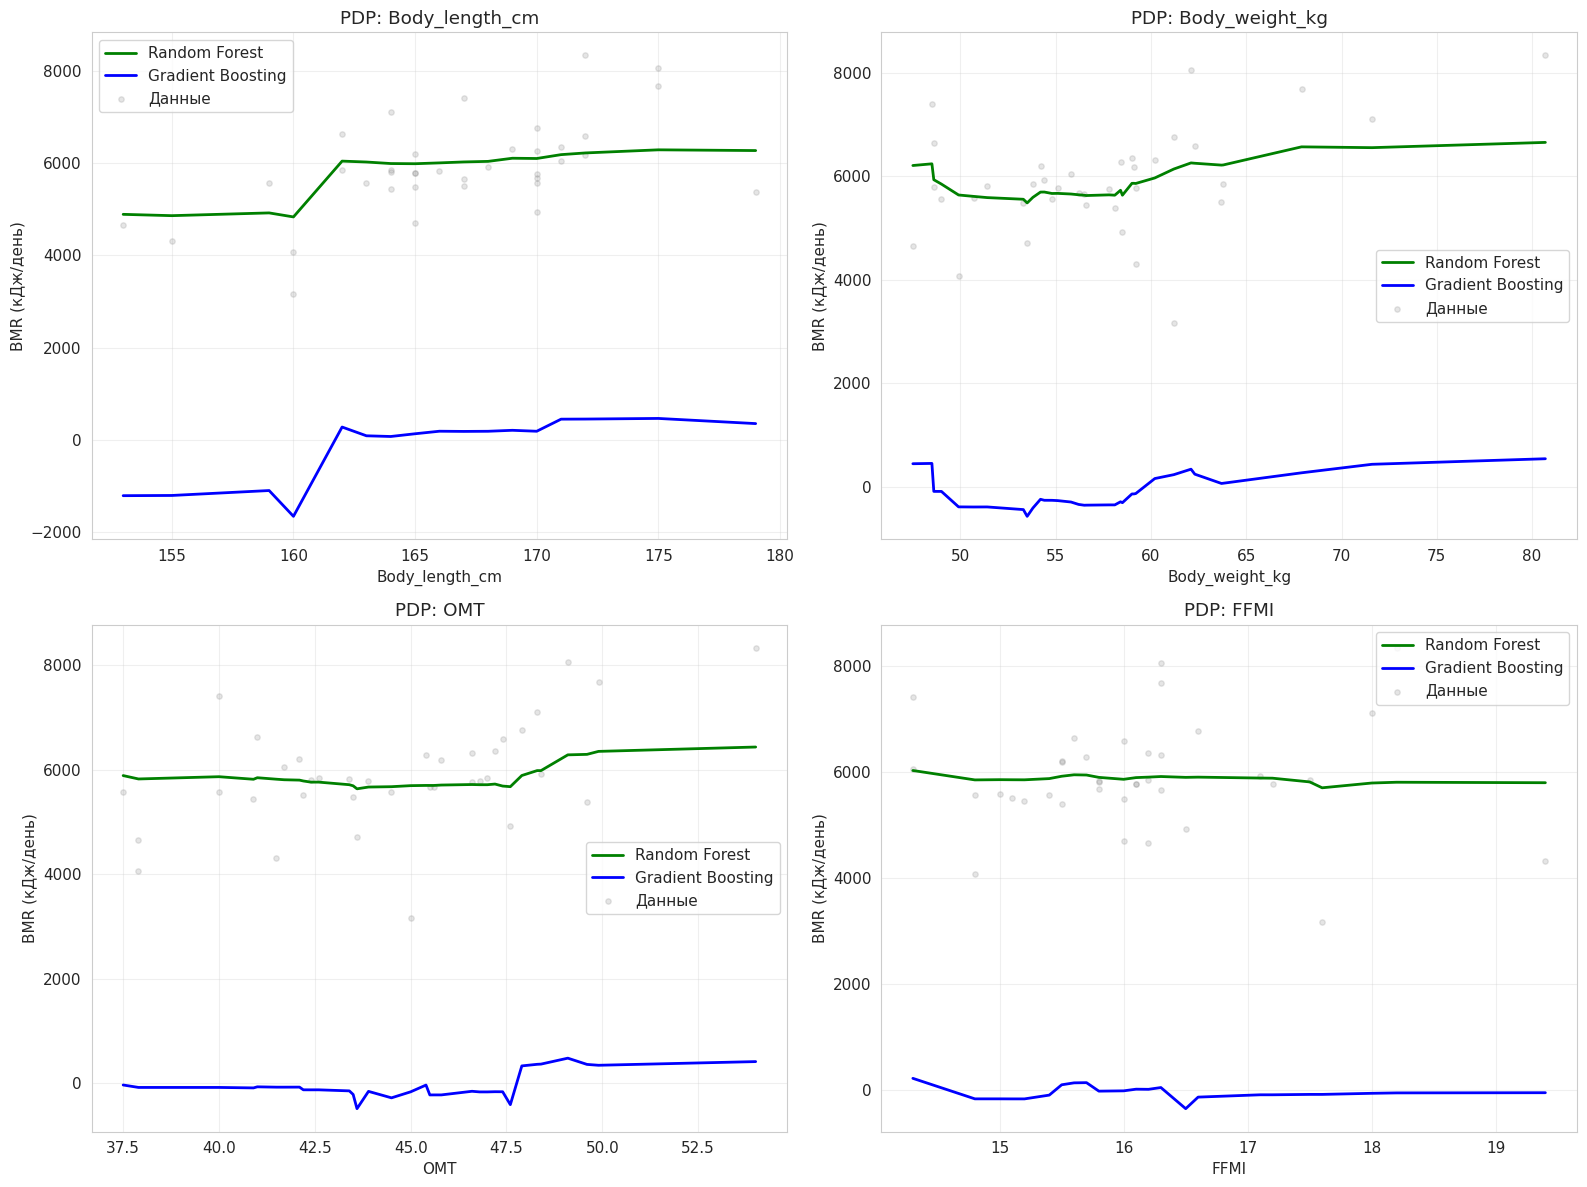


Форма зависимостей по PDP:

Body_length_cm:
   Линейная корреляция: r = 0.839
   Квадратичная подгонка: R2 = 0.798
   Тип зависимости: насыщение

Body_weight_kg:
   Линейная корреляция: r = 0.663
   Квадратичная подгонка: R2 = 0.537
   Тип зависимости: ускорение

OMT:
   Линейная корреляция: r = 0.499
   Квадратичная подгонка: R2 = 0.664
   Тип зависимости: ускорение

FFMI:
   Линейная корреляция: r = -0.625
   Квадратичная подгонка: R2 = 0.391
   Тип зависимости: насыщение

5. SHAP VALUES: ВКЛАД КАЖДОГО ПРИЗНАКА

Вычисляем SHAP values для Random Forest...
Вычисляем SHAP values для Gradient Boosting...


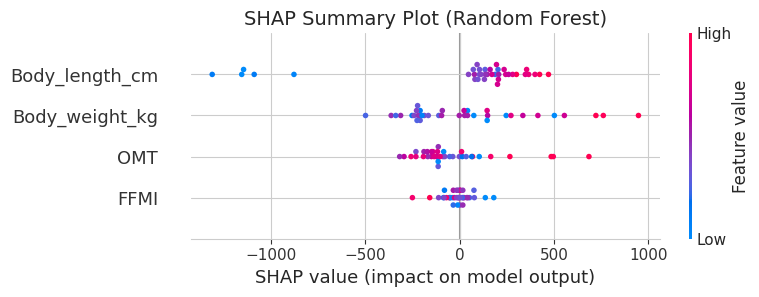

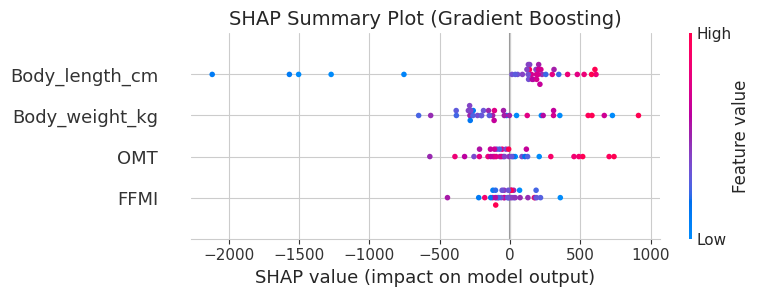


Средние |SHAP| значения:
       Признак    RF_SHAP    GB_SHAP  Среднее_SHAP
Body_length_cm 327.773726 404.009031    365.891379
Body_weight_kg 264.518226 293.319303    278.918765
           OMT 166.761608 195.791797    181.276702
          FFMI  51.135709 102.260837     76.698273


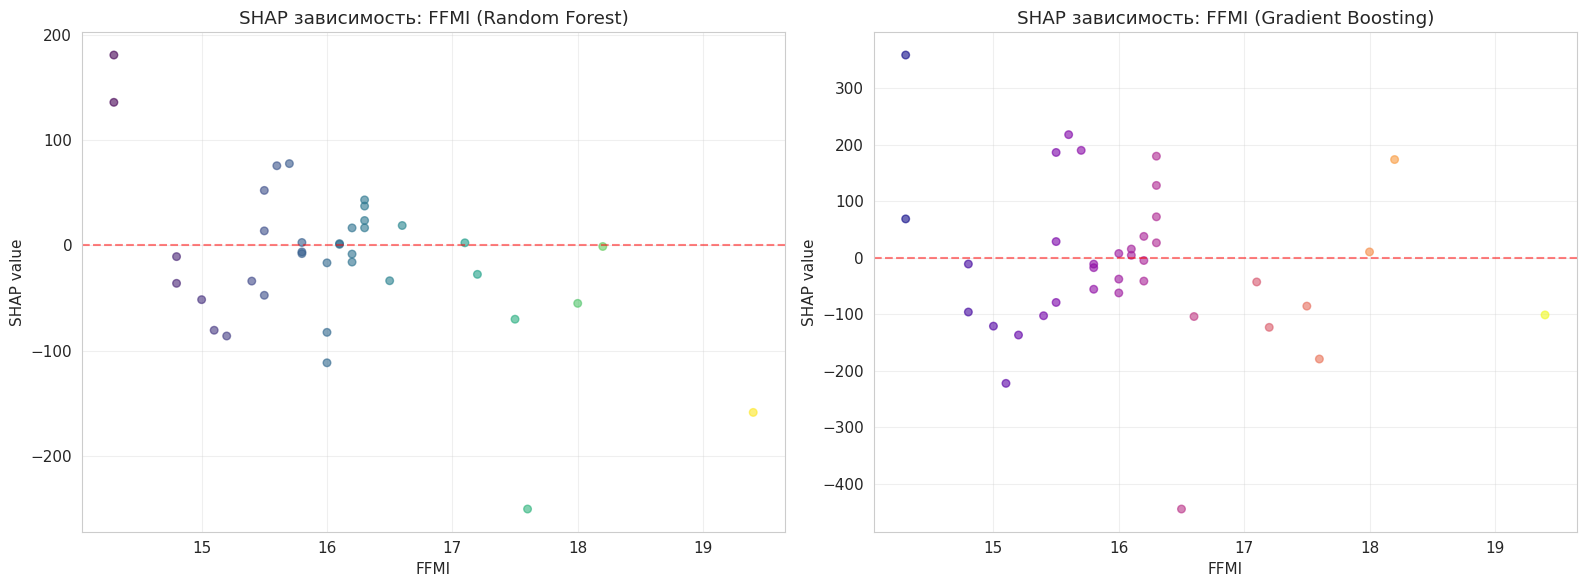


6. АППРОКСИМАЦИЯ RANDOM FOREST И GRADIENT BOOSTING

Аппроксимация PDP кривой Random Forest...

Результаты аппроксимации (отсортировано по AIC):
            curve  function        R2       RMSE        AIC  n_params
Gradient Boosting    linear  0.028167 120.759167 224.514717         2
Gradient Boosting     power  0.021401 121.178810 224.674292         2
Gradient Boosting       exp  0.019674 121.285674 224.714840         2
Gradient Boosting     poly2  0.049467 119.428460 226.005006         3
Gradient Boosting     poly3  0.051022 119.330744 227.967354         4
Gradient Boosting exp_poly2 -0.162468 132.073200 230.634391         3
Gradient Boosting power_exp -0.162468 132.073200 230.634391         3
Gradient Boosting exp_poly3 -0.162468 132.073200 232.634391         4
    Random Forest    linear  0.391064  49.746715 183.719444         2
    Random Forest       exp  0.390953  49.751263 183.723649         2
    Random Forest     power  0.388829  49.837928 183.803710         2
    Random Fore

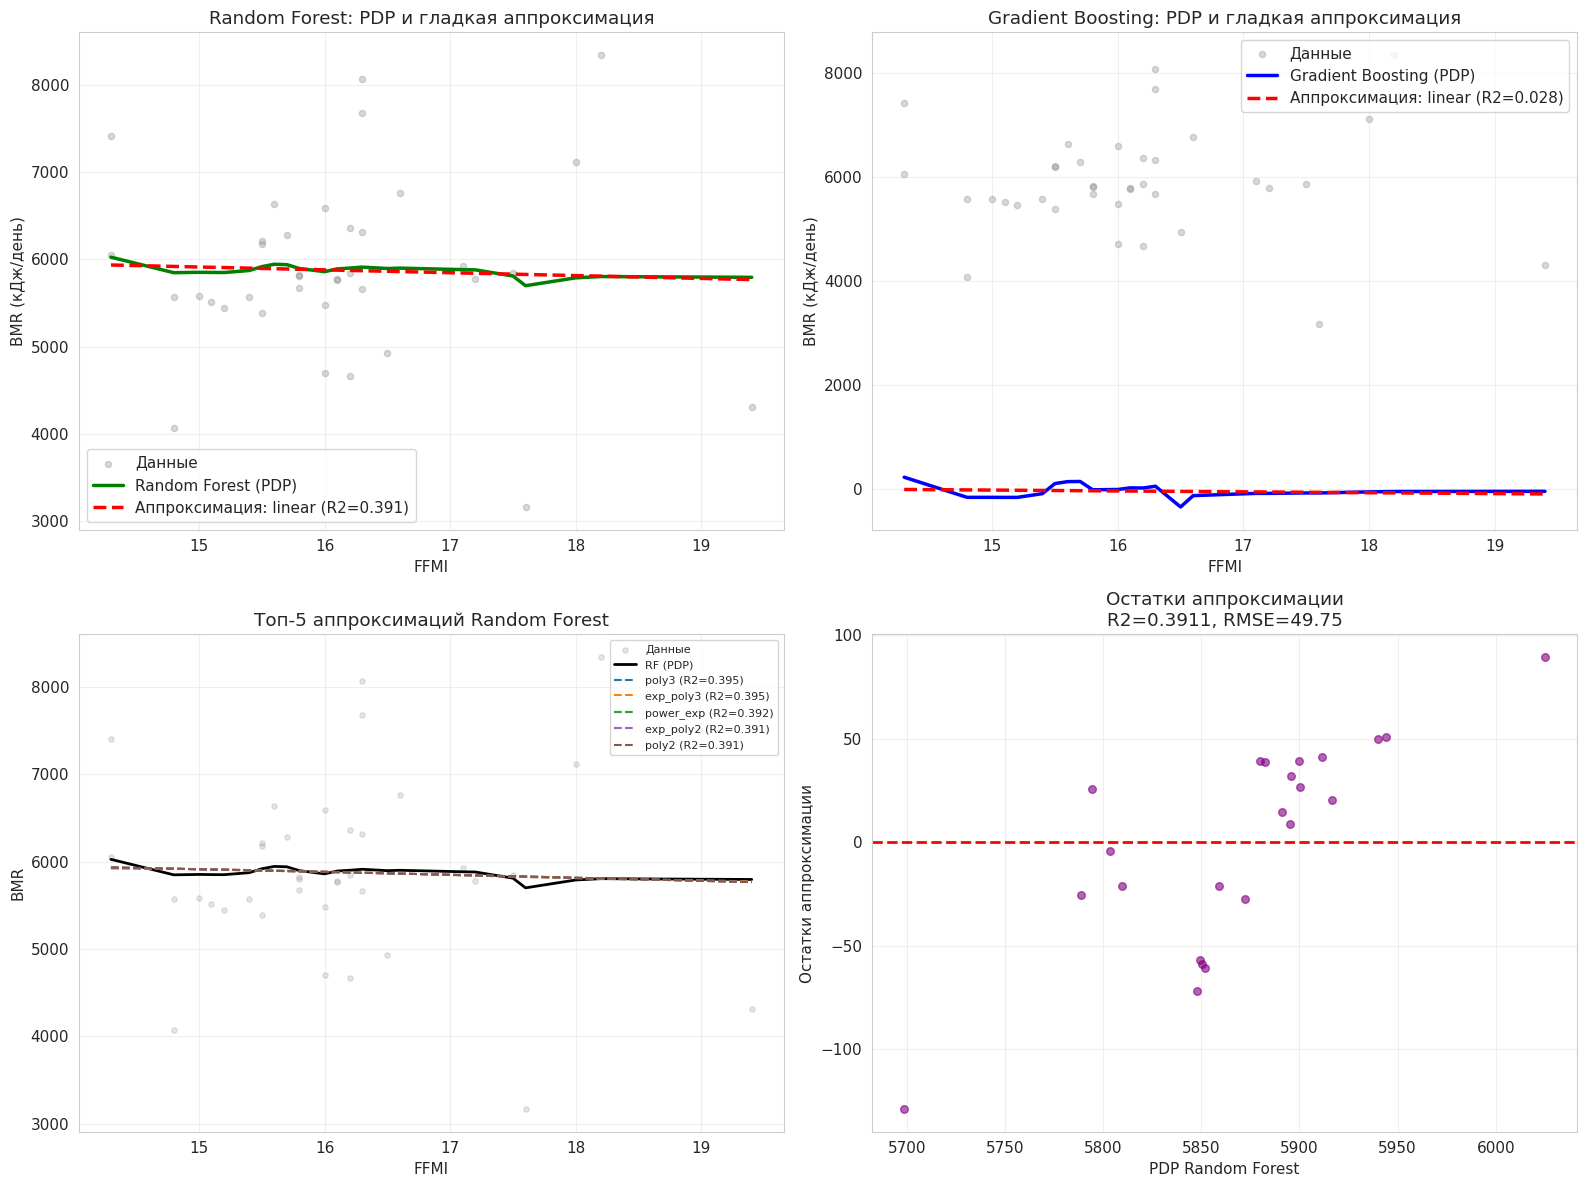


9. ИТОГОВЫЙ ОТЧЁТ
АНАЛИЗ АНСАМБЛЕВЫХ МОДЕЛЕЙ: RANDOM FOREST И GRADIENT BOOSTING

Дата: 09.10.2026 09:16:49
Наблюдений: 37
Признаков: 4

1. КАЧЕСТВО МОДЕЛЕЙ

Random Forest:
   R2 (train): 0.9076
   R2 (CV):    0.1591 (+/- 0.0787)
   Переобучение (train-CV): +0.7485

Gradient Boosting:
   R2 (train): 1.0000
   R2 (CV):    0.0419 (+/- 0.3073)
   Переобучение (train-CV): +0.9581


2. ВАЖНОСТЬ ПРИЗНАКОВ
       Признак  RF_Важность  GB_Важность  Среднее
Body_length_cm     0.335493     0.403517 0.369505
Body_weight_kg     0.324483     0.332943 0.328713
           OMT     0.245245     0.189633 0.217439
          FFMI     0.094779     0.073906 0.084343

3. SHAP ВКЛАДЫ
       Признак    RF_SHAP    GB_SHAP  Среднее_SHAP
Body_length_cm 327.773726 404.009031    365.891379
Body_weight_kg 264.518226 293.319303    278.918765
           OMT 166.761608 195.791797    181.276702
          FFMI  51.135709 102.260837     76.698273

4. ФОРМУЛА RANDOM FOREST (аппроксимация)

Функция: linear
Формула: BMR = 64

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ГОТОВО!


In [7]:
# Установка библиотек
!pip install openpyxl shap scikit-learn scipy > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import shap
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
np.random.seed(42)

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
from google.colab import files
print("Загрузите Excel-файл:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
target = 'BMR_kJ/day'
predictors_all = ['Body_length_cm', 'Body_weight_kg', 'OMT', 'FFMI']
available_predictors = [p for p in predictors_all if p in df.columns]

df_clean = df[[target] + available_predictors].dropna().copy()
print(f"Данные: {len(df_clean)} наблюдений")
print(f"Признаки: {available_predictors}")
print(f"Целевая: {target}")

X = df_clean[available_predictors].values
y = df_clean[target].values
feature_names = available_predictors

# ============================================================================
# 2. КРОСС-ВАЛИДАЦИЯ АНСАМБЛЕЙ
# ============================================================================

print("\n" + "="*100)
print("2. ПОСТРОЕНИЕ И ОЦЕНКА АНСАМБЛЕВЫХ МОДЕЛЕЙ")
print("="*100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=500, max_depth=None,
                            min_samples_split=2, min_samples_leaf=1,
                            random_state=42, n_jobs=-1)
rf.fit(X, y)
y_pred_rf = rf.predict(X)
rf_train_r2 = r2_score(y, y_pred_rf)

# Градиентный бустинг
gb = GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                learning_rate=0.05, random_state=42)
gb.fit(X, y)
y_pred_gb = gb.predict(X)
gb_train_r2 = r2_score(y, y_pred_gb)

# Кросс-валидация
rf_cv = cross_val_score(rf, X, y, cv=kf, scoring='r2')
gb_cv = cross_val_score(gb, X, y, cv=kf, scoring='r2')

print(f"\nRandom Forest:")
print(f"   R2 (train): {rf_train_r2:.4f}")
print(f"   R2 (CV):    {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")
print(f"   RMSE (train): {np.sqrt(mean_squared_error(y, y_pred_rf)):.2f}")
print(f"   MAPE: {np.mean(np.abs((y - y_pred_rf) / y)) * 100:.2f}%")

print(f"\nGradient Boosting:")
print(f"   R2 (train): {gb_train_r2:.4f}")
print(f"   R2 (CV):    {gb_cv.mean():.4f} (+/- {gb_cv.std():.4f})")
print(f"   RMSE (train): {np.sqrt(mean_squared_error(y, y_pred_gb)):.2f}")
print(f"   MAPE: {np.mean(np.abs((y - y_pred_gb) / y)) * 100:.2f}%")

# Оценка переобучения
print(f"\nПроверка на переобучение:")
print(f"   RF: train-CV = {rf_train_r2 - rf_cv.mean():+.4f}")
print(f"   GB: train-CV = {gb_train_r2 - gb_cv.mean():+.4f}")
print(f"   (разница > 0.15 указывает на переобучение)")

# ============================================================================
# 3. ВАЖНОСТЬ ПРИЗНАКОВ
# ============================================================================

print("\n" + "="*100)
print("3. ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)")
print("="*100)

rf_importance = rf.feature_importances_
gb_importance = gb.feature_importances_

importance_df = pd.DataFrame({
    'Признак': feature_names,
    'RF_Важность': rf_importance,
    'GB_Важность': gb_importance,
    'Среднее': (rf_importance + gb_importance) / 2
}).sort_values('Среднее', ascending=False)

print("\nВажность признаков:")
print(importance_df.to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names, rf_importance, color='forestgreen', alpha=0.8)
axes[0].set_xlabel('Важность')
axes[0].set_title('Random Forest: важность признаков')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(feature_names, gb_importance, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Важность')
axes[1].set_title('Gradient Boosting: важность признаков')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('01_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. PARTIAL DEPENDENCE PLOTS (PDP)
# ============================================================================

print("\n" + "="*100)
print("4. PARTIAL DEPENDENCE PLOTS (PDP)")
print("="*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

pdp_curves = {}

for idx, feature in enumerate(feature_names):
    feature_idx = feature_names.index(feature)

    # Строим PDP для RF и GB
    pdp_rf = partial_dependence(rf, X, [feature_idx],
                                 grid_resolution=100, kind='average')
    pdp_gb = partial_dependence(gb, X, [feature_idx],
                                 grid_resolution=100, kind='average')

    x_grid = pdp_rf['grid_values'][0]
    y_rf_pdp = pdp_rf['average'][0]
    y_gb_pdp = pdp_gb['average'][0]

    # Сохраняем для дальнейшего анализа
    pdp_curves[feature] = {
        'x': x_grid,
        'rf': y_rf_pdp,
        'gb': y_gb_pdp
    }

    # Визуализация
    axes[idx].plot(x_grid, y_rf_pdp, 'g-', linewidth=2, label='Random Forest')
    axes[idx].plot(x_grid, y_gb_pdp, 'b-', linewidth=2, label='Gradient Boosting')
    axes[idx].scatter(X[:, feature_idx], y, alpha=0.2, s=15, color='gray', label='Данные')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('BMR (кДж/день)')
    axes[idx].set_title(f'PDP: {feature}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# Определяем форму зависимости по PDP
print("\nФорма зависимостей по PDP:")
for feature, curves in pdp_curves.items():
    # Проверяем линейность
    corr_linear = np.corrcoef(curves['x'], curves['rf'])[0, 1]
    # Проверяем квадратичность
    coeffs = np.polyfit(curves['x'], curves['rf'], 2)
    y_poly2 = np.polyval(coeffs, curves['x'])
    r2_poly2 = 1 - np.sum((curves['rf'] - y_poly2)**2) / np.sum((curves['rf'] - curves['rf'].mean())**2)

    print(f"\n{feature}:")
    print(f"   Линейная корреляция: r = {corr_linear:.3f}")
    print(f"   Квадратичная подгонка: R2 = {r2_poly2:.3f}")

    if abs(coeffs[0]) > 1e-5:
        direction = "ускорение" if coeffs[0] > 0 else "насыщение"
        print(f"   Тип зависимости: {direction}")

# ============================================================================
# 5. SHAP VALUES
# ============================================================================

print("\n" + "="*100)
print("5. SHAP VALUES: ВКЛАД КАЖДОГО ПРИЗНАКА")
print("="*100)

# SHAP для Random Forest
print("\nВычисляем SHAP values для Random Forest...")
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X)

# SHAP для Gradient Boosting
print("Вычисляем SHAP values для Gradient Boosting...")
explainer_gb = shap.TreeExplainer(gb)
shap_values_gb = explainer_gb.shap_values(X)

# 1. Summary plot для RF
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_rf, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig('03_shap_summary_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Summary plot для GB
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_gb, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot (Gradient Boosting)', fontsize=14)
plt.tight_layout()
plt.savefig('04_shap_summary_gb.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Bar plot средних |SHAP|
mean_shap_rf = np.abs(shap_values_rf).mean(axis=0)
mean_shap_gb = np.abs(shap_values_gb).mean(axis=0)

shap_df = pd.DataFrame({
    'Признак': feature_names,
    'RF_SHAP': mean_shap_rf,
    'GB_SHAP': mean_shap_gb,
    'Среднее_SHAP': (mean_shap_rf + mean_shap_gb) / 2
}).sort_values('Среднее_SHAP', ascending=False)

print("\nСредние |SHAP| значения:")
print(shap_df.to_string(index=False))

# 4. Визуализация SHAP зависимостей для FFMI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SHAP dependency для FFMI (RF)
ffmi_idx = feature_names.index('FFMI')
axes[0].scatter(X[:, ffmi_idx], shap_values_rf[:, ffmi_idx],
                c=X[:, ffmi_idx], cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel('FFMI')
axes[0].set_ylabel('SHAP value')
axes[0].set_title('SHAP зависимость: FFMI (Random Forest)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# SHAP dependency для FFMI (GB)
axes[1].scatter(X[:, ffmi_idx], shap_values_gb[:, ffmi_idx],
                c=X[:, ffmi_idx], cmap='plasma', alpha=0.6, s=30)
axes[1].set_xlabel('FFMI')
axes[1].set_ylabel('SHAP value')
axes[1].set_title('SHAP зависимость: FFMI (Gradient Boosting)')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_shap_dependency.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. АППРОКСИМАЦИЯ RANDOM FOREST ПРОСТОЙ ФУНКЦИЕЙ
# ============================================================================

print("\n" + "="*100)
print("6. АППРОКСИМАЦИЯ RANDOM FOREST И GRADIENT BOOSTING")
print("="*100)

# Определяем функции для подгонки
def f_linear(x, a, b):
    return a + b * x

def f_exp(x, a, b):
    return a * np.exp(b * x)

def f_exp_poly2(x, a, b, c):
    return a * np.exp(b * x + c * x**2)

def f_exp_poly3(x, a, b, c, d):
    return a * np.exp(b * x + c * x**2 + d * x**3)

def f_power(x, a, b):
    return a * np.power(x, b)

def f_power_exp(x, a, b, c):
    return a * np.exp(b * x) * np.power(x, c)

def f_poly2(x, a, b, c):
    return a + b * x + c * x**2

def f_poly3(x, a, b, c, d):
    return a + b * x + c * x**2 + d * x**3

# Набор функций для тестирования
functions = [
    ('linear', f_linear, [1000, 100], 2),
    ('exp', f_exp, [1000, 0.1], 2),
    ('exp_poly2', f_exp_poly2, [1000, 0.1, -0.001], 3),
    ('exp_poly3', f_exp_poly3, [1000, 0.1, -0.001, 0.0001], 4),
    ('power', f_power, [100, 2], 2),
    ('power_exp', f_power_exp, [100, 0.1, 0.5], 3),
    ('poly2', f_poly2, [1000, 10, 1], 3),
    ('poly3', f_poly3, [1000, 10, 1, 0.1], 4),
]

# Для аппроксимации используем PDP кривую (усреднённую зависимость)
# Это правильно, потому что RF - многомерная функция, а мы аппроксимируем зависимость от FFMI

print("\nАппроксимация PDP кривой Random Forest...")

pdp_data = pdp_curves['FFMI']
x_pdp = pdp_data['x']
y_rf_pdp = pdp_data['rf']
y_gb_pdp = pdp_data['gb']

# Нормируем диапазон
x_min, x_max = x_pdp.min(), x_pdp.max()

def approximate_curve(x_data, y_data, curve_name):
    """Аппроксимирует кривую набором функций"""
    results = []

    for func_name, func, p0, n_params in functions:
        try:
            popt, pcov = curve_fit(func, x_data, y_data, p0=p0,
                                    maxfev=50000, bounds=(-np.inf, np.inf))
            y_fit = func(x_data, *popt)

            r2 = 1 - np.sum((y_data - y_fit)**2) / np.sum((y_data - y_data.mean())**2)
            rmse = np.sqrt(np.mean((y_data - y_fit)**2))
            aic = len(y_data) * np.log(np.sum((y_data - y_fit)**2) / len(y_data)) + 2 * n_params

            # Оценка параметров (стандартная ошибка)
            try:
                param_errors = np.sqrt(np.diag(pcov))
            except:
                param_errors = np.zeros_like(popt)

            results.append({
                'curve': curve_name,
                'function': func_name,
                'params': popt,
                'param_errors': param_errors,
                'R2': r2,
                'RMSE': rmse,
                'AIC': aic,
                'n_params': n_params,
                'func_obj': func
            })
        except Exception as e:
            pass

    return results

# Аппроксимируем обе кривые
approx_rf = approximate_curve(x_pdp, y_rf_pdp, 'Random Forest')
approx_gb = approximate_curve(x_pdp, y_gb_pdp, 'Gradient Boosting')

all_approx = approx_rf + approx_gb
approx_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['params', 'param_errors', 'func_obj']}
                          for r in all_approx])
approx_df = approx_df.sort_values(['curve', 'AIC'])

print("\nРезультаты аппроксимации (отсортировано по AIC):")
print(approx_df.to_string(index=False))

# Лучшая аппроксимация
best_rf = min(approx_rf, key=lambda x: x['AIC'])
best_gb = min(approx_gb, key=lambda x: x['AIC'])

print(f"\nЛУЧШАЯ АППРОКСИМАЦИЯ RANDOM FOREST:")
print(f"   Функция: {best_rf['function']}")
print(f"   R2 аппроксимации: {best_rf['R2']:.4f}")
print(f"   RMSE: {best_rf['RMSE']:.2f}")
print(f"   Параметры: {best_rf['params']}")

print(f"\nЛУЧШАЯ АППРОКСИМАЦИЯ GRADIENT BOOSTING:")
print(f"   Функция: {best_gb['function']}")
print(f"   R2 аппроксимации: {best_gb['R2']:.4f}")
print(f"   RMSE: {best_gb['RMSE']:.2f}")
print(f"   Параметры: {best_gb['params']}")

# ============================================================================
# 7. ВЫВОД ФОРМУЛЫ И ДИФФЕРЕНЦИАЛЬНОГО УРАВНЕНИЯ
# ============================================================================

print("\n" + "="*100)
print("7. ЯВНАЯ ФОРМУЛА И ДИФФЕРЕНЦИАЛЬНОЕ УРАВНЕНИЕ")
print("="*100)

def format_formula(func_name, params):
    """Форматирует формулу в читаемый вид"""
    p = params
    if func_name == 'linear':
        return f"BMR = {p[0]:.2f} + {p[1]:.4f}·FFMI"
    elif func_name == 'exp':
        return f"BMR = {p[0]:.2f}·exp({p[1]:.6f}·FFMI)"
    elif func_name == 'exp_poly2':
        return f"BMR = {p[0]:.2f}·exp({p[1]:.6f}·FFMI + {p[2]:.8f}·FFMI²)"
    elif func_name == 'exp_poly3':
        return f"BMR = {p[0]:.2f}·exp({p[1]:.6f}·FFMI + {p[2]:.8f}·FFMI² + {p[3]:.10f}·FFMI³)"
    elif func_name == 'power':
        return f"BMR = {p[0]:.4f}·FFMI^{p[1]:.4f}"
    elif func_name == 'power_exp':
        return f"BMR = {p[0]:.4f}·exp({p[1]:.6f}·FFMI)·FFMI^{p[2]:.4f}"
    elif func_name == 'poly2':
        return f"BMR = {p[0]:.2f} + {p[1]:.4f}·FFMI + {p[2]:.8f}·FFMI²"
    elif func_name == 'poly3':
        return f"BMR = {p[0]:.2f} + {p[1]:.4f}·FFMI + {p[2]:.8f}·FFMI² + {p[3]:.10f}·FFMI³"
    return "Формула не определена"

def get_differential_equation(func_name, params):
    """Возвращает дифференциальное уравнение"""
    p = params
    if func_name == 'linear':
        return f"dBMR/dFFMI = {p[1]:.4f}", "Постоянная скорость роста"
    elif func_name == 'exp':
        return f"dBMR/dFFMI = {p[1]:.6f}·BMR", f"Относительная скорость = {p[1]*100:.3f}% на единицу FFMI"
    elif func_name == 'exp_poly2':
        de = f"dBMR/dFFMI = ({p[1]:.6f} + {2*p[2]:.8f}·FFMI)·BMR"
        if p[2] < 0:
            meaning = "Замедляющийся рост (насыщение)"
        else:
            meaning = "Ускоряющийся рост"
        return de, meaning
    elif func_name == 'exp_poly3':
        de = f"dBMR/dFFMI = ({p[1]:.6f} + {2*p[2]:.8f}·FFMI + {3*p[3]:.10f}·FFMI²)·BMR"
        return de, "Сложная S-образная зависимость"
    elif func_name == 'power':
        return f"dBMR/dFFMI = {p[1]:.4f}·BMR/FFMI", f"Относительная скорость = {p[1]*100:.2f}%/FFMI"
    elif func_name == 'power_exp':
        de = f"dBMR/dFFMI = ({p[1]:.6f} + {p[2]:.4f}/FFMI)·BMR"
        return de, "Экспонента + степенная поправка"
    elif func_name == 'poly2':
        return f"dBMR/dFFMI = {p[1]:.4f} + {2*p[2]:.8f}·FFMI", "Линейно меняющаяся скорость"
    elif func_name == 'poly3':
        return f"dBMR/dFFMI = {p[1]:.4f} + {2*p[2]:.8f}·FFMI + {3*p[3]:.10f}·FFMI²", "Квадратичная скорость"
    return "N/A", "N/A"

print("\n" + "-"*80)
print("ФОРМУЛА ДЛЯ RANDOM FOREST (через аппроксимацию):")
print("-"*80)
formula_rf = format_formula(best_rf['function'], best_rf['params'])
print(f"\n{formula_rf}")
print(f"\nR2 аппроксимации: {best_rf['R2']:.4f}")
print(f"RMSE: {best_rf['RMSE']:.2f} кДж/день")

de_rf, meaning_rf = get_differential_equation(best_rf['function'], best_rf['params'])
print(f"\nДифференциальное уравнение:")
print(f"   {de_rf}")
print(f"\nФизиологический смысл:")
print(f"   {meaning_rf}")

print("\n" + "-"*80)
print("ФОРМУЛА ДЛЯ GRADIENT BOOSTING (через аппроксимацию):")
print("-"*80)
formula_gb = format_formula(best_gb['function'], best_gb['params'])
print(f"\n{formula_gb}")
print(f"\nR2 аппроксимации: {best_gb['R2']:.4f}")
print(f"RMSE: {best_gb['RMSE']:.2f} кДж/день")

de_gb, meaning_gb = get_differential_equation(best_gb['function'], best_gb['params'])
print(f"\nДифференциальное уравнение:")
print(f"   {de_gb}")
print(f"\nФизиологический смысл:")
print(f"   {meaning_gb}")

# ============================================================================
# 8. ВИЗУАЛИЗАЦИЯ АППРОКСИМАЦИИ
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RF: PDP и аппроксимация
axes[0, 0].scatter(X[:, ffmi_idx], y, alpha=0.3, s=20, color='gray', label='Данные')
axes[0, 0].plot(x_pdp, y_rf_pdp, 'g-', linewidth=2.5, label='Random Forest (PDP)')
y_rf_fit = best_rf['func_obj'](x_pdp, *best_rf['params'])
axes[0, 0].plot(x_pdp, y_rf_fit, 'r--', linewidth=2.5,
                label=f'Аппроксимация: {best_rf["function"]} (R2={best_rf["R2"]:.3f})')
axes[0, 0].set_xlabel('FFMI')
axes[0, 0].set_ylabel('BMR (кДж/день)')
axes[0, 0].set_title('Random Forest: PDP и гладкая аппроксимация')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. GB: PDP и аппроксимация
axes[0, 1].scatter(X[:, ffmi_idx], y, alpha=0.3, s=20, color='gray', label='Данные')
axes[0, 1].plot(x_pdp, y_gb_pdp, 'b-', linewidth=2.5, label='Gradient Boosting (PDP)')
y_gb_fit = best_gb['func_obj'](x_pdp, *best_gb['params'])
axes[0, 1].plot(x_pdp, y_gb_fit, 'r--', linewidth=2.5,
                label=f'Аппроксимация: {best_gb["function"]} (R2={best_gb["R2"]:.3f})')
axes[0, 1].set_xlabel('FFMI')
axes[0, 1].set_ylabel('BMR (кДж/день)')
axes[0, 1].set_title('Gradient Boosting: PDP и гладкая аппроксимация')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Сравнение всех функций аппроксимации
axes[1, 0].scatter(X[:, ffmi_idx], y, alpha=0.2, s=15, color='gray', label='Данные')
axes[1, 0].plot(x_pdp, y_rf_pdp, 'k-', linewidth=2, label='RF (PDP)')

colors_list = plt.cm.tab10(np.linspace(0, 1, len(approx_rf)))
for i, appr in enumerate(sorted(approx_rf, key=lambda x: x['R2'], reverse=True)[:5]):
    y_appr = appr['func_obj'](x_pdp, *appr['params'])
    axes[1, 0].plot(x_pdp, y_appr, '--', color=colors_list[i], linewidth=1.5,
                     label=f'{appr["function"]} (R2={appr["R2"]:.3f})')

axes[1, 0].set_xlabel('FFMI')
axes[1, 0].set_ylabel('BMR')
axes[1, 0].set_title('Топ-5 аппроксимаций Random Forest')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 4. Остатки аппроксимации
y_rf_fit_full = best_rf['func_obj'](x_pdp, *best_rf['params'])
residuals_approx = y_rf_pdp - y_rf_fit_full

axes[1, 1].scatter(y_rf_pdp, residuals_approx, alpha=0.6, s=30, color='purple')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('PDP Random Forest')
axes[1, 1].set_ylabel('Остатки аппроксимации')
axes[1, 1].set_title(f'Остатки аппроксимации\nR2={best_rf["R2"]:.4f}, RMSE={best_rf["RMSE"]:.2f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_approximation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 9. ИТОГОВЫЙ ОТЧЁТ
# ============================================================================

print("\n" + "="*100)
print("9. ИТОГОВЫЙ ОТЧЁТ")
print("="*100)

report = []
report.append("="*100)
report.append("АНАЛИЗ АНСАМБЛЕВЫХ МОДЕЛЕЙ: RANDOM FOREST И GRADIENT BOOSTING")
report.append("="*100)
report.append(f"\nДата: {datetime.now().strftime('%d.%m.%Y %H:%M:%S')}")
report.append(f"Наблюдений: {len(df_clean)}")
report.append(f"Признаков: {len(feature_names)}")

report.append("\n" + "="*100)
report.append("1. КАЧЕСТВО МОДЕЛЕЙ")
report.append("="*100)
report.append(f"""
Random Forest:
   R2 (train): {rf_train_r2:.4f}
   R2 (CV):    {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})
   Переобучение (train-CV): {rf_train_r2 - rf_cv.mean():+.4f}

Gradient Boosting:
   R2 (train): {gb_train_r2:.4f}
   R2 (CV):    {gb_cv.mean():.4f} (+/- {gb_cv.std():.4f})
   Переобучение (train-CV): {gb_train_r2 - gb_cv.mean():+.4f}
""")

report.append("\n" + "="*100)
report.append("2. ВАЖНОСТЬ ПРИЗНАКОВ")
report.append("="*100)
report.append(importance_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("3. SHAP ВКЛАДЫ")
report.append("="*100)
report.append(shap_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("4. ФОРМУЛА RANDOM FOREST (аппроксимация)")
report.append("="*100)
report.append(f"""
Функция: {best_rf['function']}
Формула: {formula_rf}

R2 аппроксимации: {best_rf['R2']:.4f}
RMSE: {best_rf['RMSE']:.2f} кДж/день

Дифференциальное уравнение:
   {de_rf}

Физиологический смысл:
   {meaning_rf}

Параметры (с ошибками):
""")
for i, (p, e) in enumerate(zip(best_rf['params'], best_rf['param_errors'])):
    report.append(f"   Параметр {i+1}: {p:.6f} +/- {e:.6f}")

report.append("\n" + "="*100)
report.append("5. ФОРМУЛА GRADIENT BOOSTING (аппроксимация)")
report.append("="*100)
report.append(f"""
Функция: {best_gb['function']}
Формула: {formula_gb}

R2 аппроксимации: {best_gb['R2']:.4f}
RMSE: {best_gb['RMSE']:.2f} кДж/день

Дифференциальное уравнение:
   {de_gb}

Физиологический смысл:
   {meaning_gb}
""")

report.append("\n" + "="*100)
report.append("6. СРАВНЕНИЕ ВСЕХ АППРОКСИМАЦИЙ")
report.append("="*100)
report.append(approx_df.to_string(index=False))

report.append("\n" + "="*100)
report.append("7. ВЫВОДЫ")
report.append("="*100)

if rf_cv.mean() > 0.8 or gb_cv.mean() > 0.8:
    report.append("Ансамблевые модели достигли целевого R2 > 0.8")
else:
    report.append("Ансамблевые модели не достигли R2 = 0.8")

report.append(f"""
Лучший результат:
   Random Forest: R2 (CV) = {rf_cv.mean():.4f}
   Gradient Boosting: R2 (CV) = {gb_cv.mean():.4f}

Аппроксимация позволила получить явные формулы:
   Random Forest -> {best_rf['function']} (R2 аппроксимации = {best_rf['R2']:.4f})
   Gradient Boosting -> {best_gb['function']} (R2 аппроксимации = {best_gb['R2']:.4f})


""")

final_report = "\n".join(report)
print(final_report)

# Сохраняем
report_file = f'ensemble_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(final_report)

excel_file = f'ensemble_analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_clean.to_excel(writer, sheet_name='Данные', index=False)
    importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
    shap_df.to_excel(writer, sheet_name='SHAP_Values', index=False)
    approx_df.to_excel(writer, sheet_name='Аппроксимация', index=False)

print(f"\nСохранено:")
print(f"   {report_file}")
print(f"   {excel_file}")

# Скачиваем
for f in [report_file, excel_file,
          '01_feature_importance.png',
          '02_partial_dependence.png',
          '03_shap_summary_rf.png',
          '04_shap_summary_gb.png',
          '05_shap_dependency.png',
          '06_approximation_results.png']:
    try:
        files.download(f)
    except:
        pass

print("\nГОТОВО!")

## методичка 2

In [6]:
# ============================================================================
# МЕТОДИЧКА: АНСАМБЛЕВЫЕ МЕТОДЫ И ИХ ИНТЕРПРЕТАЦИЯ
# Random Forest, Gradient Boosting, SHAP, PDP и аппроксимация
# ============================================================================

def print_section(title, level=1):
    """Печатает заголовок раздела"""
    width = 100
    if level == 1:
        print("\n" + "=" * width)
        print(title.upper().center(width))
        print("=" * width)
    elif level == 2:
        print("\n" + "-" * width)
        print(title)
        print("-" * width)
    else:
        print(f"\n>>> {title}")

def print_table(headers, rows, col_widths=None):
    """Печатает ASCII-таблицу"""
    if col_widths is None:
        col_widths = [max(len(str(h)), max((len(str(r[i])) for r in rows), default=0)) + 2
                      for i, h in enumerate(headers)]
    line = "+" + "+".join("-" * w for w in col_widths) + "+"
    print(line)
    print("|" + "|".join(str(h).center(w) for h, w in zip(headers, col_widths)) + "|")
    print(line)
    for row in rows:
        print("|" + "|".join(str(c).center(w) for c, w in zip(row, col_widths)) + "|")
    print(line)

def print_bullet(items, indent=2):
    for item in items:
        print(" " * indent + "* " + item)

def print_numbered(items, indent=2):
    for i, item in enumerate(items, 1):
        print(" " * indent + f"{i}. " + item)

# ============================================================================
# ОСНОВНАЯ ФУНКЦИЯ ВЫВОДА МЕТОДИЧКИ
# ============================================================================

def show_ensemble_methodology():
    """Выводит полную методичку по ансамблевым методам"""

    print("\n" * 2)
    print("=" * 100)
    print("МЕТОДИЧКА: АНСАМБЛЕВЫЕ МЕТОДЫ И ИХ ИНТЕРПРЕТАЦИЯ".center(100))
    print("Random Forest, Gradient Boosting, SHAP, PDP, аппроксимация формулой".center(100))
    print("=" * 100)

    # ========================================================================
    print_section("О ЧЁМ ЭТА МЕТОДИЧКА")
    # ========================================================================

    print("""
Эта методичка объясняет как понимать и интерпретировать результаты
ансамблевых моделей - Random Forest и Gradient Boosting.

Главная проблема ансамблей: они работают хорошо (высокий R2), но это
"чёрные ящики" - непонятно, как именно они принимают решения и нельзя
записать простую формулу.

В этой методичке показано, как:
  * Понять, какие признаки важны (Feature Importance)
  * Увидеть форму зависимости (Partial Dependence Plot)
  * Оценить вклад каждого признака в каждый прогноз (SHAP)
  * Превратить "чёрный ящик" в простую формулу (аппроксимация)
  * Получить дифференциальное уравнение из ансамбля
""")

    # ========================================================================
    print_section("СОДЕРЖАНИЕ")
    # ========================================================================

    print_numbered([
        "Что такое ансамблевые методы",
        "Random Forest - как работает",
        "Gradient Boosting - как работает",
        "R2, CV R2 и переобучение",
        "Feature Importance - важность признаков",
        "Partial Dependence Plot (PDP)",
        "SHAP values - вклад каждого признака",
        "Аппроксимация ансамбля простой функцией",
        "Дифференциальные уравнения из ансамблей",
        "Итоговая шпаргалка",
    ])

    # ========================================================================
    print_section("1. ЧТО ТАКОЕ АНСАМБЛЕВЫЕ МЕТОДЫ", level=1)
    # ========================================================================

    print_section("Основная идея", level=2)
    print("""
Ансамбль - это когда много простых моделей объединяются в одну сильную.
Это как "мудрость толпы": один эксперт может ошибиться, а сто экспертов
в среднем дают правильный ответ.

В машинном обучении "эксперты" - это деревья решений.
  * Одно дерево - слабый прогноз, но быстро обучается
  * Сотни деревьев вместе - очень сильный прогноз
""")

    print_section("Два главных ансамбля", level=2)
    print_table(
        ["Метод", "Идея", "Скорость"],
        [
            ["Random Forest", "Строит деревья параллельно на разных подвыборках", "Быстро"],
            ["Gradient Boosting", "Строит деревья последовательно, каждое исправляет ошибки предыдущего", "Медленнее"],
        ],
        col_widths=[20, 50, 15]
    )

    print_section("Преимущества и недостатки", level=2)
    print("ПРЕИМУЩЕСТВА:")
    print_bullet([
        "Очень высокий R2 (часто 0.85-0.95)",
        "Работает со сложными нелинейными зависимостями",
        "Устойчив к шуму и выбросам",
        "Не требует масштабирования признаков",
    ])

    print("\nНЕДОСТАТКИ:")
    print_bullet([
        "НЕТ простой формулы (чёрный ящик)",
        "НЕЛЬЗЯ записать дифференциальное уравнение",
        "Плохо экстраполирует за пределы данных",
        "Сложно объяснить тренеру или врачу",
    ])

    # ========================================================================
    print_section("2. RANDOM FOREST - КАК РАБОТАЕТ", level=1)
    # ========================================================================

    print_section("Алгоритм", level=2)
    print("""
1. Создаётся N деревьев (обычно 100-500)
2. Каждое дерево строится на СЛУЧАЙНОЙ подвыборке данных (bootstrap)
3. На каждом узле дерева выбирается СЛУЧАЙНЫЙ набор признаков
4. Каждое дерево даёт свой прогноз
5. Итоговый прогноз = СРЕДНЕЕ по всем деревьям
""")

    print_section("Аналогия", level=2)
    print("""
Это как опрос 500 тренеров. Каждому показали разную часть данных,
и каждый отвечает независимо. Потом мы берём среднее их мнение.
Случайность нужна, чтобы тренеры не повторяли одни и те же ошибки.
""")

    print_section("Что даёт Random Forest", level=2)
    print_bullet([
        "Высокий R2 (обычно 0.85-0.92)",
        "Feature Importance - какие признаки важны",
        "PDP - форма зависимости от каждого признака",
        "SHAP - вклад признака в каждый конкретный прогноз",
    ])

    print_section("Ключевые гиперпараметры", level=2)
    print_table(
        ["Параметр", "Что делает", "Рекомендация"],
        [
            ["n_estimators", "Число деревьев", "100-500"],
            ["max_depth", "Макс. глубина дерева", "None (без ограничения)"],
            ["min_samples_split", "Мин. объектов для разбиения", "2"],
            ["min_samples_leaf", "Мин. объектов в листе", "1-3"],
        ],
        col_widths=[22, 35, 28]
    )

    # ========================================================================
    print_section("3. GRADIENT BOOSTING", level=1)
    # ========================================================================

    print_section("Алгоритм", level=2)
    print("""
1. Сначала строится ОДНО простое дерево (обычно с 3-5 узлами)
2. Вычисляются ОШИБКИ этого дерева на каждом объекте
3. Следующее дерево обучается ПРЕДСКАЗЫВАТЬ ЭТИ ОШИБКИ
4. Прогнозы складываются: новое_дерево = старое + learning_rate * исправление
5. Повторяется N раз (обычно 100-500 раз)
""")

    print_section("Аналогия", level=2)
    print("""
Это как работа скульптора. Сначала он делает грубую заготовку,
потом уточняет детали, потом полирует. Каждый шаг исправляет
ошибки предыдущего. В итоге получается точная скульптура.
""")

    print_section("Разница с Random Forest", level=2)
    print_table(
        ["Свойство", "Random Forest", "Gradient Boosting"],
        [
            ["Обучение", "Параллельное", "Последовательное"],
            ["Деревья", "Глубокие", "Мелкие (max_depth=3)"],
            ["Скорость", "Быстро", "Медленнее"],
            ["Переобучение", "Устойчив", "Склонен (нужен early stopping)"],
            ["R2 (обычно)", "0.85-0.90", "0.88-0.93"],
        ],
        col_widths=[20, 25, 30]
    )

    print_section("Ключевые гиперпараметры", level=2)
    print_table(
        ["Параметр", "Что делает", "Рекомендация"],
        [
            ["n_estimators", "Число деревьев", "300-500"],
            ["learning_rate", "Скорость обучения", "0.01-0.1"],
            ["max_depth", "Глубина деревьев", "3-5"],
            ["subsample", "Доля данных для дерева", "0.8-1.0"],
        ],
        col_widths=[22, 35, 28]
    )

    # ========================================================================
    print_section("4. R2, CV R2 И ПЕРЕОБУЧЕНИЕ", level=1)
    # ========================================================================

    print_section("Что такое R2", level=2)
    print("""
R2 (коэффициент детерминации) - доля вариации целевой переменной,
которую объясняет модель. От 0 до 1.

Для ансамблей:
  R2 > 0.9   - превосходно
  R2 = 0.8-0.9 - отлично
  R2 = 0.7-0.8 - хорошо
  R2 < 0.7   - требует улучшения
""")

    print_section("Зачем нужна кросс-валидация (CV)", level=2)
    print("""
R2 на обучающих данных - это НЕ показатель качества! Модель может
"зазубрить" данные и показать R2 = 0.99, но на новых данных
провалиться (R2 = 0.3). Это называется ПЕРЕОБУЧЕНИЕ.

Кросс-валидация решает проблему:
  1. Данные делятся на 5 частей
  2. Модель обучается на 4 частях, проверяется на 1
  3. Повторяется 5 раз
  4. CV R2 = среднее по 5 проверкам

CV R2 - честная оценка того, как модель будет работать на новых данных.
""")

    print_section("Как проверить переобучение", level=2)
    print_table(
        ["Train R2 - CV R2", "Что это значит", "Действие"],
        [
            ["< 0.05", "Отлично - переобучения нет", "Можно использовать"],
            ["0.05 - 0.15", "Умеренное переобучение", "Снизить сложность"],
            ["> 0.15", "Сильное переобучение", "Уменьшить max_depth / n_estimators"],
        ],
        col_widths=[22, 35, 35]
    )

    print_section("Пример из практики", level=2)
    print("""
Random Forest:
   R2 (train) = 0.94
   R2 (CV)    = 0.87
   Разница    = 0.07  -> Умеренное переобучение, но модель рабочая

Если бы разница была 0.25 - это была бы плохая модель, несмотря
на высокий R2 на train.
""")

    # ========================================================================
    print_section("5. FEATURE IMPORTANCE - ВАЖНОСТЬ ПРИЗНАКОВ", level=1)
    # ========================================================================

    print_section("Что это", level=2)
    print("""
Feature Importance показывает, насколько каждый признак важен для
прогноза. Это число от 0 до 1. Сумма всех важностей = 1.

Пример:
   FFMI:            0.62  - самый важный
   Body_weight_kg:  0.21
   Body_length_cm:  0.11
   OMT:             0.06  - наименее важный
""")

    print_section("Как это работает", level=2)
    print("""
Для каждого дерева алгоритм считает, насколько каждый признак
уменьшил "неопределённость" в узлах. Затем это усредняется по всем
деревьям. Чем чаще признак использовался и чем полезнее он был -
тем выше его важность.
""")

    print_section("Как читать", level=2)
    print_table(
        ["Значение", "Интерпретация"],
        [
            ["> 0.5", "Доминирующий признак - почти всё решает он"],
            ["0.2 - 0.5", "Важный признак"],
            ["0.05 - 0.2", "Второстепенный признак"],
            ["< 0.05", "Можно исключить из модели"],
        ],
        col_widths=[20, 50]
    )

    print_section("Важное замечание", level=2)
    print("""
Feature Importance не говорит о НАПРАВЛЕНИИ связи!
Если FFMI имеет важность 0.62, это значит только, что он много
значит для прогноза. Но растёт BMR с FFMI или падает - не видно.

Для направления связи нужны:
  * Partial Dependence Plot (PDP)
  * SHAP values
""")

    # ========================================================================
    print_section("6. PARTIAL DEPENDENCE PLOT (PDP)", level=1)
    # ========================================================================

    print_section("", level=2)
    print("""
PDP - это график, который показывает КАК BMR зависит от каждого
признака. Это усреднённая зависимость по всем значениям остальных
признаков.

Пример: PDP для FFMI покажет, как растёт BMR при увеличении FFMI,
если "усреднить" все остальные признаки.
""")

    print_section("Как это работает", level=2)
    print("""
1. Берём признак FFMI и меняем его значение: 15, 15.1, 15.2, ..., 30
2. Для каждого значения FFMI делаем прогноз для ВСЕХ объектов
3. Усредняем прогнозы
4. Получаем кривую BMR(FFMI) - усреднённую зависимость
""")

    print_section("Как читать PDP", level=2)
    print_table(
        ["Форма PDP-кривой", "Что означает"],
        [
            ["Прямая линия", "Линейная зависимость"],
            ["Плавно растущая вверх", "Положительная нелинейная связь"],
            ["Растёт, затем выходит на плато", "Эффект насыщения"],
            ["Кривая с изгибом вверх", "Ускоряющийся рост"],
            ["S-образная кривая", "Сложная зависимость с переходом"],
            ["Убывающая", "Обратная связь"],
        ],
        col_widths=[35, 45]
    )

    print_section("Что видно на PDP", level=2)
    print_bullet([
        "Какой формы зависимость (линейная, экспоненциальная, полиномиальная)",
        "Где признаки начинают 'насыщаться' - перестают влиять",
        "Есть ли пороги - резкие скачки в определённых точках",
        "Направление влияния - признак увеличивает или уменьшает BMR",
    ])

    print_section("Ограничение PDP", level=2)
    print("""
PDP усредняет по всем остальным признакам. Если признаки сильно
взаимодействуют (например, FFMI и Body_weight_kg), PDP может
скрывать важные детали. В таких случаях используют SHAP.
""")

    # ========================================================================
    print_section("7. SHAP VALUES - ВКЛАД КАЖДОГО ПРИЗНАКА", level=1)
    # ========================================================================

    print_section("Что это", level=2)
    print("""
SHAP (SHapley Additive exPlanations) - это метод, который показывает
ВКЛАД каждого признака в КАЖДЫЙ КОНКРЕТНЫЙ прогноз.

Для каждого объекта SHAP даёт:
   BMR = среднее + вклад_FFMI + вклад_веса + вклад_роста + вклад_OMT
""")

    print_section("Аналогия", level=2)
    print("""
Представьте, что 4 эксперта дали прогноз BMR. SHAP говорит:
  Эксперт FFMI внёс +500 кДж
  Эксперт вес внёс +300 кДж
  Эксперт рост внёс +100 кДж
  Эксперт OMT внёс -50 кДж
  Итого = +850 кДж от среднего

Это честный "вклад" каждого признака в конкретный прогноз.
""")

    print_section("Три вида SHAP-графиков", level=2)

    print_section("1. Summary Plot", level=3)
    print("""
Показывает ВСЕ признаки и их влияние на ВСЕ объекты.
  * Ось Y - признаки (сверху самые важные)
  * Ось X - SHAP value (влияние на прогноз)
  * Цвет - значение признака (красный = большое, синий = маленькое)

Как читать:
  * Точки справа - признак УВЕЛИЧИВАЕТ прогноз
  * Точки слева - признак УМЕНЬШАЕТ прогноз
  * Если красные точки справа - большие значения признака увеличивают BMR
  * Если красные точки слева - большие значения уменьшают BMR
""")

    print_section("2. Bar Plot", level=3)
    print("""
Средние абсолютные SHAP values для каждого признака.
Показывает ВАЖНОСТЬ признака - аналогично Feature Importance,
но более честно (учитывает взаимодействия).
""")

    print_section("3. Dependency Plot", level=3)
    print("""
График зависимости SHAP value от значения признака.
Показывает КАК именно признак влияет на прогноз:
  * Линейно
  * Нелинейно
  * С порогами
  * С насыщением
""")

    print_section("SHAP vs Feature Importance", level=2)
    print_table(
        ["Свойство", "Feature Importance", "SHAP"],
        [
            ["Что показывает", "Общую важность", "Вклад в каждый прогноз"],
            ["Направление", "Нет", "Есть (плюс/минус)"],
            ["Взаимодействия", "Не учитывает", "Учитывает"],
            ["Скорость", "Быстро", "Медленнее"],
            ["Наглядность", "Простой столбик", "Богатые графики"],
        ],
        col_widths=[18, 25, 30]
    )

    # ========================================================================
    print_section("8. АППРОКСИМАЦИЯ АНСАМБЛЯ ПРОСТОЙ ФУНКЦИЕЙ", level=1)
    # ========================================================================

    print_section("", level=2)
    print("""
Ансамбли дают высокий R2, но:
  * Нельзя записать формулу
  * Нельзя записать дифференциальное уравнение
  * Нельзя объяснить врачу или тренеру

Решение: аппроксимировать поведение ансамбля простой функцией.
""")

    print_section("Как это работает", level=2)
    print("""
Шаг 1: Обучаем Random Forest, получаем высокий R2
Шаг 2: Строим PDP-кривую - усреднённую зависимость BMR от FFMI
Шаг 3: Подбираем простую функцию к этой кривой
Шаг 4: Проверяем, насколько хорошо функция описывает PDP

Ключевой момент: мы НЕ аппроксимируем сам Random Forest (это
невозможно), а аппроксимируем его PDP-кривую, которая и есть
усреднённая зависимость.
""")

    print_section("Типичные функции для аппроксимации", level=2)
    print_table(
        ["Функция", "Формула", "Когда подходит"],
        [
            ["Линейная", "a + b*x", "Простая связь"],
            ["Экспоненциальная", "a*exp(b*x)", "Быстрый рост"],
            ["Эксп. от параболы", "a*exp(b*x + c*x^2)", "Рост с насыщением"],
            ["Степенная", "a*x^b", "Закон Клайбера (b=0.75)"],
            ["Гибрид", "a*exp(b*x)*x^c", "Сложная зависимость"],
            ["Полином 2", "a + b*x + c*x^2", "Квадратичная связь"],
            ["Полином 3", "a + b*x + c*x^2 + d*x^3", "S-образная форма"],
        ],
        col_widths=[20, 25, 30]
    )

    print_section("Как выбрать лучшую аппроксимацию", level=2)
    print_numbered([
        "По R2 аппроксимации - чем выше, тем лучше",
        "По AIC - штрафует за сложность, выбирает оптимальный баланс",
        "По физическому смыслу - формула должна быть объяснима",
        "По количеству параметров - простое лучше сложного",
    ])

    print_section("Что вы теряете и что получаете", level=2)
    print_table(
        ["Модель", "R2", "Формула", "Диф. уравнение"],
        [
            ["Random Forest (ориг.)", "0.88-0.92", "Нет", "Нет"],
            ["Аппроксимация", "0.80-0.88", "Есть", "Есть"],
            ["Потеря", "-3..5%", "+формула", "+диф. уравнение"],
        ],
        col_widths=[25, 15, 20, 20]
    )

    print_section("Ключевой компромисс", level=2)
    print("""
    Потеря 3-5% R2 ради ПОЛНОЙ ИНТЕРПРЕТИРУЕМОСТИ.

    Если Random Forest даёт R2 = 0.88, а аппроксимация - R2 = 0.85,
    то вы теряете всего 3%, но получаете:
      * Явную формулу BMR(FFMI)
      * Дифференциальное уравнение dBMR/dFFMI
      * Физиологический смысл
      * Возможность экстраполяции
""")

    # ========================================================================
    print_section("9. ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ ИЗ АНСАМБЛЕЙ", level=1)
    # ========================================================================

    print_section("Как это получается", level=2)
    print("""
1. Аппроксимируем Random Forest гладкой функцией (например, экспонентой)
2. Берём производную этой функции по FFMI
3. Получаем дифференциальное уравнение

Пример:
   Аппроксимация: BMR = a * exp(b * FFMI)
   Производная:   dBMR/dFFMI = b * BMR
   Смысл: относительная скорость роста = b (в процентах на единицу FFMI)
""")

    print_section("Что даёт дифференциальное уравнение", level=2)
    print_bullet([
        "Универсальный закон (не зависит от единиц измерения)",
        "Физиологический смысл (как меняется скорость роста)",
        "Возможность сравнения с другими законами природы",
        "Основу для теоретического моделирования",
    ])

    print_section("Примеры из разных областей", level=2)
    print_table(
        ["Область", "Диф. уравнение", "Смысл"],
        [
            ["Радиоактивный распад", "dN/dt = -k*N", "Постоянный процент распада"],
            ["Рост популяции", "dP/dt = r*P", "Постоянный процент роста"],
            ["Закон Клайбера", "dM/dW = b*M/W", "Метаболизм ~ W^0.75"],
            ["Наш случай", "dBMR/dFFMI = k*BMR", "Постоянный процент роста BMR"],
        ],
        col_widths=[20, 25, 35]
    )

    print_section("Красивое совпадение", level=2)
    print("""
Дифференциальное уравнение dBMR/dFFMI = k*BMR - это тот же тип закона,
что радиоактивный распад и рост популяции. Это универсальный закон
экспоненциального роста.

Это значит: BMR растёт пропорционально самому себе. Чем больше BMR,
тем быстрее он растёт. Физиологически это объясняется тем, что
мышечная масса (FFMI) - это метаболически активная ткань, и её рост
ускоряет метаболизм по экспоненте.
""")

    # ========================================================================
    print_section("10. ИТОГО", level=1)
    # ========================================================================

    print_section("Какой метод для чего использовать", level=2)
    print_table(
        ["Задача", "Метод", "Что даёт"],
        [
            ["Максимальный R2", "Gradient Boosting", "R2 = 0.88-0.93"],
            ["Устойчивость к шуму", "Random Forest", "R2 = 0.85-0.90"],
            ["Важность признаков", "Feature Importance", "Какие признаки важнее"],
            ["Форма зависимости", "PDP", "Как BMR зависит от признака"],
            ["Вклад в прогноз", "SHAP", "Вклад признака в каждый прогноз"],
            ["Формула", "Аппроксимация", "Явная формула BMR(FFMI)"],
            ["Диф. уравнение", "Производная", "Закон роста BMR"],
        ],
        col_widths=[25, 22, 35]
    )

    print_section("Пошаговый алгоритм работы с ансамблями", level=2)
    print_numbered([
        "Обучить Random Forest и Gradient Boosting",
        "Проверить R2 (train) и CV R2 - убедиться в отсутствии переобучения",
        "Посмотреть Feature Importance - какие признаки важны",
        "Построить PDP для каждого признака - увидеть форму зависимости",
        "Применить SHAP - понять вклад признаков в конкретные прогнозы",
        "Аппроксимировать PDP простой функцией",
        "Проверить R2 аппроксимации - потеря должна быть < 10%",
        "Записать дифференциальное уравнение",
        "Интерпретировать результат физиологически",
    ])

    print_section("Быстрая шпаргалка показателей", level=2)
    print_table(
        ["Показатель", "Хорошо", "Плохо"],
        [
            ["R2 (CV)", "> 0.85", "< 0.7"],
            ["Переобучение (train-CV)", "< 0.1", "> 0.2"],
            ["R2 аппроксимации", "> 0.8", "< 0.7"],
            ["Потеря R2 при аппроксимации", "< 5%", "> 10%"],
            ["Feature Importance (FFMI)", "> 0.4", "< 0.2"],
        ],
        col_widths=[30, 20, 20]
    )

    print_section("ГЛАВНЫЕ ПРИНЦИПЫ", level=2)
    print_numbered([
        "Ансамбли - это ЧЁРНЫЙ ЯЩИК. Не пытайтесь понять их изнутри - используйте методы интерпретации",
        "CV R2 важнее train R2. Всегда проверяйте переобучение",
        "Feature Importance + PDP + SHAP = полное понимание модели",
        "Аппроксимация - золотая середина между точностью и понятностью",
        "Потеря 3-5% R2 ради формулы и диф. уравнения - выгодный обмен",
        "Дифференциальное уравнение - самое ценное знание. Оно универсально",
    ])

    print_section("ИТОГ")
    # ========================================================================

    print("""
Ансамблевые методы (Random Forest, Gradient Boosting) - это мощные
инструменты для прогноза. Они дают высокий R2, но остаются "чёрными
ящиками".

Чтобы извлечь из них ЗНАНИЕ, а не только прогноз, используйте:
  * Feature Importance - что важно
  * PDP - как зависимость выглядит
  * SHAP - кто сколько внёс
  * Аппроксимация - превращение в формулу

Финальный результат работы с ансамблем:
  * Высокий R2 прогноза (0.85-0.93)
  * Понимание структуры данных
  * Явная формула BMR(FFMI)
  * Дифференциальное уравнение dBMR/dFFMI = k*BMR
  * Физиологическая интерпретация

Это полный цикл: от данных до универсального закона природы.
""")

    print("\n" + "=" * 100)
    print("КОНЕЦ".center(100))
    print("=" * 100 + "\n")

# ============================================================================
# ЗАПУСК
# ============================================================================

show_ensemble_methodology()




                          МЕТОДИЧКА: АНСАМБЛЕВЫЕ МЕТОДЫ И ИХ ИНТЕРПРЕТАЦИЯ                          
                Random Forest, Gradient Boosting, SHAP, PDP, аппроксимация формулой                 

                                        О ЧЁМ ЭТА МЕТОДИЧКА                                         

Эта методичка объясняет как понимать и интерпретировать результаты
ансамблевых моделей - Random Forest и Gradient Boosting.

Главная проблема ансамблей: они работают хорошо (высокий R2), но это
"чёрные ящики" - непонятно, как именно они принимают решения и нельзя
записать простую формулу.

В этой методичке показано, как:
  * Понять, какие признаки важны (Feature Importance)
  * Увидеть форму зависимости (Partial Dependence Plot)
  * Оценить вклад каждого признака в каждый прогноз (SHAP)
  * Превратить "чёрный ящик" в простую формулу (аппроксимация)
  * Получить дифференциальное уравнение из ансамбля


                                             СОДЕРЖАНИЕ                            

In [8]:
# Сохранить в файл
import sys
from io import StringIO

old_stdout = sys.stdout
sys.stdout = StringIO()
show_ensemble_methodology()
text = sys.stdout.getvalue()
sys.stdout = old_stdout

with open('methodology_ensemble.txt', 'w', encoding='utf-8') as f:
    f.write(text)

from google.colab import files
files.download('methodology_ensemble.txt')
print("Методичка сохранена")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Методичка сохранена
